# Projeto Integrador — Bisnode: História, Perguntas e Roteiro {#story}

# Alunos: André Ichiro Katsurada e Danilo Guimarães 

> **Objetivo do projeto**  
> Construir um pipeline claro e reproduzível que leve do **dado bruto** a um **dataset de sobrevivência pronto para R**, com decisões **data-driven** documentadas e justificadas ao longo do caminho.

---

## 📌 Pergunta Central {#pergunta-central}

> **Quais fatores contábeis, operacionais e demográficos explicam a probabilidade e o tempo até a saída (fechamento/exit) de empresas na base Bisnode?**

**Tradução para modelagem de sobrevivência (alto nível):**
- **Evento (D)**: ocorrência de *exit* da firma no período observado.  
- **Tempo (T)**: duração desde o início da observação (fundação/início contábil) até o *exit* (ou censura se não saiu).

---

## 🧭 Mapa da História (o que você encontrará) {#mapa}

1. **(Fase 1) Storytelling & Guia** *(esta seção)*  
   Perguntas e hipóteses que direcionam a EDA, limpeza e modelagem.
2. **(Fase 2) Dados & Esquema**  
   Leitura, padronização de nomes/tipos, datas e deduplicação.
3. **(Fase 3) EDA Dirigida**  
   Perguntas -> gráficos -> respostas objetivas e decisões.
4. **(Fase 4) Limpeza & Regras de Domínio**  
   *NAs, tipos, não‑negatividade, *shares* ∈ [0,1], outliers/winsor.*
5. **(Fase 5) Missingness & Imputação Inicial**  
   Indicadores de missing + mediana/moda por grupo (ano×setor).
6. **(Fase 6) Split sem Vazamento + MICE (RF)**  
   Split (estratificado), winsor *fit no treino*, MICE+RandomForest (num.), moda (cat.).
7. **(Fase 7) Lags & Features Estáveis**  
   Defasagens sem vazamento e padronizações simples.
8. **(Fase 8) Sobrevivência (Firm-level & Start–Stop)**  
   Construção de **T/D** e dataset pronto para Cox no R.
9. **(Fase 9) Exportação & Metadados**  
   CSV/Parquet + codebook + JSON de metadados (pronto para R).
10. **(Fase 10) Checks Finais & Apêndice**  
    Consistência contábil/temporal, lições e próximos passos.

> **Dica:** use o Outline do VSCode para navegar. As seções possuem âncoras `{#id}` como `#pergunta-central`, `#hipoteses`, etc.

---

## 🎯 Hipóteses (para guiar a EDA e as decisões) {#hipoteses}

**Estrutura financeira**
- **H1 — Liquidez**: menor liquidez (ex.: `curr_assets / curr_liab`) ↑ risco de saída (↓ T).  
- **H2 — Alavancagem/solidez**: menor capital próprio (`share_eq`, `subscribed_cap`) ↑ risco.  
- **H3 — Rentabilidade**: margens piores (`profit_loss_year / sales`) ↑ risco.

**Custos e escala**
- **H4 — Custo de pessoal**: razão `personnel_exp / sales` muito alta ↑ risco.  
- **H5 — Tamanho**: empresas maiores (`sales`, `fixed_assets`, `labor_avg`) tendem a sobreviver mais (↓ risco).

**Governança e demografia**
- **H6 — Estrangeira (`foreign`)**: pode ↓ risco via acesso a capital / gestão.  
- **H7 — Liderança feminina (`female`)**: efeito a ser mensurado (sem viés a priori).  
- **H8 — Setor/Ano (efeitos fixos)**: indústria (`ind2_2d`) e choques anuais têm grande peso.

**Espaço/território**
- **H9 — Urbano/Região**: firmas em áreas urbanas (`urban_m_std`) e certas regiões (`region_m`) podem ter risco diferente.

---

## 📝 Perguntas de EDA (que a história vai responder) {#perguntas-eda}

1. **Cobertura & Qualidade**  
   - Quais colunas têm mais *missing*? Existem padrões por ano/setor?  
   - Há valores negativos indevidos em variáveis contábeis?  
   - *Shares* (`foreign`, `female`) estão sempre em [0,1]?

2. **Distribuições e Outliers**  
   - `sales`, `profit_loss_year`, `personnel_exp` são altamente assimétricas?  
   - Como se comparam **antes vs. depois** de winsor por (ano×setor)?

3. **Estrutura Temporal**  
   - Há concentração de observações em 2005–2010 (ou outros blocos)?  
   - Lags (ex.: `sales_tminus1`) ajudam a estabilizar as relações?

4. **Heterogeneidade por Setor/Região**  
   - Quais indústrias dominam a amostra? Há diferenças claras nas distribuições?

5. **Prévia de Sobrevivência**  
   - Taxa de eventos por ano? Diferenças por setor/região?

Cada pergunta virá com **gráficos** + **respostas em 2–3 bullets** e culminará em **decisões de limpeza/modelagem**.

---

## ✅ Critérios de Decisão (regras antes de codar) {#criterios}

**Regras de domínio**
- Variáveis **contábeis** não podem ser negativas → valores < 0 ⇒ *NaN* (e sinalização via `miss__*`).  
- Variáveis **proporcionais** (`foreign`, `female`) devem estar em **[0,1]** (fora ⇒ *NaN*).

**Outliers**
- **Winsorização** por **(ano × `ind2_2d`)** nos quantis **1%–99%**, apenas se `n≥25` no grupo.  
- Grupos pequenos ficam **sem winsor** (evitamos distorção); registramos *caps*.

**Imputação**
- Passo 1: **Indicadores de missing** `miss__col`.  
- Passo 2: **Imputação leve por grupo** (mediana/moda em ano×setor; *fallback* global).  
- Passo 3: **MICE + RandomForest** para numéricas (no **treino**); **moda** para categóricas.  
- Reclipar *shares* para [0,1] após imputação.

**Vazamento**
- **Sempre** fazer **split (train/test)** **antes** de winsor e imputação; *fit* no treino, *apply* no teste.

**Estratificação**
- Se existir `ind2_2d`, usar **estratificação por setor** no split para manter equilíbrio.

---

## 🧩 Variáveis-Chave e Derivações planejadas {#variaveis}

- **Datas/tempo**: `begin`, `end`, `founded_date`, `exit_date`, `year`  
- **Evento**: `D` (se existir) ou derivado de `exit_date`  
- **Contábil**: `sales`, `COGS`, `personnel_exp`, `wages`, `profit_loss_year`, `inc_bef_tax`,  
  `curr_assets`, `curr_liab`, `fixed_assets`, `intang_assets`, `liq_assets`, `inventories`  
- **Estrutura/escala**: `share_eq`, `subscribed_cap`, `labor_avg`  
- **Demografia/governança**: `foreign`, `female`, `ceo_count`, `gender` (se aplicável)  
- **Setor/região**: `ind2_2d` *(derivar se preciso)*, `nace_main_2d` *(truncate)*, `region_m`, `urban_m_std` *(derivar de `urban_m`)*  
- **Derivadas (exemplos)**:  
  - Liquidez: `curr_assets / curr_liab`  
  - Margem: `profit_loss_year / sales`  
  - Custo de pessoal: `personnel_exp / sales`  
  - *Lags*: `sales_tminus1`, `personnel_exp_tminus1`, etc.

---

## ⏱️ Definições de Sobrevivência (T/D) e Censura {#surv-defs}

- **Evento (D)**: `1` se `exit_date` presente no intervalo observado (ou `exit_year` coerente); `0` se ausente (*censura*).  
- **Tempo (T), firm-level**:  
  - Início (**t0**): `founded_date` ou primeiro `begin` válido; *fallback* = 1º/jan do menor `year`.  
  - Fim (**t1**): `exit_date` se evento; caso contrário, último `end` válido; *fallback* = 31/dez do maior `year`.  
  - **T (anos)** = `(t1 - t0).days / 365.25`, com mínimo 0.1 para evitar zeros.  
- **Start–Stop (opcional)**: uma linha por ano `(start, stop]`, `event=1` apenas no ano do *exit*; covariáveis anuais (tempo‑dependentes).

---

## 📦 Saídas Esperadas (para consumo no R) {#saidas}

- **Firm-level**: `bisnode_survival_firmlevel.csv|parquet`  
  Colunas mínimas: `comp_id`, `T`, `D`, `ind2_2d`, `region_m`, `urban_m_std`, `sales`, `foreign`, `female`, `labor_avg`, …  
- **Painel start–stop (opcional)**: `bisnode_survival_panel.csv|parquet`  
  Colunas mínimas: `comp_id`, `start`, `stop`, `event`, `year`, `ind2_2d`, `sales`, …  

---

## ✔️ Critérios de Aceite (pronto para R) {#aceite}

- Dataset final contém **T/D** válidos, sem valores negativos indevidos e com *shares* ∈ [0,1].  
- **Split** realizado **antes** de winsor/imputação (sem vazamento).  
- **Indicadores de missing** presentes (`miss__*`).  
- Arquivos `.csv` e `.parquet` salvos em `outputs/processed/` e legíveis no R (`arrow::read_parquet`).  
- *Snippet* Cox no R roda sem ajustes adicionais.

---

## 🔎 Transparência e Reprodutibilidade {#reprod}

- Configuração e caminhos **relativos** (sem `"/Users/..."`).  
- Todas as decisões técnicas documentadas em cada fase com **comentários em português**.

---

> **Próximo passo:** avance para **[Fase 2 — Dados & Esquema](#dados-esquema)** para leitura padronizada, tipagem e tratamento de datas.


In [1]:
# [FASE 0] Dependências e caminhos (uma única célula)
# --------------------------------------------------------------------------------
# Objetivo (PT-BR):
# - Padronizar o ambiente do notebook (.ipynb) no VSCode.
# - Instalar apenas o estritamente necessário, e somente se faltar.
# - Evitar caminhos absolutos; usar diretórios relativos ao projeto (Path.cwd()).
# - Definir pastas de dados e saídas (outputs/processed, outputs/processed/figs).
# - Ajustar tema de gráficos e silenciar warnings para leitura limpa.
#
# Por que isso é importante?
# - Garante portabilidade entre máquinas/ambientes (sem “/Users/...").
# - Facilita reprodutibilidade (mesmas versões e caminhos coerentes).
# - Evita ruído visual logo no início do notebook.
#
# Como usar?
# - Execute esta célula antes de qualquer outra. Todas as seções seguintes assumem
#   que PROJECT_DIR, DATA_DIR e OUTPUT_DIR já existem.

import sys, os, json, warnings, importlib, subprocess, platform
from pathlib import Path
from datetime import datetime

# -------------------------------
# 1) Instalação mínima e controlada
# -------------------------------
# Comentário (PT-BR):
# Mantemos o conjunto de pacotes no essencial. Instalamos apenas se não estiver presente.
# Evitamos o uso de "!" (magics) para não depender do IPython shell; usamos subprocess.

REQS = [
    # (nome_para_import, nome_no_pip)
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),  # import: sklearn / pip: scikit-learn
    ("pyarrow", "pyarrow"),
]

def _ensure_package(import_name: str, pip_name: str) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"[SETUP] Instalando pacote ausente: {pip_name} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        # valida import após instalação
        importlib.import_module(import_name)

for import_name, pip_name in REQS:
    _ensure_package(import_name, pip_name)

# (Opcional) MissForest (missingpy): robusto para imputação mista; deixamos opcional/documentado.
MISSFOREST_AVAILABLE = False
try:
    importlib.import_module("missingpy")
    MISSFOREST_AVAILABLE = True
except Exception:
    MISSFOREST_AVAILABLE = False  # segue sem instalar automaticamente para evitar inflar dependências

# -------------------------------
# 2) Imports principais + ajustes visuais
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")  # Comentário: suprime warnings não críticos para leitura
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# -------------------------------
# 3) Diretórios do projeto (portáveis, sem caminhos absolutos)
# -------------------------------
PROJECT_DIR = Path.cwd()                 # Raiz do projeto = pasta onde o .ipynb está
DATA_DIR    = PROJECT_DIR / "data"       # Coloque seus arquivos .csv/.parquet aqui
OUTPUT_DIR  = PROJECT_DIR / "outputs" / "processed"
FIG_DIR     = OUTPUT_DIR / "figs"

for _p in [DATA_DIR, OUTPUT_DIR, FIG_DIR]:
    _p.mkdir(parents=True, exist_ok=True)

# Diretórios padrão de figuras para a futura “galeria EDA”
FIG_DIRS = [
    PROJECT_DIR / "figs",
    FIG_DIR,                              # outputs/processed/figs
]

# -------------------------------
# 4) Boas práticas utilitárias
# -------------------------------
def ensure_dir(path: Path | str) -> None:
    """(PT-BR) Garante que o diretório exista (cria se necessário)."""
    Path(path).mkdir(parents=True, exist_ok=True)

def _pkg_version_safe(mod_name: str) -> str:
    """(PT-BR) Captura versão de um módulo de forma resiliente."""
    try:
        mod = importlib.import_module(mod_name)
        return getattr(mod, "__version__", "desconhecida")
    except Exception:
        return "não importado"

# -------------------------------
# 5) Registro leve do ambiente (diagnóstico)
# -------------------------------
VERSOES = {
    "numpy": _pkg_version_safe("numpy"),
    "pandas": _pkg_version_safe("pandas"),
    "matplotlib": _pkg_version_safe("matplotlib"),
    "seaborn": _pkg_version_safe("seaborn"),
    "sklearn": _pkg_version_safe("sklearn"),
    "missingpy_available": MISSFOREST_AVAILABLE,
}
AMBIENTE = {
    "executed_at_utc": datetime.utcnow().isoformat(timespec="seconds"),
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "project_dir": str(PROJECT_DIR),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "fig_dir": str(FIG_DIR),
    "fig_dirs_searched": [str(p) for p in FIG_DIRS],
    "packages": VERSOES,
}

# Persistimos um snapshot simples (útil para auditoria/reprodutibilidade)
with open(OUTPUT_DIR / "environment_snapshot.json", "w", encoding="utf-8") as f:
    json.dump(AMBIENTE, f, ensure_ascii=False, indent=2)

# -------------------------------
# 6) Mensagens finais (orientação ao leitor)
# -------------------------------
print("[INFO] Ambiente inicial pronto.")
print(f"[INFO] Projeto: {PROJECT_DIR}")
print(f"[INFO] Dados:   {DATA_DIR}")
print(f"[INFO] Saídas:  {OUTPUT_DIR}")
print(f"[INFO] Figuras: {FIG_DIR}")
print("[INFO] Pacotes:", ", ".join([f"{k}={v}" for k,v in VERSOES.items() if k!='missingpy_available']))
if MISSFOREST_AVAILABLE:
    print("[INFO] missingpy (MissForest) disponível: True")
else:
    print("[INFO] missingpy (MissForest) disponível: False (opcional)")
print("\n[DICA] Use títulos Markdown com anchors {#id} nas próximas seções e evite aspas “inteligentes”.")



[INFO] Ambiente inicial pronto.
[INFO] Projeto: /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1
[INFO] Dados:   /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1/data
[INFO] Saídas:  /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1/outputs/processed
[INFO] Figuras: /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1/outputs/processed/figs
[INFO] Pacotes: numpy=2.1.3, pandas=2.2.3, matplotlib=3.10.5, seaborn=0.13.2, sklearn=1.6.1
[INFO] missingpy (MissForest) disponível: False (opcional)

[DICA] Use títulos Markdown com anchors {#id} nas próximas seções e evite aspas “inteligentes”.


# Fase 2 — Dados, Esquema e Tipagem {#dados-esquema}

**Propósito desta fase.**  
Ler o arquivo de entrada (CSV/Parquet) usando **caminhos relativos**, padronizar o **esquema** (nomes, tipos, datas) e garantir que tenhamos um painel consistente:
- `comp_id` e `year` coerentes (deduplicação por `(comp_id, year)`).
- Datas parseadas (`begin`, `end`, `founded_date`, `exit_date`).
- Colunas canônicas derivadas quando não existirem:
  - **`ind2_2d`** (2 dígitos): de `ind2` ou truncando `nace_main`.
  - **`nace_main_2d`** (2 dígitos): truncado de `nace_main` (fallback = `ind2_2d`).
  - **`urban_m_std`** (binário): derivado de `urban_m` (`>0` ⇒ 1; caso contrário 0).
- **Tipagem**: `year` em `Int64` (aceita NA), *shares* como numéricos, categóricas como `string`.

**Por que antes da EDA e da limpeza pesada?**  
Sem um esquema consistente, a EDA produz respostas confusas. Aqui apenas **estruturamos** o dado; a **limpeza de valores fora de domínio**, **winsor** e **imputações** virão nas fases 4–6.

**Saídas desta fase:**
- `raw`: dataframe padronizado, datado e deduplicado (base para EDA da Fase 3).
- *Relatórios rápidos*: shape, amostra, dtypes e resumo de cobertura.

In [2]:
# =========================
# FASE 2 — Carregamento, Esquema e Tipagem (sem caminhos absolutos)
# =========================
# Comentários (PT-BR):
# - Esta célula substitui a configuração antiga baseada em '/Users/...'.
# - Lemos o arquivo de forma robusta (CSV/Parquet), padronizamos esquema, tratamos datas
#   e deduplicamos por (comp_id, year). Mantemos tudo em caminhos relativos do projeto.

from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict, Optional
import json
import numpy as np
import pandas as pd

# --- Diretórios relativos (a Fase 0 já cria, mas reforçamos) ---
try:
    PROJECT_DIR
except NameError:
    PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Exibição agradável no notebook ---
from IPython.display import display

# ---------------------------
# 1) Config canônica do painel
# ---------------------------
@dataclass(frozen=True)
class Config:
    # Entrada (buscamos primeiro no diretório raiz e depois em /data)
    input_candidates: tuple = (
        "cs_bisnode_panel.csv",
        "cs_bisnode_panel__SURVIVAL.csv",
    )
    id_col: str = "comp_id"
    year_col: str = "year"
    begin_col: str = "begin"
    end_col: str = "end"
    exit_date_col: str = "exit_date"
    founded_date_col: str = "founded_date"
    industry_col: str = "ind2_2d"     # canônico (derivamos se necessário)
    nace_col: str = "nace_main_2d"    # canônico (derivamos se necessário)
    region_col: str = "region_m"
    urban_col: str = "urban_m_std"    # canônico (derivamos de urban_m/indicadores urbanos)
    # Colunas que tratamos como "shares/proporções" (depois recliparemos na limpeza)
    share_like_cols: tuple = ("foreign", "female")
    nonneg_cols: tuple = (
    "sales", "net_dom_sales", "net_exp_sales",
    "curr_assets", "fixed_assets", "intang_assets", "tang_assets",
    "liq_assets", "inventories", "curr_liab",
    "subscribed_cap", "finished_prod", "ceo_count", "labor_avg"
    )

CFG = Config()

# ---------------------------
# 2) Utilitários de IO
# ---------------------------
def _load_any(path: Path) -> pd.DataFrame:
    """Lê CSV. Erros de parse ficam como NaN."""
    p = str(path).lower()
    if p.endswith(".csv"):
        return pd.read_csv(path)
    raise ValueError(f"Formato não suportado: {path}")

def _find_input_file(candidates: List[str]) -> Path:
    """
    Comentário:
    - Buscamos os arquivos candidatos primeiro no diretório do projeto, depois em /data.
    - Mantemos tudo relativo (sem '/Users/...').
    """
    search_dirs = [PROJECT_DIR, DATA_DIR]
    for d in search_dirs:
        for name in candidates:
            p = d / name
            if p.exists():
                return p
    # Se nada encontrado, instruímos de forma clara:
    raise FileNotFoundError(
        f"Arquivo de entrada não encontrado em {PROJECT_DIR} ou {DATA_DIR}. "
        f"Tente colocar um dos nomes {list(candidates)} em uma dessas pastas."
    )

# ---------------------------
# 3) Padronização de datas e esquema
# ---------------------------
def _parse_dates(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """Parse robusto: valores inválidos viram NaT (sem quebrar o notebook)."""
    d = df.copy()
    for c in cols:
        if c in d.columns:
            d[c] = pd.to_datetime(d[c], errors="coerce")
    return d

def _ensure_year(df: pd.DataFrame, year_col: str, begin_col: str) -> pd.DataFrame:
    """Garante coluna 'year' (Int64). Se ausente, deriva de 'begin'."""
    d = df.copy()
    if year_col in d.columns:
        d[year_col] = pd.to_numeric(d[year_col], errors="coerce").astype("Int64")
    elif begin_col in d.columns:
        d[year_col] = pd.to_datetime(d[begin_col], errors="coerce").dt.year.astype("Int64")
    else:
        d[year_col] = pd.Series(pd.array([pd.NA]*len(d), dtype="Int64"))
    return d

def _derive_industry_cols(df: pd.DataFrame, industry_col: str, nace_col: str) -> pd.DataFrame:
    """
    Deriva colunas setoriais canônicas:
    - ind2_2d: de 'ind2' (dois dígitos) ou truncando 'nace_main'.
    - nace_main_2d: truncado de 'nace_main' (fallback = ind2_2d).
    """
    d = df.copy()

    if industry_col not in d.columns:
        if "ind2" in d.columns:
            d[industry_col] = (
                pd.to_numeric(d["ind2"], errors="coerce")
                .astype("Int64")
                .astype("string")
            )
        elif "nace_main" in d.columns:
            d[industry_col] = d["nace_main"].astype(str).str[:2]
        else:
            d[industry_col] = pd.Series(pd.array([pd.NA]*len(d), dtype="string"))

    if nace_col not in d.columns:
        if "nace_main" in d.columns:
            d[nace_col] = d["nace_main"].astype(str).str[:2]
        else:
            # fallback: usa o próprio ind2_2d
            d[nace_col] = d[industry_col].astype("string")
    return d

def _derive_urban(df: pd.DataFrame, urban_col: str) -> pd.DataFrame:
    """
    Deriva 'urban_m_std' binária:
    - Se houver 'urban_m', considera 1 quando 'urban_m' > 0, senão 0.
    - Caso contrário, preenche com NA (será tratado adiante nas fases de limpeza/imputação).
    """
    d = df.copy()
    if urban_col not in d.columns:
        if "urban_m" in d.columns:
            u = pd.to_numeric(d["urban_m"], errors="coerce").fillna(0)
            d[urban_col] = (u > 0).astype("Int64")  # Int64 aceita NA
        else:
            d[urban_col] = pd.Series(pd.array([pd.NA]*len(d), dtype="Int64"))
    return d

def _standardize_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Tipagem mínima e segura:
    - id: mantemos como está (numérico ou string), pois pode ser inteiro grande; não forçar conversão aqui.
    - year: Int64 (aceita NA).
    - shares (foreign, female): numérico (coerção suave; fora de [0,1] será tratado na Fase 4).
    - setoriais/regionais: string (categorias limpas nas próximas fases).
    - datas: já tratadas em _parse_dates.
    - D (se existir): int binário (coerce -> fillna(0) -> int8).
    """
    d = df.copy()

    # Year já foi garantido
    if CFG.year_col in d.columns:
        d[CFG.year_col] = pd.to_numeric(d[CFG.year_col], errors="coerce").astype("Int64")

    # Shares: numéricos (NaN se inválidos)
    for c in CFG.share_like_cols:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    # Setoriais/regionais: string
    for c in [CFG.industry_col, CFG.nace_col, CFG.region_col]:
        if c in d.columns:
            d[c] = d[c].astype("string")

    # Urbano: Int64 (0/1/NA)
    if CFG.urban_col in d.columns:
        d[CFG.urban_col] = pd.to_numeric(d[CFG.urban_col], errors="coerce").astype("Int64")

    # Evento (se existir): int binário
    if "D" in d.columns:
        d["D"] = pd.to_numeric(d["D"], errors="coerce").fillna(0).clip(0, 1).astype("Int8")

    return d

def _coerce_year_bounds(df: pd.DataFrame, col: str, year_min=1900, year_max=2100) -> pd.DataFrame:
    """
    Limites suaves de ano para sanidade.
    - Anos fora [1900, 2100] viram NA (não removemos linhas aqui para preservar cobertura).
    """
    d = df.copy()
    if col in d.columns:
        y = pd.to_numeric(d[col], errors="coerce")
        d.loc[(y < year_min) | (y > year_max), col] = pd.NA
    return d

def _deduplicate_panel(df: pd.DataFrame, id_col: str, year_col: str) -> pd.DataFrame:
    """Deduplca por (id, year) mantendo a última ocorrência (mais completa)."""
    if id_col not in df.columns or year_col not in df.columns:
        return df.copy()
    before = len(df)
    d = (
        df.sort_values([id_col, year_col])
          .drop_duplicates([id_col, year_col], keep="last")
          .copy()
    )
    removed = before - len(d)
    print(f"[INFO] Deduplicação por ({id_col}, {year_col}): {removed} linhas removidas.")
    return d

def _schema_report(df: pd.DataFrame) -> pd.DataFrame:
    """Resumo compacto de esquema (coluna, dtype, #NA, %NA)."""
    rep = pd.DataFrame({
        "col": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "na_count": df.isna().sum().values,
        "na_share": (df.isna().mean().round(4)).values
    })
    return rep.sort_values(["na_share", "col"], ascending=[False, True]).reset_index(drop=True)

# ---------------------------
# 4) Execução da Fase 2
# ---------------------------
# a) Encontrar e carregar o arquivo
input_path = _find_input_file(list(CFG.input_candidates))
raw_in = _load_any(input_path)
print(f"[INFO] Arquivo carregado: {input_path.name} | shape bruto: {raw_in.shape}")

# b) Parse de datas canônicas
raw_dt = _parse_dates(
    raw_in,
    [CFG.begin_col, CFG.end_col, CFG.exit_date_col, CFG.founded_date_col]
)

# c) Garantir coluna 'year' (deriva de 'begin' se necessário)
raw_dt = _ensure_year(raw_dt, CFG.year_col, CFG.begin_col)

# d) Derivar colunas canônicas (indústria / NACE / urbano)
raw_dt = _derive_industry_cols(raw_dt, CFG.industry_col, CFG.nace_col)
raw_dt = _derive_urban(raw_dt, CFG.urban_col)

# e) Tipagem mínima (shares, categóricas, D)
raw_std = _standardize_types(raw_dt)

# f) Anos fora de faixa plausível -> NA (sanidade); removemos linhas sem id/ano logo abaixo
raw_std = _coerce_year_bounds(raw_std, CFG.year_col, 1900, 2100)

# g) Remoção mínima de linhas inválidas: sem id OU sem year (não conseguimos usar no painel)
before_rows = len(raw_std)
mask_valid = raw_std[CFG.year_col].notna()
if CFG.id_col in raw_std.columns:
    mask_valid &= raw_std[CFG.id_col].notna()
raw_std = raw_std.loc[mask_valid].copy()
removed_invalid = before_rows - len(raw_std)
if removed_invalid > 0:
    print(f"[INFO] Linhas removidas por ausência de {CFG.id_col} ou {CFG.year_col}: {removed_invalid}")

# h) Deduplicação por (comp_id, year)
raw = _deduplicate_panel(raw_std, CFG.id_col, CFG.year_col)

# i) Relatórios rápidos para orientar a próxima fase (EDA)
print(f"[INFO] Shape após Fase 2: {raw.shape}")
display(raw.head(5))

schema = _schema_report(raw)
print("[INFO] Esquema (top 20 por %NA):")
display(schema.head(20))

# j) (Opcional) Salvar snapshot desta fase para rastreabilidade / reprocessamento
meta_phase2 = {
    "input_file": input_path.name,
    "project_dir": str(PROJECT_DIR),
    "rows_after_phase2": int(len(raw)),
    "cols_after_phase2": int(raw.shape[1]),
    "columns_present": list(raw.columns),
}


[INFO] Arquivo carregado: cs_bisnode_panel.csv | shape bruto: (287829, 48)
[INFO] Deduplicação por (comp_id, year): 0 linhas removidas.
[INFO] Shape após Fase 2: (287829, 51)


,comp_id,begin,end,COGS,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,...,ind2,ind,urban_m,region_m,founded_date,exit_date,labor_avg,ind2_2d,nace_main_2d,urban_m_std
0,1001034.0,2005-01-01,2005-12-31,NaN,692.592590,7266.666504,7574.074219,0.0,0.0,0.0,...,56.0,3.0,1,Central,1990-11-19,NaT,NaN,56,56,1
1,1001034.0,2006-01-01,2006-12-31,NaN,603.703674,13122.222656,12211.111328,0.0,0.0,0.0,...,56.0,3.0,1,Central,1990-11-19,NaT,NaN,56,56,1
2,1001034.0,2007-01-01,2007-12-31,NaN,425.925934,8196.295898,7800.000000,0.0,0.0,0.0,...,56.0,3.0,1,Central,1990-11-19,NaT,NaN,56,56,1
3,1001034.0,2008-01-01,2008-12-31,NaN,300.000000,8485.185547,7781.481445,0.0,0.0,0.0,...,56.0,3.0,1,Central,1990-11-19,NaT,NaN,56,56,1
4,1001034.0,2009-01-01,2009-12-31,NaN,207.407410,5137.037109,15300.000000,0.0,0.0,0.0,...,56.0,3.0,1,Central,1990-11-19,NaT,0.083333,56,56,1


[INFO] Esquema (top 20 por %NA):


,col,dtype,na_count,na_share
0,finished_prod,float64,270344,0.9393
1,wages,float64,269846,0.9375
2,COGS,float64,269572,0.9366
3,net_dom_sales,float64,269572,0.9366
4,net_exp_sales,float64,269572,0.9366
5,exit_year,float64,248970,0.8650
6,exit_date,datetime64[ns],231649,0.8048
7,labor_avg,float64,146532,0.5091
8,birth_year,float64,111818,0.3885
9,founded_year,float64,56457,0.1961


# Fase 3 — EDA Dirigida (Perguntas → Gráficos → Respostas) {#eda-dirigida}

**Objetivo.** Nesta fase transformamos perguntas de negócio em análises visuais **objetivas**, gerando evidências que **guiam as decisões de limpeza e modelagem** nas próximas fases.

**Perguntas que vamos responder:**
1. **Cobertura & Missing:** Quais variáveis têm mais valores ausentes? Há padrões por setor/ano?
2. **Estrutura Temporal:** Em quais anos a base é mais densa? Existem “buracos” de cobertura?
3. **Distribuições-Chave:** As distribuições de `sales`, `profit_loss_year` e `personnel_exp` são assimétricas? Precisaremos de **winsorização**?
4. **Composição Setorial/Regional:** Quais setores e regiões dominam a amostra? Há concentração que exige **estratificação** no split?
5. **Relações Bivariadas:** Qual a relação entre `sales` e custos (ex.: `personnel_exp`), e entre `sales` e `profit_loss_year`?

**Como ler esta seção.**
- Para cada pergunta: mostramos **1–2 figuras** + **mini-insights** (bullets) com **decisões práticas** (ex.: “aplicar winsor 1%–99% por ano×setor”).
- Todas as imagens são exportadas para `outputs/processed/figs` para reutilização (ex.: relatórios, slides).




[EDA] 1) Cobertura & Missing


,col,dtype,na_count,na_share
0,finished_prod,float64,270344,0.9393
1,wages,float64,269846,0.9375
2,COGS,float64,269572,0.9366
3,net_dom_sales,float64,269572,0.9366
4,net_exp_sales,float64,269572,0.9366
5,exit_year,float64,248970,0.8650
6,exit_date,datetime64[ns],231649,0.8048
7,labor_avg,float64,146532,0.5091
8,birth_year,float64,111818,0.3885
9,founded_year,float64,56457,0.1961


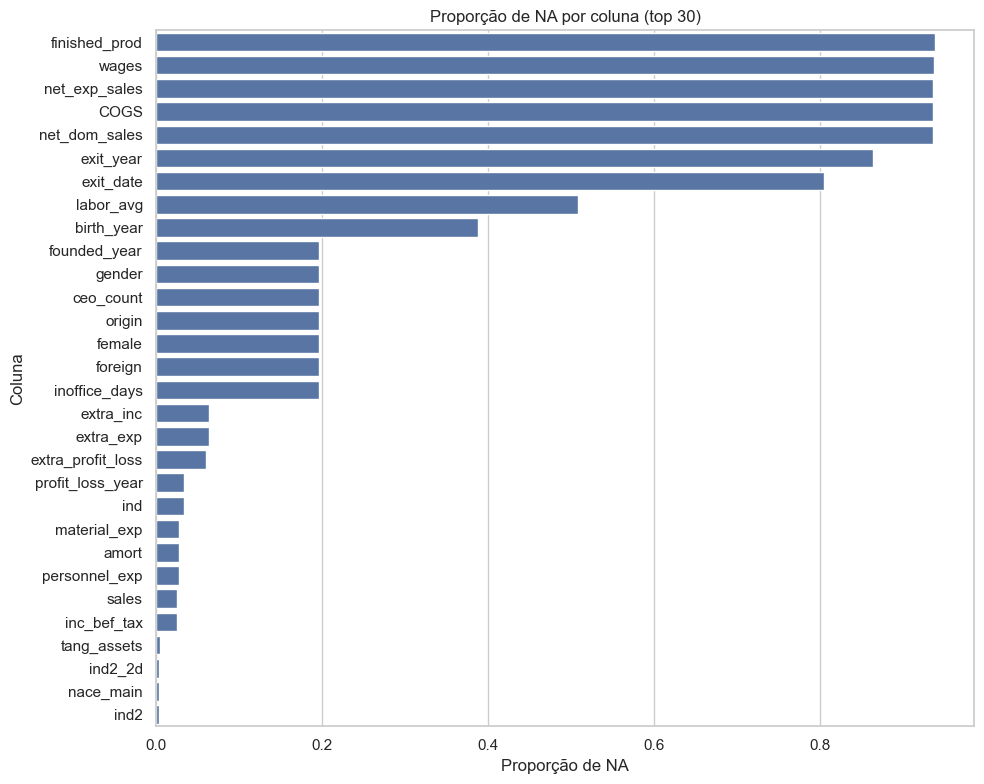

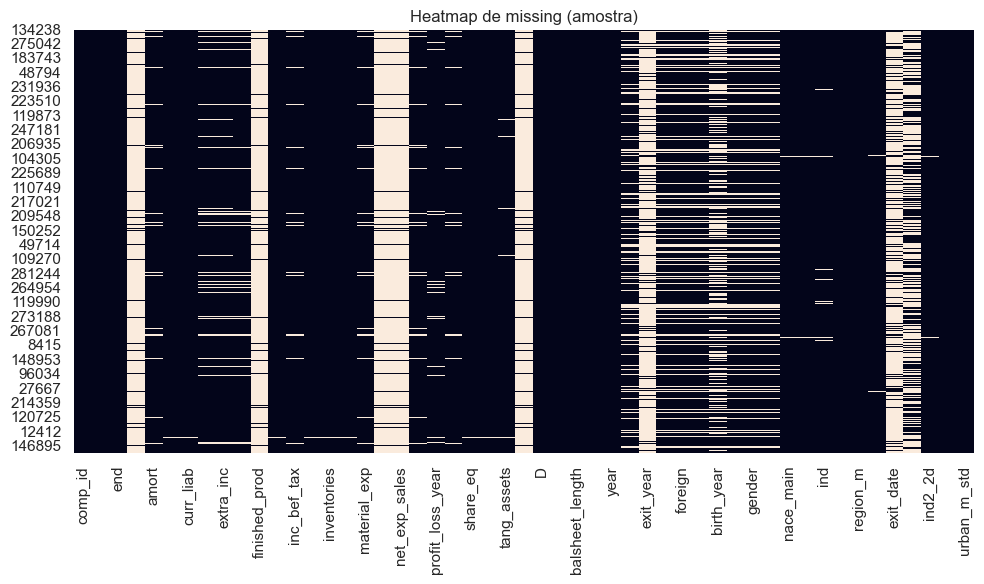

[INSIGHT] Top 5 colunas por % de NA:
  - finished_prod: 93.9% NA
  - wages: 93.8% NA
  - COGS: 93.7% NA
  - net_dom_sales: 93.7% NA
  - net_exp_sales: 93.7% NA

[EDA] 2) Estrutura Temporal


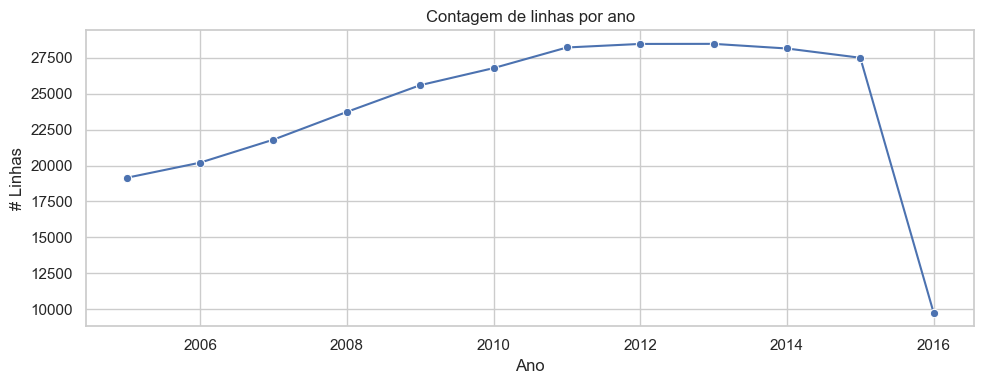

[INSIGHT] Anos mais densos (top 3):
  - 2013: 28474 linhas
  - 2012: 28469 linhas
  - 2011: 28222 linhas

[EDA] 3) Distribuições-Chave


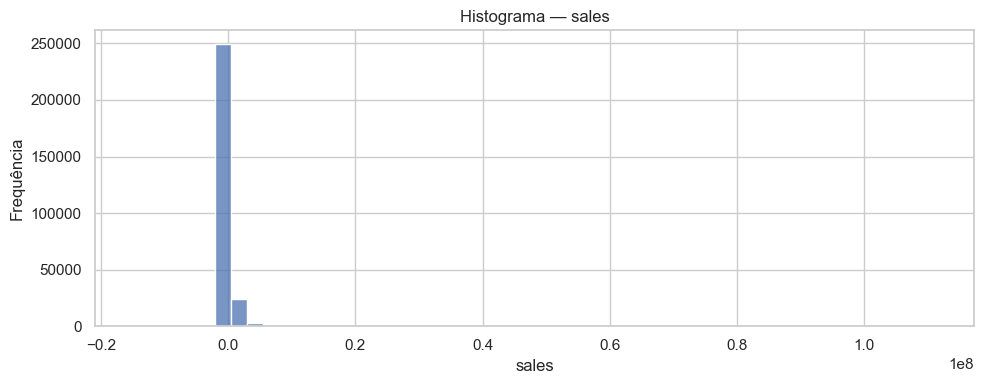

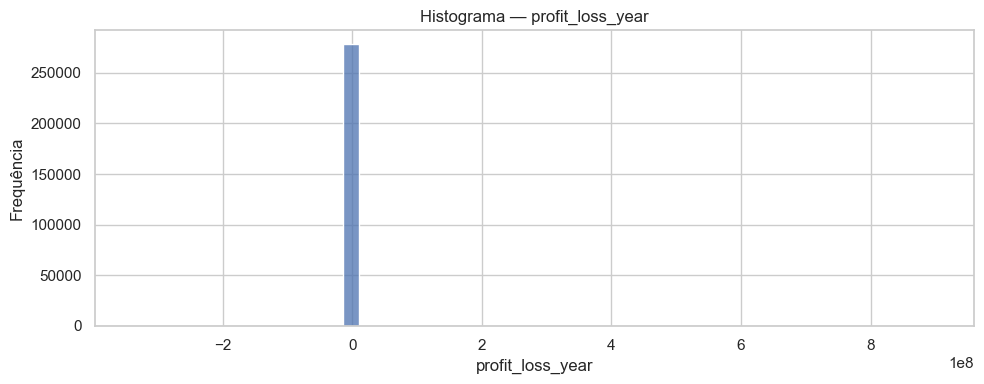

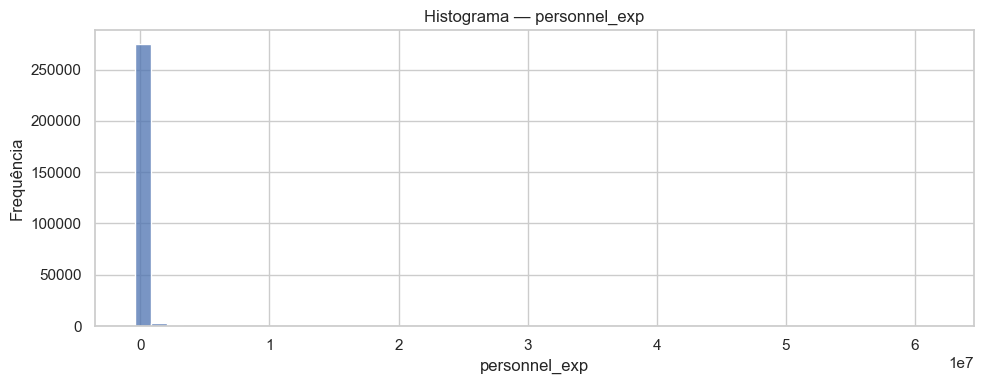

[INSIGHT] sales: q01=0.00, q50=32807.41, q99=9210744.33, IQR=115710.18, tail_ratio=79.32
  * Cauda muito pesada → recomendação: aplicar winsorização 1%–99% por ano×setor (decisão será aplicada nas fases 4–6).
[INSIGHT] profit_loss_year: q01=-124544.45, q50=0.00, q99=276532.29, IQR=5185.19, tail_ratio=53.33
  * Cauda muito pesada → recomendação: aplicar winsorização 1%–99% por ano×setor (decisão será aplicada nas fases 4–6).
[INSIGHT] personnel_exp: q01=0.00, q50=7885.19, q99=1825014.92, IQR=25918.52, tail_ratio=70.11
  * Cauda muito pesada → recomendação: aplicar winsorização 1%–99% por ano×setor (decisão será aplicada nas fases 4–6).

[EDA] 4) Composição Setorial/Regional


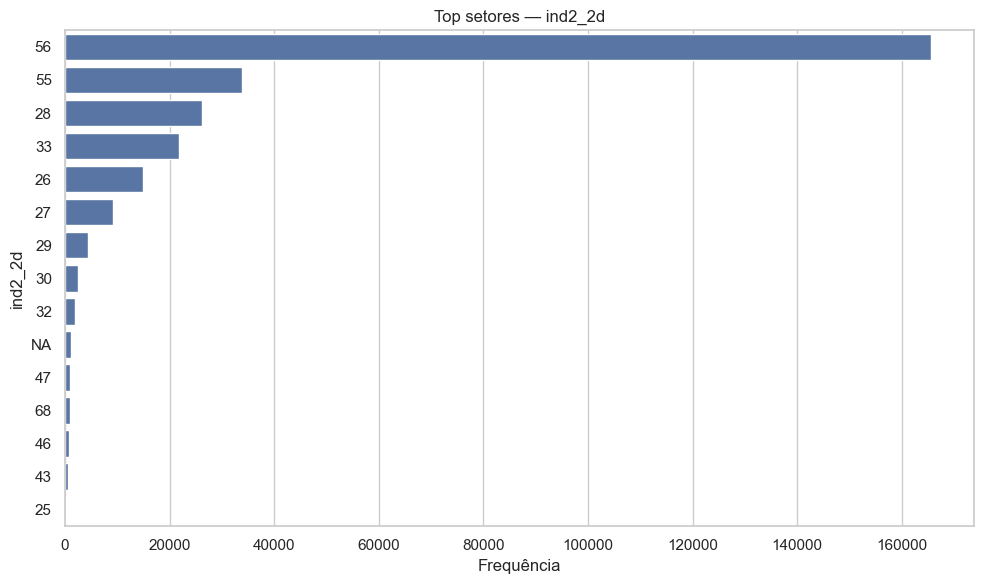

[INSIGHT] Setores mais frequentes (top 5):
  - 56: 165521 linhas
  - 55: 33756 linhas
  - 28: 26098 linhas
  - 33: 21839 linhas
  - 26: 14877 linhas


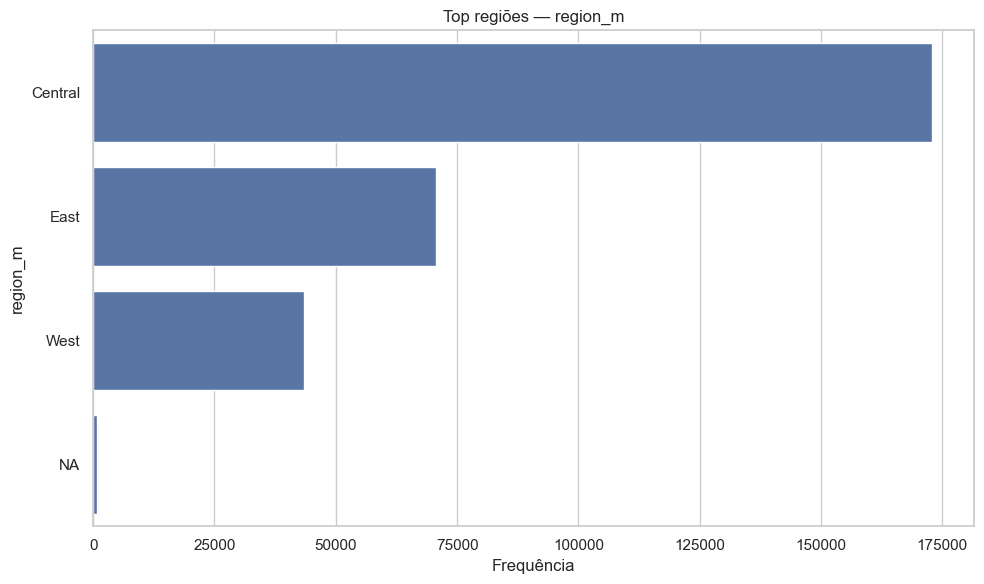

[INSIGHT] Regiões mais frequentes (top 5):
  - Central: 172906 linhas
  - East: 70623 linhas
  - West: 43460 linhas
  - NA: 840 linhas

[EDA] 5) Relações Bivariadas


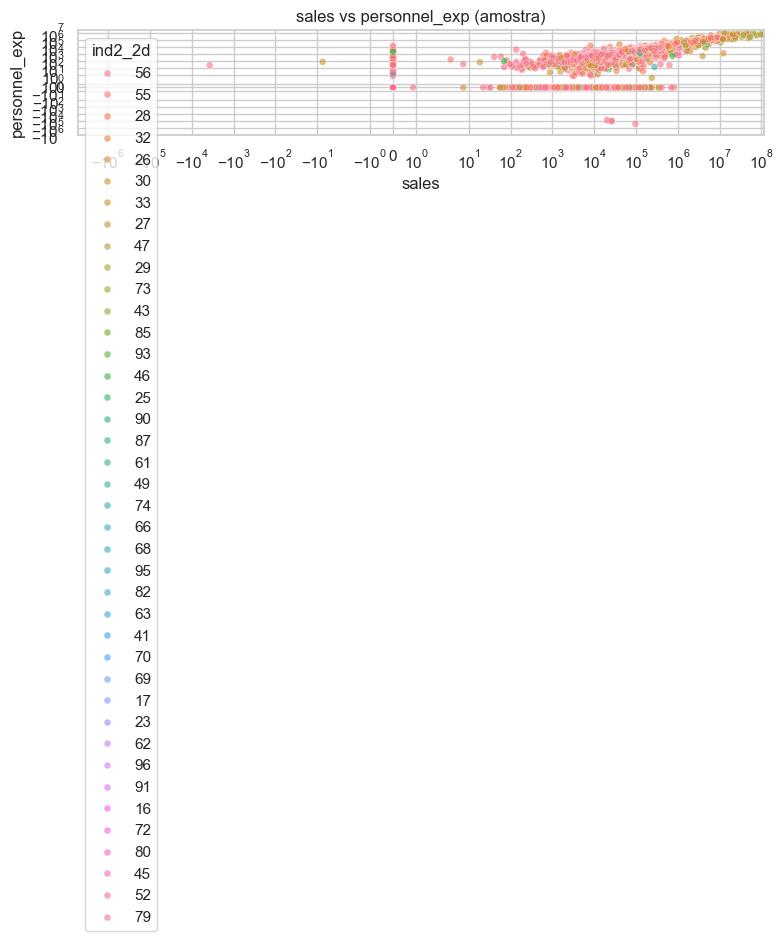

  [INSIGHT] Relação positiva esperada: empresas maiores tendem a gastar mais com pessoal.


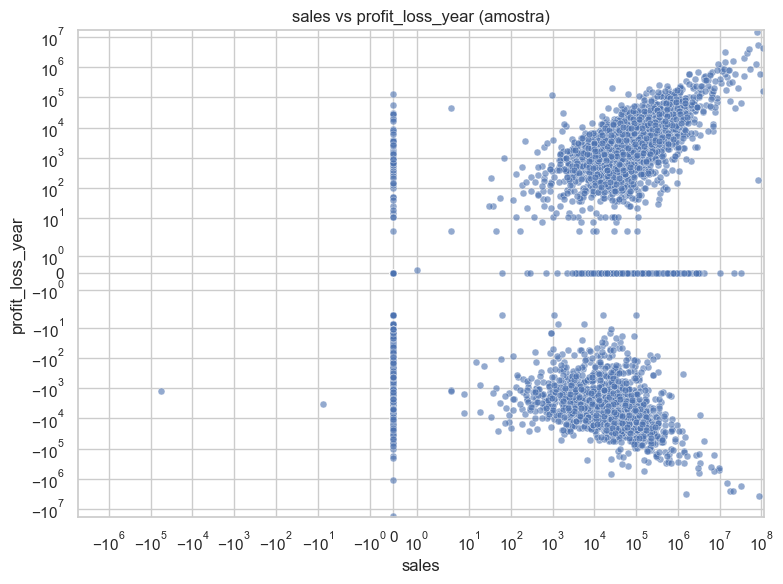

  [INSIGHT] Espera-se correlação positiva; outliers de prejuízo/ lucro extremo serão tratados com winsor.


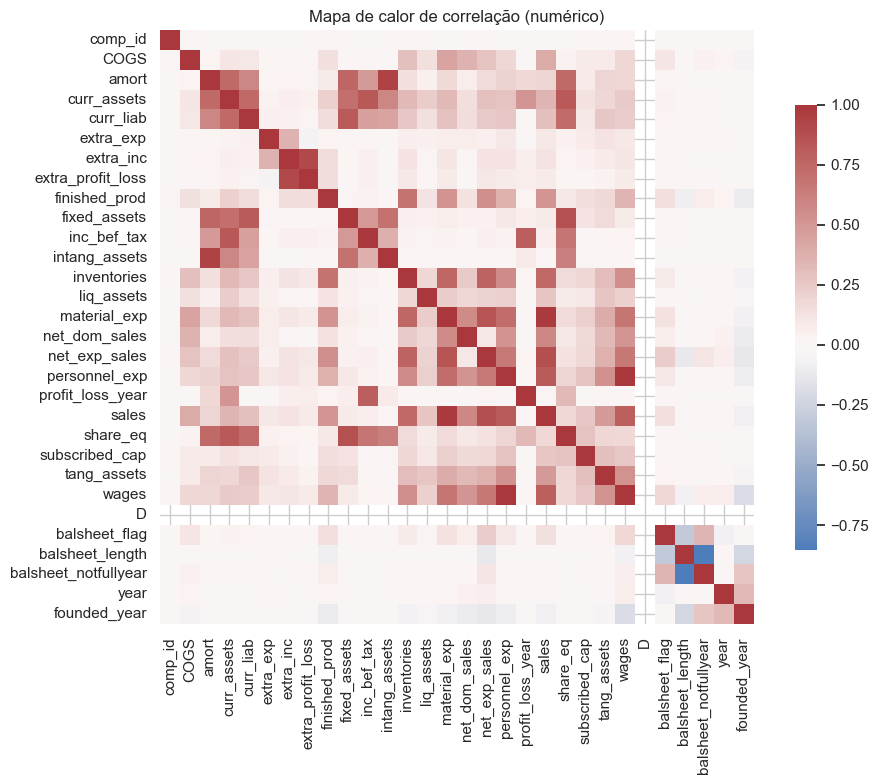

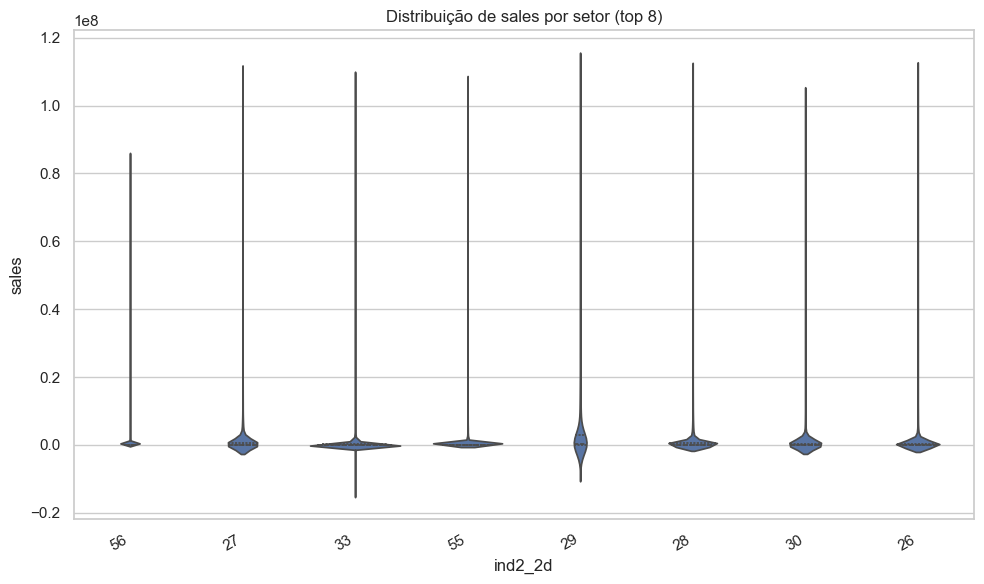


[DECISÕES ORIENTADAS PELA EDA]
 - Aplicar winsorização 1%-99% por ano×setor nas métricas financeiras com cauda pesada (ex.: sales, profit_loss_year, personnel_exp).
 - Estratificar por setor (ind2_2d) no split treino/teste para manter composição setorial.
 - Criar indicadores de missing para colunas com alta ausência; imputar por grupo ano×setor + MICE+RandomForest nas numéricas.
 - Cuidado com anos com baixa cobertura; avaliar holdout temporal conforme objetivo do modelo.

[OK] Fase 3 concluída. Figuras salvas em: /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1/outputs/processed/figs


In [3]:
# =========================
# FASE 3 — EDA Dirigida
# =========================
# Comentários (PT-BR):
# - Esta EDA parte do 'raw' padronizado na Fase 2.
# - Gera gráficos essenciais, imprime mini-insights e salva artefatos em FIG_DIR.
# - Mantém simplicidade e robustez: amostragem para gráficos pesados e tratamento gracioso de colunas ausentes.

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# --- Garantias de ambiente (derivadas da Fase 0/Fase 2) ---
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("outputs/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

try:
    CFG
except NameError:
    raise RuntimeError("CFG não encontrado. Execute a Fase 2 antes da Fase 3.")

# Se 'raw' não existir (ex.: execução direta desta célula), tentamos carregar do arquivo
if "raw" not in globals():
    raise RuntimeError("Variável 'raw' não encontrada. Execute a Fase 2 antes da Fase 3.")

sns.set_theme(style="whitegrid", context="notebook")

# ---------------------------
# Utilitários de EDA simples
# ---------------------------
def _schema_report(df: pd.DataFrame) -> pd.DataFrame:
    """Resumo de esquema: dtype, #NA e %NA por coluna."""
    rep = pd.DataFrame({
        "col": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "na_count": df.isna().sum().values,
        "na_share": (df.isna().mean().round(4)).values
    })
    return rep.sort_values(["na_share", "col"], ascending=[False, True]).reset_index(drop=True)

def _savefig(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()

def plot_missing_share(df: pd.DataFrame, topn=30, title="Proporção de NA por coluna"):
    miss = df.isna().mean().sort_values(ascending=False).head(topn)
    ax = sns.barplot(x=miss.values, y=miss.index, orient="h")
    ax.set_title(title); ax.set_xlabel("Proporção de NA"); ax.set_ylabel("Coluna")
    return ax

def plot_missing_heatmap(df: pd.DataFrame, sample: int = 1000, title="Heatmap de missing (amostra)"):
    d = df.sample(min(sample, len(df)), random_state=0) if len(df) > sample else df
    ax = sns.heatmap(d.isna(), cbar=False)
    ax.set_title(title)
    return ax

def plot_counts_by_year(df: pd.DataFrame, year_col: str):
    if year_col not in df.columns:
        print("[AVISO] Coluna de ano não encontrada."); 
        return None
    ct = df[year_col].value_counts().sort_index()
    ax = sns.lineplot(x=ct.index, y=ct.values, marker="o")
    ax.set_title("Contagem de linhas por ano"); ax.set_xlabel("Ano"); ax.set_ylabel("# Linhas")
    return ax, ct

def hist_num(df: pd.DataFrame, col: str, bins=50, title=None):
    if col not in df.columns:
        print(f"[AVISO] {col} ausente."); 
        return None
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    ax = sns.histplot(s, bins=bins, kde=False)
    ax.set_title(title or f"Histograma — {col}"); ax.set_xlabel(col); ax.set_ylabel("Frequência")
    return ax, s

def plot_corr_heatmap(df: pd.DataFrame, max_cols: int = 30):
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        print("[AVISO] Sem colunas numéricas para correlação.")
        return None
    if num.shape[1] > max_cols:
        num = num.iloc[:, :max_cols]
    corr = num.corr(numeric_only=True)
    ax = sns.heatmap(corr, cmap="vlag", center=0, square=True, cbar_kws={"shrink":0.75})
    ax.set_title("Mapa de calor de correlação (numérico)")
    return ax

def plot_top_categories(df: pd.DataFrame, col: str, topn: int = 15, title=None):
    if col not in df.columns:
        print(f"[AVISO] Coluna '{col}' não encontrada."); 
        return None
    vc = df[col].astype("string").fillna("NA").value_counts().head(topn)
    ax = sns.barplot(x=vc.values, y=vc.index, orient="h")
    ax.set_title(title or f"Top {topn} categorias — {col}")
    ax.set_xlabel("Frequência"); ax.set_ylabel(col)
    return ax, vc

def plot_scatter(df: pd.DataFrame, x: str, y: str, hue: str = None, sample: int = 5000,
                 title=None, logx=False, logy=False):
    cols = [c for c in [x, y, hue] if c and c in df.columns]
    if len(cols) < 2:
        print("[AVISO] Colunas insuficientes para scatter."); 
        return None
    d = df[cols].dropna()
    if len(d) > sample:
        d = d.sample(sample, random_state=0)
    ax = sns.scatterplot(data=d, x=x, y=y, hue=hue, alpha=0.6, s=25)
    if logx:
        ax.set_xscale("symlog")
    if logy:
        ax.set_yscale("symlog")
    ax.set_title(title or f"Dispersão: {y} vs {x}")
    return ax, d

def plot_violin_by_category(df: pd.DataFrame, num_col: str, cat_col: str, topn: int = 8, title=None):
    if num_col not in df.columns or cat_col not in df.columns:
        print("[AVISO] Colunas não encontradas para violino."); 
        return None
    topcats = df[cat_col].astype("string").value_counts().head(topn).index
    sub = df[df[cat_col].astype("string").isin(topcats)][[num_col, cat_col]].dropna()
    ax = sns.violinplot(data=sub, x=cat_col, y=num_col, inner="quartile")
    plt.xticks(rotation=30, ha="right")
    ax.set_title(title or f"Distribuição de {num_col} por {cat_col} (top {topn})")
    return ax, sub

# ---------------------------
# 1) Cobertura & Missing
# ---------------------------
print("\n[EDA] 1) Cobertura & Missing")
schema = _schema_report(raw)
display(schema.head(20))

plt.figure(figsize=(10, 8))
plot_missing_share(raw, topn=30, title="Proporção de NA por coluna (top 30)")
_savefig(FIG_DIR / "eda_missing_bar.png")

plt.figure(figsize=(10, 6))
plot_missing_heatmap(raw, sample=1000, title="Heatmap de missing (amostra)")
_savefig(FIG_DIR / "eda_missing_heatmap.png")

# Mini-insights automáticos para missing (top 5)
top_missing = schema.head(5)[["col", "na_share"]].assign(na_share=lambda x: (x["na_share"]*100).round(1))
print("[INSIGHT] Top 5 colunas por % de NA:")
for _, r in top_missing.iterrows():
    print(f"  - {r['col']}: {r['na_share']}% NA")

# ---------------------------
# 2) Estrutura Temporal
# ---------------------------
print("\n[EDA] 2) Estrutura Temporal")
plt.figure(figsize=(10, 4))
ax_ct, counts_by_year = plot_counts_by_year(raw, CFG.year_col)
if ax_ct:
    _savefig(FIG_DIR / "eda_counts_by_year.png")

if ax_ct is not None:
    densest_years = counts_by_year.sort_values(ascending=False).head(3)
    print("[INSIGHT] Anos mais densos (top 3):")
    for y, v in densest_years.items():
        print(f"  - {y}: {int(v)} linhas")
    if (counts_by_year < counts_by_year.median() * 0.3).any():
        print("  * Observação: há anos com cobertura bem inferior ao mediano → considerar estratificação por setor e/ou atenção no split temporal.")

# ---------------------------
# 3) Distribuições-Chave
# ---------------------------
print("\n[EDA] 3) Distribuições-Chave")
targets = ["sales", "profit_loss_year", "personnel_exp"]
distrib_stats = {}
for col in targets:
    plt.figure(figsize=(10, 4))
    out = hist_num(raw, col, title=f"Histograma — {col}")
    if out is not None:
        ax, s = out
        _savefig(FIG_DIR / f"eda_hist_{col}.png")
        if len(s) > 0:
            q = s.quantile([0.01, 0.25, 0.5, 0.75, 0.99]).to_dict()
            distrib_stats[col] = {
                "n": int(len(s)),
                "q01": float(q.get(0.01, np.nan)),
                "q25": float(q.get(0.25, np.nan)),
                "q50": float(q.get(0.5, np.nan)),
                "q75": float(q.get(0.75, np.nan)),
                "q99": float(q.get(0.99, np.nan)),
                "iqr": float(q.get(0.75, np.nan) - q.get(0.25, np.nan))
            }

# Mini-insights: assimetria e decisão de winsor
for col, st in distrib_stats.items():
    if st["n"] > 0 and st["iqr"] is not None and st["iqr"] != 0:
        tail_ratio = (st["q99"] - st["q50"]) / st["iqr"] if st["iqr"] > 0 else np.inf
        print(f"[INSIGHT] {col}: q01={st['q01']:.2f}, q50={st['q50']:.2f}, q99={st['q99']:.2f}, IQR={st['iqr']:.2f}, tail_ratio={(tail_ratio):.2f}")
        if tail_ratio > 10:
            print("  * Cauda muito pesada → recomendação: aplicar winsorização 1%–99% por ano×setor (decisão será aplicada nas fases 4–6).")

# ---------------------------
# 4) Composição Setorial/Regional
# ---------------------------
print("\n[EDA] 4) Composição Setorial/Regional")

if CFG.industry_col in raw.columns:
    plt.figure(figsize=(10, 6))
    ax_top_ind, vc_ind = plot_top_categories(raw, CFG.industry_col, topn=15,
                                             title=f"Top setores — {CFG.industry_col}")
    if ax_top_ind:
        _savefig(FIG_DIR / "eda_top_industries.png")
        print("[INSIGHT] Setores mais frequentes (top 5):")
        for k, v in vc_ind.head(5).items():
            print(f"  - {k}: {int(v)} linhas")
else:
    print("[AVISO] Coluna de setor ausente; pulando gráfico de composição setorial.")

if CFG.region_col in raw.columns:
    plt.figure(figsize=(10, 6))
    ax_top_reg, vc_reg = plot_top_categories(raw, CFG.region_col, topn=15,
                                             title=f"Top regiões — {CFG.region_col}")
    if ax_top_reg:
        _savefig(FIG_DIR / "eda_top_regions.png")
        print("[INSIGHT] Regiões mais frequentes (top 5):")
        for k, v in vc_reg.head(5).items():
            print(f"  - {k}: {int(v)} linhas")
else:
    print("[AVISO] Coluna de região ausente; pulando gráfico de composição regional.")

# ---------------------------
# 5) Relações Bivariadas
# ---------------------------
print("\n[EDA] 5) Relações Bivariadas")

# 5.1 sales vs personnel_exp
if all(c in raw.columns for c in ["sales", "personnel_exp"]):
    plt.figure(figsize=(8, 6))
    out = plot_scatter(raw, x="sales", y="personnel_exp", hue=CFG.industry_col if CFG.industry_col in raw.columns else None,
                       sample=5000, title="sales vs personnel_exp (amostra)", logx=True, logy=True)
    if out is not None:
        _savefig(FIG_DIR / "eda_scatter_sales_personnel.png")
        print("  [INSIGHT] Relação positiva esperada: empresas maiores tendem a gastar mais com pessoal.")
else:
    print("  [AVISO] Colunas 'sales' ou 'personnel_exp' ausentes; pulando scatter.")

# 5.2 sales vs profit_loss_year
if all(c in raw.columns for c in ["sales", "profit_loss_year"]):
    plt.figure(figsize=(8, 6))
    out = plot_scatter(raw, x="sales", y="profit_loss_year", hue=None,
                       sample=5000, title="sales vs profit_loss_year (amostra)", logx=True, logy=True)
    if out is not None:
        _savefig(FIG_DIR / "eda_scatter_sales_profit.png")
        print("  [INSIGHT] Espera-se correlação positiva; outliers de prejuízo/ lucro extremo serão tratados com winsor.")
else:
    print("  [AVISO] Colunas 'sales' ou 'profit_loss_year' ausentes; pulando scatter.")

# 5.3 Correlação numérica (mapa de calor)
plt.figure(figsize=(10, 8))
ax_corr = plot_corr_heatmap(raw, max_cols=30)
if ax_corr:
    _savefig(FIG_DIR / "eda_corr_heatmap.png")

# 5.4 Distribuição de sales por setor (violino)
if CFG.industry_col in raw.columns and "sales" in raw.columns:
    plt.figure(figsize=(10, 6))
    out = plot_violin_by_category(raw, num_col="sales", cat_col=CFG.industry_col, topn=8,
                                  title="Distribuição de sales por setor (top 8)")
    if out is not None:
        _savefig(FIG_DIR / "eda_violin_sales_by_industry_top8.png")

# ---------------------------
# 6) Sinalizações para as próximas fases
# ---------------------------
print("\n[DECISÕES ORIENTADAS PELA EDA]")
decisions = {
    "winsor_recommendation": "Aplicar winsorização 1%-99% por ano×setor nas métricas financeiras com cauda pesada (ex.: sales, profit_loss_year, personnel_exp).",
    "stratified_split": "Estratificar por setor (ind2_2d) no split treino/teste para manter composição setorial.",
    "missing_indicators": "Criar indicadores de missing para colunas com alta ausência; imputar por grupo ano×setor + MICE+RandomForest nas numéricas.",
    "year_coverage_warning": "Cuidado com anos com baixa cobertura; avaliar holdout temporal conforme objetivo do modelo."
}
print(" -", decisions["winsor_recommendation"])
print(" -", decisions["stratified_split"])
print(" -", decisions["missing_indicators"])
print(" -", decisions["year_coverage_warning"])

# Salvamos um resumo EDA para rastreabilidade
eda_summary = {
    "top_missing": schema.head(10).to_dict(orient="records"),
    "counts_by_year": {int(k): int(v) for k, v in counts_by_year.items()} if 'counts_by_year' in locals() and counts_by_year is not None else {},
    "distrib_stats": distrib_stats,
    "decisions": decisions,
}

print("\n[OK] Fase 3 concluída. Figuras salvas em:", str(FIG_DIR))


# Fase 4 — Limpeza e Regras de Domínio {#fase-4-limpeza}

**Objetivo.** Transformar o `raw` padronizado (Fase 2) em um conjunto **limpo e consistente** (`clean0`), pronto para imputação (Fases 5–6).  
Nesta fase **não aplicamos winsor** (recorte por quantis) para **evitar vazamento**; apenas **definimos** as funções para uso após o split (Fase 6).

**Passos desta fase**
1. **Normalizar tokens de NA** (ex.: `"na"`, `"n/a"`, `""`, `"null"` → `NaN`).
2. **Coerção de tipos** para colunas contábeis e de participação (`foreign`, `female`).
3. **Regras de domínio:**
   - Métricas financeiras **não‑negativas** (valores negativos viram `NaN`).
   - Colunas do tipo “share” **restritas a [0,1]** (fora do intervalo viram `NaN`).
4. **Sanidade de chaves**: remover linhas sem `comp_id` ou `year`.
5. **Diagnósticos**: antes vs depois (negativos, shares fora de [0,1], variação de missing).
6. **Persistência**: salvar `clean0` (CSV/Parquet) + **relatório de limpeza (JSON)**.
7. **Preparar winsor** (funções `winsor_caps_fit`/`winsor_apply`) para uso **após o split**.

> **Decisão guiada pela EDA (Fase 3).** Dada a forte assimetria em `sales`/`profit_loss_year`/`personnel_exp`, **usaremos winsorização 1%–99% por ano×setor**, mas somente **depois** do `train_test_split` (Fase 6), para não “deixar o teste vazar” no treino.





[FASE 4] Iniciando limpeza base (sem winsor).
[INFO] Dropping columns: ['COGS', 'finished_prod', 'net_dom_sales', 'net_exp_sales', 'wages', 'D']
[INFO] Columns remaining: 45
[INFO] Colunas removidas (pré-imputação): 1
       → ['urban_m_std'] 
[INFO] Removidos 9743 de 2016
[DQ] Antes da regra de domínio — negativos (top 10): [('liq_assets', 423), ('curr_assets', 183), ('curr_liab', 180), ('sales', 38), ('fixed_assets', 32), ('inventories', 28), ('tang_assets', 25), ('intang_assets', 22), ('subscribed_cap', 17)]
[DQ] Antes da regra de domínio — shares fora [0,1]: {'foreign': 56148, 'female': 56148}
[INFO] Drops data-driven (linhas): {'invalid_duration': 0, 'before_founding': 2901, 'after_event': 189, 'year_begin_misaligned': 0, 'row_sparse_missing': 0, 'firms_inconsistent_founded_gt_exit': 0}
[INFO] Anos raros removidos (<5311 linhas): []
[INFO] Shape após regras de sobrevivência: (274996, 44)
[DQ] Depois da regra de domínio — negativos (esperado 0 nas colunas tratadas): {}
[DQ] Depois

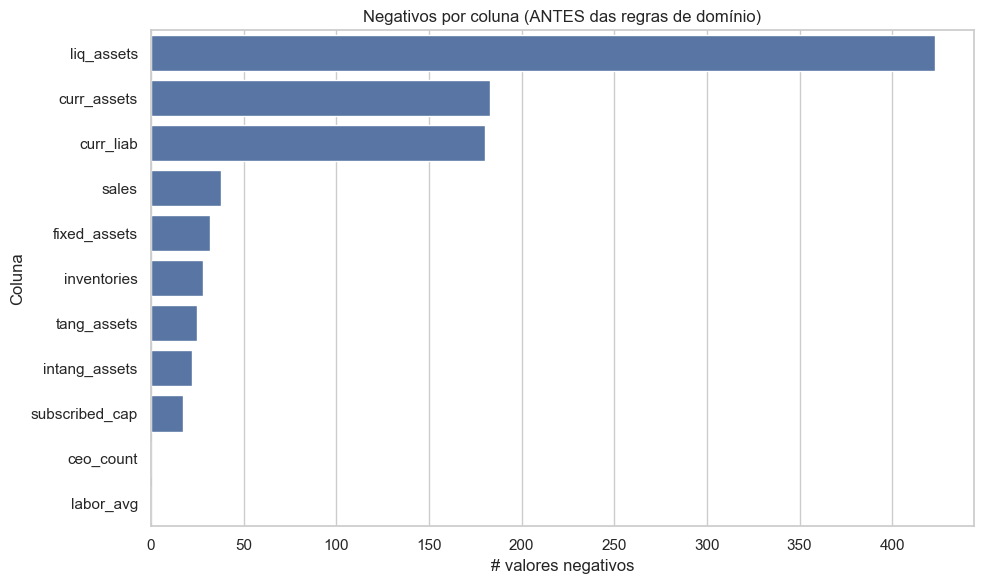

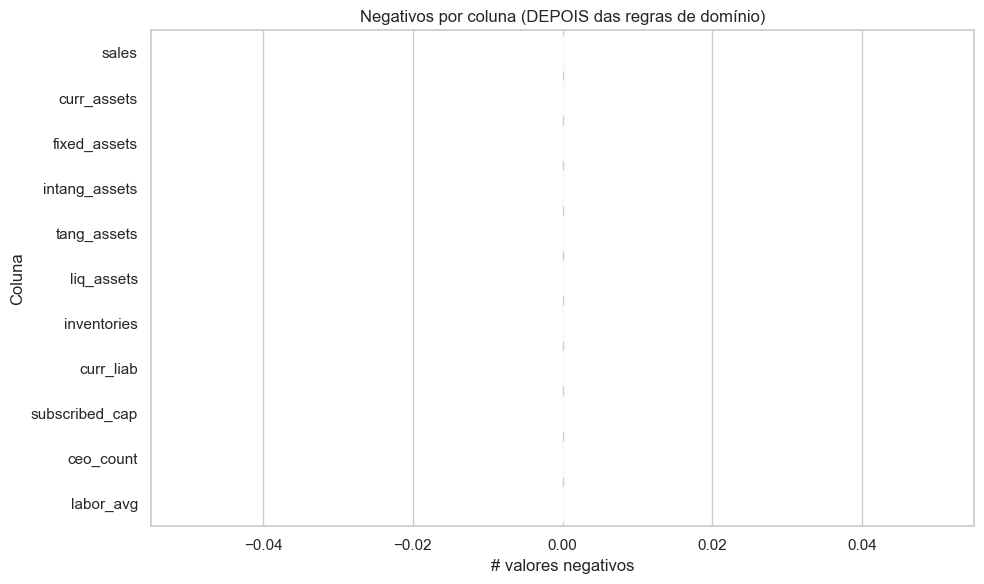

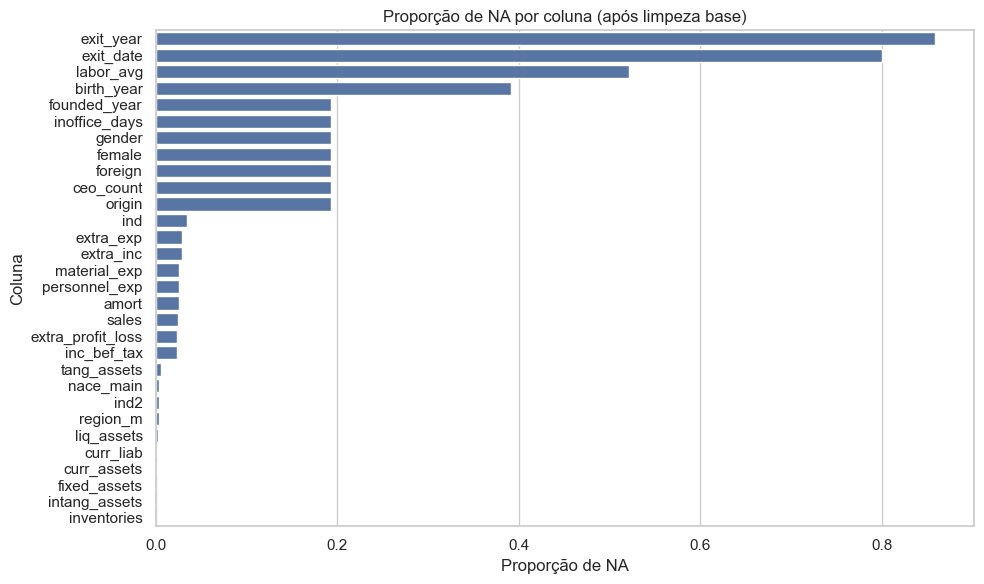

{'invalid_duration': 0, 'before_founding': 2901, 'after_event': 189, 'year_begin_misaligned': 0, 'row_sparse_missing': 0, 'firms_inconsistent_founded_gt_exit': 0}

[OK] Fase 4 concluída.
 - Dataset base limpo salvo em: bisnode_clean_base.csv
 - Figuras de diagnóstico em: /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1/outputs/processed/figs


In [4]:
# ============================================================
# FASE 4 — Limpeza e Regras de Domínio (sem aplicar winsor)
# ============================================================
# Comentários (PT-BR):
# - Esta célula produz um dataset base limpo (clean0) sem vazamento.
# - Define funções de winsor (fit/apply) para uso futuro (Fase 6).
# - Gera diagnósticos quantitativos e salva artefatos (PNG/JSON/Parquet).

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Pré-checagens (projeto/variáveis globais das fases anteriores) ----------
if "CFG" not in globals():
    raise RuntimeError("CFG não encontrado. Execute a Fase 2 antes da Fase 4.")
if "raw" not in globals():
    raise RuntimeError("Variável 'raw' não encontrada. Execute a Fase 2 antes da Fase 4.")
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("outputs/processed")
if "FIG_DIR" not in globals():
    FIG_DIR = OUTPUT_DIR / "figs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

# ---------- Utilitários mínimos (robustos e simples) ----------
NA_TOKENS = {"na", "n/a", "", "none", "null", "nan"}

PROTECTED_COLS = {
    CFG.id_col, CFG.year_col,
    CFG.begin_col, CFG.end_col,
    CFG.founded_date_col, CFG.exit_date_col,
    # Mantemos chaves e datas sempre; 'D' é útil para auditoria → não dropar
    "D"
}

def drop_columns_data_driven(df: pd.DataFrame,
                             max_na_share: float = getattr(CFG, "na_drop_pre", 0.95),
                             min_nonnull: int = getattr(CFG, "na_drop_pre_minnonnull", 50),
                             drop_zero_var: bool = True,
                             protected: set = PROTECTED_COLS):
    """
    Regras:
      - Drop colunas com na_share >= max_na_share (pré-imputação).
      - Drop colunas com não-nulos < min_nonnull (sinal de baixa informação).
      - (Opcional) Drop colunas com variância zero (constantes).
    Retorna df_reduzido, artefatos.
    """
    d = df.copy()
    to_drop = set()

    na_share = d.isna().mean()
    to_drop |= {c for c, s in na_share.items() if s >= max_na_share and c not in protected}

    nonnull = d.notna().sum()
    to_drop |= {c for c, k in nonnull.items() if k < min_nonnull and c not in protected}

    if drop_zero_var:
        nunique = d.nunique(dropna=True)
        to_drop |= {c for c, k in nunique.items() if k <= 1 and c not in protected}

    to_drop = sorted(to_drop)
    d = d.drop(columns=[c for c in to_drop if c in d.columns])

    artifacts = {
        "max_na_share": float(max_na_share),
        "min_nonnull": int(min_nonnull),
        "zero_var": bool(drop_zero_var),
        "dropped_cols": to_drop
    }
    return d, artifacts

def fill_industry_from_nace(df: pd.DataFrame) -> pd.DataFrame:
    """Preenche ind2_2d a partir de nace_main_2d quando ind2_2d está ausente/vazio."""
    d = df.copy()
    if CFG.industry_col in d.columns and CFG.nace_col in d.columns:
        m = d[CFG.industry_col].isna() | (d[CFG.industry_col].astype("string").str.len() == 0)
        d.loc[m, CFG.industry_col] = d.loc[m, CFG.nace_col].astype("string")
    return d

def normalize_na_tokens(df: pd.DataFrame) -> pd.DataFrame:
    """Converte tokens comuns de NA (strings) em NaN, sem alterar tipos numéricos válidos."""
    d = df.copy()
    for c in d.columns:
        if d[c].dtype == object:
            d[c] = d[c].apply(
                lambda x: np.nan if isinstance(x, str) and x.strip().lower() in NA_TOKENS else x
            )
    return d

def coerce_numeric(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Converte colunas para numérico quando possível; valores inválidos viram NaN."""
    d = df.copy()
    for c in cols:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")
    return d

def clip01(s: pd.Series) -> pd.Series:
    """Garante que shares fiquem em [0,1]; fora disso vira NaN (em vez de truncar)."""
    s_num = pd.to_numeric(s, errors="coerce")
    return s_num.where(s_num.between(0, 1), np.nan)

def enforce_domain(df: pd.DataFrame, nonneg_cols: tuple, share_cols: tuple) -> pd.DataFrame:
    """
    Aplica regras de domínio:
    - Não-negatividade para métricas contábeis.
    - Shares ∈ [0,1] (fora do intervalo vira NaN).
    """
    d = df.copy()
    # Não-negatividade
    for c in nonneg_cols:
        if c in d.columns:
            s = pd.to_numeric(d[c], errors="coerce")
            d[c] = s.where(s >= 0, np.nan)
    # Shares
    for c in share_cols:
        if c in d.columns:
            d[c] = clip01(d[c])
    return d

# Funções de winsor (para usar na Fase 6 — fit no treino e aplicar em treino/teste)
def winsor_caps_fit(df: pd.DataFrame, cols: list, by: list,
                    q_lo=0.01, q_hi=0.99, min_n=25) -> pd.DataFrame:
    """
    Calcula limites de winsor por grupo (por exemplo, ano×setor), apenas onde há dados suficientes.
    Não aplica recorte aqui — apenas retorna o DataFrame de caps.
    """
    recs = []
    g = df.groupby(by, dropna=False)
    for keys, sub in g:
        if len(sub) < min_n:
            continue
        for c in cols:
            if c in sub.columns:
                s = pd.to_numeric(sub[c], errors="coerce").dropna()
                if len(s) < min_n:
                    continue
                lo, hi = s.quantile(q_lo), s.quantile(q_hi)
                keys_map = dict(zip(by, keys if isinstance(keys, tuple) else (keys,)))
                recs.append({**keys_map, "col": c, "low": float(lo), "high": float(hi)})
    caps = pd.DataFrame(recs, columns=by + ["col", "low", "high"])
    return caps

def winsor_apply(df: pd.DataFrame, caps: pd.DataFrame, by: list) -> pd.DataFrame:
    """
    Aplica winsorização usando 'caps' pré-calculados. 
    OBS: usar somente após split (Fase 6) para evitar vazamento.
    """
    if caps is None or caps.empty:
        return df.copy()
    d = df.copy()
    idx_cols = by + ["col", "low", "high"]
    for _, r in caps[idx_cols].iterrows():
        # Seleciona grupo alvo (inclui NaN-safe)
        mask = np.ones(len(d), dtype=bool)
        for b in by:
            mask &= (d[b] == r[b]) | (d[b].isna() & pd.isna(r[b]))
        c = r["col"]
        if c in d.columns:
            d.loc[mask, c] = pd.to_numeric(d.loc[mask, c], errors="coerce").clip(r["low"], r["high"])
    return d

# Gráfico rápido (fallback) — usado nos diagnósticos desta fase
def _plot_nonneg_flags(df: pd.DataFrame, cols: tuple, title: str, path: Path = None):
    recs = []
    for c in cols:
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            recs.append({"col": c, "neg_count": int((s < 0).sum()), "nonnull": int(s.notna().sum())})
    out = pd.DataFrame.from_records(recs)
    if out.empty:
        print("[INFO] Sem colunas para checar.")
        return
    out = out.sort_values("neg_count", ascending=False)
    ax = sns.barplot(data=out, x="neg_count", y="col", orient="h")
    ax.set_title(title); ax.set_xlabel("# valores negativos"); ax.set_ylabel("Coluna")
    plt.tight_layout()
    if path is not None:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=150)
    plt.show()

def _plot_missing_share(df: pd.DataFrame, topn=30, title="Proporção de NA por coluna", path: Path = None):
    miss = df.isna().mean().sort_values(ascending=False).head(topn)
    ax = sns.barplot(x=miss.values, y=miss.index, orient="h")
    ax.set_title(title); ax.set_xlabel("Proporção de NA"); ax.set_ylabel("Coluna")
    plt.tight_layout()
    if path is not None:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=150)
    plt.show()

# ---------- Pipeline de limpeza base ----------
print("\n[FASE 4] Iniciando limpeza base (sem winsor).")

# 0) Garantir chaves mínimas
if CFG.id_col not in raw.columns or CFG.year_col not in raw.columns:
    raise ValueError("Colunas-chave ausentes (comp_id/year). Verifique a Fase 2.")

# 1) Normalizar tokens de NA
raw_norm = normalize_na_tokens(raw)

# 2) Removendo colunas c/ muitos missing
COLS_TO_DROP = ['COGS', 'finished_prod', 'net_dom_sales', 'net_exp_sales', 'wages', 'D']
cols_actually_dropped = [c for c in COLS_TO_DROP if c in raw_norm.columns]
print(f"[INFO] Dropping columns: {cols_actually_dropped}")
raw_norm = raw_norm.drop(columns=cols_actually_dropped)
print(f"[INFO] Columns remaining: {raw_norm.shape[1]}")

# 2) Poda de colunas com base em NA/variância (data-driven). Mantemos 'D' (auditoria).
raw_norm, col_prune_art = drop_columns_data_driven(
    raw_norm,
    max_na_share=getattr(CFG, "na_drop_pre", 0.95),
    min_nonnull=getattr(CFG, "na_drop_pre_minnonnull", 50),
    drop_zero_var=True,
    protected=PROTECTED_COLS
)
print(f"[INFO] Colunas removidas (pré-imputação): {len(col_prune_art['dropped_cols'])}")
if col_prune_art['dropped_cols']:
    print("       →", col_prune_art['dropped_cols'][:25], "..." if len(col_prune_art['dropped_cols']) > 25 else "")

# 3) Retirar a data de 2016, já que a quantidade de firmas cai drasticamente
records_2016 = (raw_norm[CFG.year_col] == 2016).sum()
raw_norm = raw_norm[raw_norm[CFG.year_col] != 2016]
print(f"[INFO] Removidos {records_2016} de 2016")

# 4) Coerção de tipos nas colunas-alvo (não-neg e shares)
cols_to_num = list(CFG.nonneg_cols) + list(CFG.share_like_cols)
raw_coerced = coerce_numeric(raw_norm, cols_to_num)

# 5) Diagnóstico "antes": negativos e shares fora de [0,1]
neg_before = {}
for c in CFG.nonneg_cols:
    if c in raw_coerced.columns:
        s = pd.to_numeric(raw_coerced[c], errors="coerce")
        neg_before[c] = int((s < 0).sum())
share_oob_before = {}
for c in CFG.share_like_cols:
    if c in raw_coerced.columns:
        s = pd.to_numeric(raw_coerced[c], errors="coerce")
        share_oob_before[c] = int((~s.between(0, 1)).sum())

print("[DQ] Antes da regra de domínio — negativos (top 10):",
      sorted([(k,v) for k,v in neg_before.items() if v>0], key=lambda x: x[1], reverse=True)[:10])
print("[DQ] Antes da regra de domínio — shares fora [0,1]:", share_oob_before)

# 6) Aplicar regras de domínio
clean0 = enforce_domain(raw_coerced, CFG.nonneg_cols, CFG.share_like_cols)

# 7) Sanidade de chaves: remover linhas sem id/ano
rows_before = len(clean0)
mask_valid = clean0[CFG.id_col].notna() & clean0[CFG.year_col].notna()
dropped_no_keys = int(rows_before - mask_valid.sum())
clean0 = clean0.loc[mask_valid].copy()

# 7.5) Regras 100% data-driven para sobrevivência (mantendo 2016 excluído)
# ----------------------------------------------------------------------
# (a) begin>end -> drop
# (b) year<founded_year (se conhecido) -> drop
# (c) year>exit_year (se conhecido) -> drop (truncamento pós-evento; mantém ano do evento)
# (d) inconsistência firme: founded_date > exit_date -> drop empresa inteira
# (e) desalinhamento |begin.year - year| > 1 -> drop
# (f) anos raros (cobertura << mediana), além de 2016 já excluído -> drop
# (g) linhas com fração de NA extremamente alta em covariáveis -> drop

# --- Preparos (tipos e colunas) ---
b = pd.to_datetime(clean0.get(CFG.begin_col),   errors="coerce")
e = pd.to_datetime(clean0.get(CFG.end_col),     errors="coerce")
f = pd.to_datetime(clean0.get(CFG.founded_date_col), errors="coerce")
x = pd.to_datetime(clean0.get(CFG.exit_date_col),    errors="coerce")
y = pd.to_numeric(clean0.get(CFG.year_col), errors="coerce").astype("Int64")

# (a) Duração inválida
mask_invalid_duration = b.notna() & e.notna() & (e < b)

# (b) Pré-fundação
mask_before_found = f.notna() & y.notna() & (y < f.dt.year.astype("Int64"))

# (c) Pós-evento (truncamento à direita)
evt_year = x.dt.year.astype("Int64")
mask_after_event = evt_year.notna() & y.notna() & (y > evt_year)

# (d) Contradição grave fundação>saída → drop empresa inteira
firm_bad = (f.notna() & x.notna() & (f > x))
bad_firms = set(clean0.loc[firm_bad, CFG.id_col].dropna().unique().tolist())

# (e) Ano descolado de begin (tolerância de 1 ano)
mask_year_begin_misaligned = b.notna() & y.notna() & ((b.dt.year - y).abs() > 1)

# (g) Linhas extremamente faltantes (só em covariáveis, não datas/ids)
exclude_cols_row_na = {CFG.id_col, CFG.year_col, CFG.begin_col, CFG.end_col,
                       CFG.founded_date_col, CFG.exit_date_col}
X_cols = [c for c in clean0.columns if c not in exclude_cols_row_na]
row_na_share = clean0[X_cols].isna().mean(axis=1)
t_row = max(0.80, float(np.nanquantile(row_na_share, 0.99)))  # data-driven + piso
mask_row_sparse = row_na_share > t_row

# Máscara final de KEEP (linhas); e retiramos firmas inconsistentes
mask_keep = (~mask_invalid_duration) & (~mask_before_found) & (~mask_after_event) \
            & (~mask_year_begin_misaligned) & (~mask_row_sparse)
if bad_firms:
    mask_keep &= ~clean0[CFG.id_col].isin(bad_firms)

drops_row_counts = {
    "invalid_duration": int(mask_invalid_duration.sum()),
    "before_founding": int(mask_before_found.sum()),
    "after_event": int(mask_after_event.sum()),
    "year_begin_misaligned": int(mask_year_begin_misaligned.sum()),
    "row_sparse_missing": int(mask_row_sparse.sum()),
    "firms_inconsistent_founded_gt_exit": int(len(bad_firms)),
}

clean0_surv = clean0.loc[mask_keep].copy()

# (f) Anos raros, além de 2016 já excluído anteriormente
year_counts = clean0_surv[CFG.year_col].value_counts().sort_index()
if len(year_counts) > 0:
    thr_year = max(int(year_counts.median() * getattr(CFG, "sparse_year_min_share", 0.20)),
                   int(getattr(CFG, "sparse_year_min_abs", 30)))
    sparse_years = year_counts[year_counts < thr_year].index.tolist()
else:
    thr_year = 0
    sparse_years = []

if sparse_years:
    clean0_surv = clean0_surv[~clean0_surv[CFG.year_col].isin(sparse_years)].copy()

print("[INFO] Drops data-driven (linhas):", drops_row_counts)
print(f"[INFO] Anos raros removidos (<{thr_year} linhas): {list(map(int, sparse_years)) if sparse_years else []}")
print(f"[INFO] Shape após regras de sobrevivência: {clean0_surv.shape}")

# Substitui clean0 para as próximas fases
clean0 = clean0_surv

clean0 = fill_industry_from_nace(clean0)

# 8) Diagnóstico "depois": negativos e shares fora de [0,1]
neg_after = {}
for c in CFG.nonneg_cols:
    if c in clean0.columns:
        s = pd.to_numeric(clean0[c], errors="coerce")
        neg_after[c] = int((s < 0).sum())
share_oob_after = {}
for c in CFG.share_like_cols:
    if c in clean0.columns:
        s = pd.to_numeric(clean0[c], errors="coerce")
        share_oob_after[c] = int((~s.between(0, 1)).sum())

print("[DQ] Depois da regra de domínio — negativos (esperado 0 nas colunas tratadas):",
      {k:v for k,v in neg_after.items() if v>0})
print("[DQ] Depois da regra de domínio — shares fora [0,1] (esperado 0):", 
      {k:v for k,v in share_oob_after.items() if v>0})

# 9) Variação de missing por coluna (antes vs depois)
delta_missing = {}
for c in clean0.columns:
    if c in raw_coerced.columns:
        delta_missing[c] = int(clean0[c].isna().sum() - raw_coerced[c].isna().sum())
# Top colunas que ganharam mais NaN (tipicamente onde havia inválidos)
top_delta = sorted(delta_missing.items(), key=lambda x: x[1], reverse=True)[:10]
print("[DQ] Aumento de NaN por coluna (top 10):", top_delta)

# 10) Gráficos rápidos de diagnóstico (antes vs depois)
try:
    _plot_nonneg_flags(raw_coerced, CFG.nonneg_cols, 
                       title="Negativos por coluna (ANTES das regras de domínio)",
                       path=FIG_DIR / "dq_negativos_antes.png")
    _plot_nonneg_flags(clean0, CFG.nonneg_cols, 
                       title="Negativos por coluna (DEPOIS das regras de domínio)",
                       path=FIG_DIR / "dq_negativos_depois.png")
    _plot_missing_share(clean0, topn=30, 
                        title="Proporção de NA por coluna (após limpeza base)",
                        path=FIG_DIR / "dq_missingpos_limpeza.png")
except Exception as e:
    print("[AVISO] Falha ao gerar gráficos de diagnóstico:", e)

# 11) Sinalização de colunas potencialmente problemáticas (tudo NaN após limpeza)
cols_all_na = [c for c in clean0.columns if clean0[c].isna().all()]
if cols_all_na:
    print(f"[ALERTA] Colunas com 100% NaN após limpeza: {cols_all_na[:15]}{' ...' if len(cols_all_na)>15 else ''}")

# 12) Persistência de artefatos
clean_base_csv = OUTPUT_DIR / "bisnode_clean_base.csv"
clean0.to_csv(clean_base_csv, index=False)
print(drops_row_counts)
clean_report = {
    "rows_input": int(len(raw)),
    "rows_output": int(len(clean0)),
    "dropped_no_keys": dropped_no_keys,
    "negatives_before": {k:int(v) for k,v in neg_before.items()},
    "negatives_after": {k:int(v) for k,v in neg_after.items()},
    "share_oob_before": {k:int(v) for k,v in share_oob_before.items()},
    "share_oob_after": {k:int(v) for k,v in share_oob_after.items()},
    "delta_missing_top": top_delta,
    "cols_all_na_after": cols_all_na,
    "row_drops": drops_row_counts,
    "sparse_years_threshold": int(thr_year),
    "sparse_years_removed": [int(y) for y in sparse_years] if sparse_years else [],
    "col_prune_pre": col_prune_art,

    "config": {
        "nonneg_cols": list(CFG.nonneg_cols),
        "share_like_cols": list(CFG.share_like_cols),
    }
}

print("\n[OK] Fase 4 concluída.")
print(" - Dataset base limpo salvo em:", clean_base_csv.name)
print(" - Figuras de diagnóstico em:", FIG_DIR)


# Fase 5 — Indicadores de Missing + Imputação por Grupo (leve) {#fase-5-imputacao-leve}

**Objetivo.** Sinalizar onde havia ausências (indicadores `miss__*`) e aplicar uma **imputação leve por (ano × setor)** para reduzir buracos antes da imputação avançada (MICE+RandomForest na Fase 6).  
> Por que por grupo? **Heterogeneidade setorial/temporal**: medianas/modas mudam ao longo dos anos e entre setores; essa estratégia reduz viés.

**O que fazemos aqui**
1. **Indicadores de missing** (`miss__col`) para *todas* as colunas com NA — preservamos informação de ausência (útil ao risco de saída).
2. **Imputação leve**:
   - **Numéricas**: mediana por `(year, ind2_2d)` quando o grupo tem dados suficientes; senão, **mediana global**.
   - **Categóricas**: **moda** por `(year, ind2_2d)` (com fallback global).
   - **Nunca** imputamos chaves, datas ou as próprias chaves de grupo.
3. **Relatório objetivo**: quantos valores foram imputados por coluna; variação de missing antes/depois; parâmetros usados.
4. **Persistência**: versões com e sem imputação leve (para auditoria).
   - `bisnode_clean_lvl1/csv` → `clean1` (apenas indicadores).
   - `bisnode_clean_lvl1_imputed_light/csv` → `clean1_imputed` (com imputação leve).
5. **Nota importante (sem vazamento):** a **imputação principal** será feita **só no treino** (Fase 6), com MICE+RF.  
   A imputação leve aqui **não substitui** a imputação principal; ela serve para **estabilizar** winsor e MICE e facilitar EDA/modelagem.





[FASE 5] Criando indicadores de missing e realizando imputação leve por grupo...
[INFO] Indicadores de missing criados: 34
[DQ] Top 10 colunas que mais reduziram NA (valores imputados): [('labor_avg', 143408), ('ceo_count', 53129), ('foreign', 53129), ('female', 53129), ('inoffice_days', 53129), ('gender', 53129), ('origin', 53129), ('ind', 9330), ('extra_exp', 7839), ('extra_inc', 7839)]
[DQ] Top 10 colunas ainda com NA após imputação leve: ['exit_year', 'exit_date', 'birth_year', 'founded_year', 'profit_loss_year', 'founded_date']


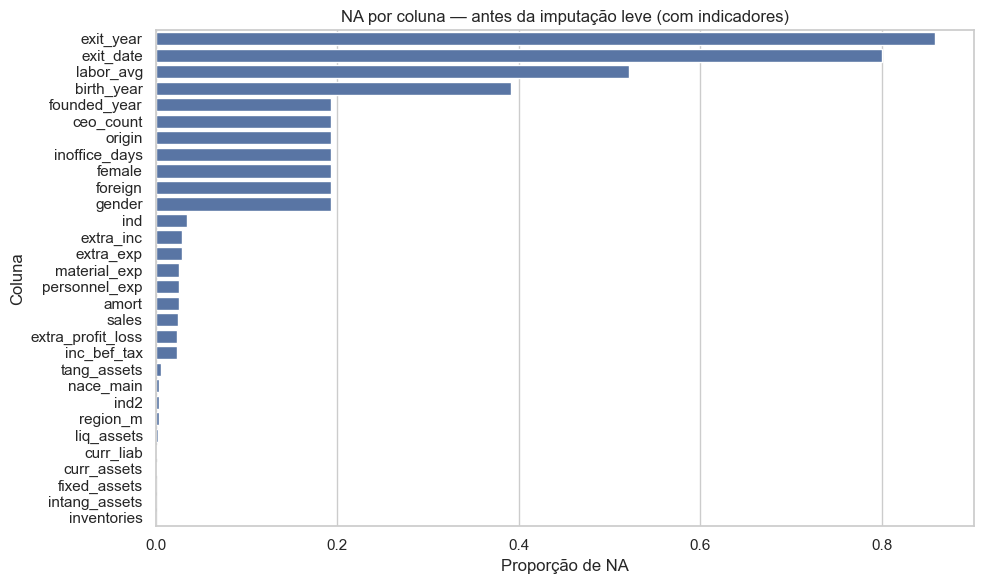

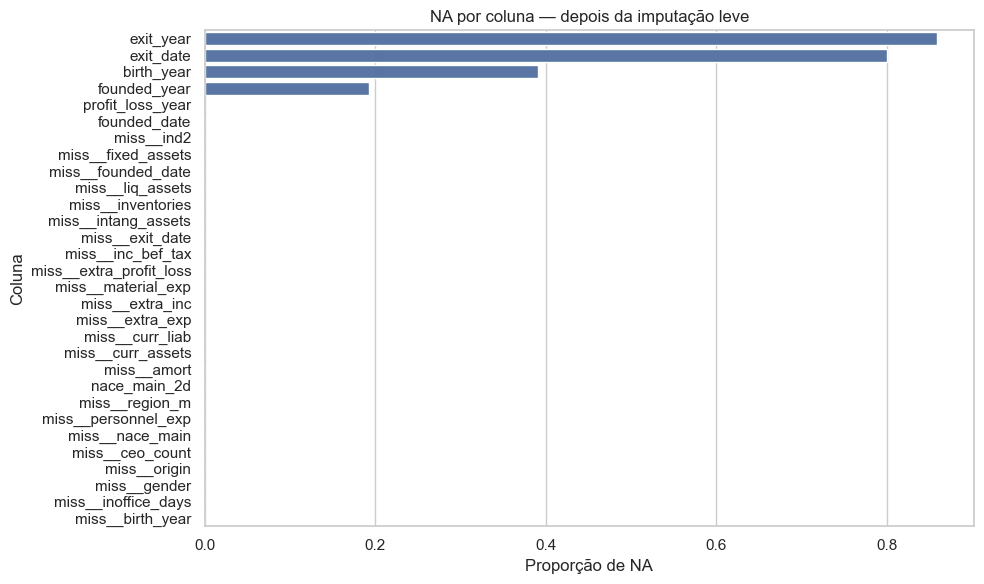


[OK] Fase 5 concluída.
 - clean1_imputed (imputação leve) salvo em: bisnode_clean_lvl1_imputed_light.csv
 - Figuras em: /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1/outputs/processed/figs


In [5]:
# ============================================================
# FASE 5 — Indicadores de Missing + Imputação leve por grupo
# ============================================================
# Comentários (PT-BR):
# - Esta fase cria indicadores de missing (miss__*) e faz uma imputação leve por (year × ind2_2d).
# - Não altera chaves (id/year), nem datas; não aplica winsor aqui (Fase 6).
# - Gera diagnóstico, figuras e um relatório JSON com estatísticas de imputação.
# - O dataset "clean1_imputed" ainda passará por split + winsor + MICE (sem vazamento) na Fase 6.

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Pré-checagens ----------
if "CFG" not in globals():
    raise RuntimeError("CFG não encontrado. Execute as Fases 0–4 antes da Fase 5.")
if "clean0" not in globals():
    raise RuntimeError("Variável 'clean0' não encontrada. Execute a Fase 4 antes da Fase 5.")
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("outputs/processed")
if "FIG_DIR" not in globals():
    FIG_DIR = OUTPUT_DIR / "figs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

# ---------- Funções (simples, robustas) ----------
def build_missing_indicators(df: pd.DataFrame, prefix: str = "miss__"):
    """
    Cria colunas binárias (0/1) indicando posições originalmente ausentes.
    Mantém os nomes como 'miss__<col>' e retorna (df_com_flags, lista_flags).
    """
    d = df.copy()
    created = []
    for c in d.columns:
        m = d[c].isna()
        if m.any():
            name = f"{prefix}{c}"
            d[name] = m.astype(int)
            created.append(name)
    return d, created

def _mode_safe(s: pd.Series):
    """Moda segura (retorna NaN se não existir)."""
    m = s.mode(dropna=True)
    return m.iloc[0] if m.size > 0 else np.nan

def impute_by_group_simple(
    df: pd.DataFrame,
    group_keys=("year", "ind2_2d"),
    min_nonnull: int = 25,
    exclude_cols: list = None
):
    """
    Imputa faltantes por grupo com fallback global.
    - Numéricas: mediana (grupo se tiver >= min_nonnull não-nulos; senão, global).
    - Categóricas: moda (grupo se tiver >= min_nonnull; senão, global).
    - Exclui chaves, datas e colunas no 'exclude_cols'.
    Retorna: (df_imputed, stats_dict) com estatísticas globais por coluna.
    """
    d = df.copy()

    # Chaves e datas que não devem ser imputadas
    date_like = list(d.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns)
    
    default_exclude = {
        CFG.id_col, CFG.year_col, getattr(CFG, "begin_col", "begin"),
        getattr(CFG, "end_col", "end"),
        getattr(CFG, "exit_date_col", "exit_date"),
        getattr(CFG, "founded_date_col", "founded_date"),
        # NÃO imputar campos de ano de datas de sobrevivência
        "exit_year", "founded_year"
    }
    # Também exclui genericamente qualquer coluna que termine em "_year"
    default_exclude |= {c for c in df.columns if isinstance(c, str) and c.endswith("_year")}

    if exclude_cols is None:
        exclude_cols = []
    exclude = set(exclude_cols) | set(date_like) | default_exclude | set(group_keys)

    # Grupo (se existir)
    keys_present = [k for k in group_keys if k in d.columns]
    g = d.groupby(keys_present, dropna=False) if keys_present else None

    stats = {}
    imputations_count = {}

    for c in d.columns:
        if c in exclude:
            continue

        # Conta missings antes
        miss_before = d[c].isna().sum()

        if miss_before == 0:
            continue

        if pd.api.types.is_numeric_dtype(d[c]):
            if g is not None:
                med_grp = g[c].median()
                enough = g[c].apply(lambda x: x.notna().sum() >= min_nonnull)
                med_glob = d[c].median()

                # função que escolhe a mediana por grupo se houver dados suficientes
                def _fill_num(sub: pd.Series, key):
                    if key in enough.index and enough.loc[key]:
                        val = med_grp.loc[key]
                    else:
                        val = med_glob
                    return sub.fillna(val)

                d[c] = g[c].transform(lambda x: _fill_num(x, x.name))
                stats[c] = {
                    "type": "numeric",
                    "global_median": None if pd.isna(med_glob) else float(med_glob),
                    "by_group": True,
                    "min_nonnull": int(min_nonnull),
                }
            else:
                med = d[c].median()
                d[c] = d[c].fillna(med)
                stats[c] = {
                    "type": "numeric",
                    "global_median": None if pd.isna(med) else float(med),
                    "by_group": False,
                    "min_nonnull": int(min_nonnull),
                }
        else:
            # Categóricas: moda
            if g is not None:
                mode_grp = g[c].agg(_mode_safe)
                enough = g[c].apply(lambda x: x.notna().sum() >= min_nonnull)
                mode_glob = _mode_safe(d[c])

                def _fill_cat(sub: pd.Series, key):
                    if key in enough.index and enough.loc[key]:
                        val = mode_grp.loc[key]
                    else:
                        val = mode_glob
                    return sub.fillna(val)

                d[c] = g[c].transform(lambda x: _fill_cat(x, x.name))
                stats[c] = {
                    "type": "categorical",
                    "global_mode": None if pd.isna(mode_glob) else mode_glob,
                    "by_group": True,
                    "min_nonnull": int(min_nonnull),
                }
            else:
                mv = _mode_safe(d[c])
                d[c] = d[c].fillna(mv)
                stats[c] = {
                    "type": "categorical",
                    "global_mode": None if pd.isna(mv) else mv,
                    "by_group": False,
                    "min_nonnull": int(min_nonnull),
                }

        # Conta quantos foram imputados
        miss_after = d[c].isna().sum()
        imputations_count[c] = int(miss_before - miss_after)

    return d, stats, imputations_count

# ---------- Execução da Fase 5 ----------
print("\n[FASE 5] Criando indicadores de missing e realizando imputação leve por grupo...")

# 1) Indicadores de missing
clean1, miss_cols = build_missing_indicators(clean0, prefix="miss__")
print(f"[INFO] Indicadores de missing criados: {len(miss_cols)}")

# 1.5) Preenche setor antes da imputação leve (melhor base p/ moda por grupo)
clean1 = fill_industry_from_nace(clean1)

# 2) Imputação leve (por grupo year × ind2_2d, com fallback global)
min_nonnull = getattr(CFG, "min_nonnull_per_col", 25)
group_keys = getattr(CFG, "impute_group_keys", ("year", "ind2_2d"))

clean1_imputed, group_imp_stats, imputed_counts = impute_by_group_simple(
    clean1,
    group_keys=group_keys,
    min_nonnull=min_nonnull,
    exclude_cols=list(set(miss_cols))  # não imputamos os próprios indicadores
)

# 3) Diagnóstico: variação de missing antes/depois
missing_before = clean1.isna().sum()
missing_after  = clean1_imputed.isna().sum()
delta_missing  = (missing_after - missing_before).sort_values(ascending=False)

# Top colunas ainda com missing
top_still_missing = missing_after[missing_after > 0].sort_values(ascending=False).head(20)

print("[DQ] Top 10 colunas que mais reduziram NA (valores imputados):",
      sorted([(k, v) for k, v in imputed_counts.items() if v > 0],
             key=lambda x: x[1], reverse=True)[:10])

print("[DQ] Top 10 colunas ainda com NA após imputação leve:",
      list(top_still_missing.index[:10]))

# 4) Figuras (missing antes/depois)
def _plot_missing_share(df: pd.DataFrame, topn=30, title="Proporção de NA por coluna", path: Path = None):
    miss = df.isna().mean().sort_values(ascending=False).head(topn)
    ax = sns.barplot(x=miss.values, y=miss.index, orient="h")
    ax.set_title(title); ax.set_xlabel("Proporção de NA"); ax.set_ylabel("Coluna")
    plt.tight_layout()
    if path is not None:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=150)
    plt.show()

try:
    _plot_missing_share(clean1, topn=30,
                        title="NA por coluna — antes da imputação leve (com indicadores)",
                        path=FIG_DIR / "fase5_missing_before.png")
    _plot_missing_share(clean1_imputed, topn=30,
                        title="NA por coluna — depois da imputação leve",
                        path=FIG_DIR / "fase5_missing_after.png")
except Exception as e:
    print("[AVISO] Falha ao gerar gráficos de missing na Fase 5:", e)

# 5) Persistência (versão com e sem imputação leve)
lvl1_csv = OUTPUT_DIR / "bisnode_clean_lvl1.csv"
lvl1_imp_csv = OUTPUT_DIR / "bisnode_clean_lvl1_imputed_light.csv"

clean1.to_csv(lvl1_csv, index=False)
clean1_imputed.to_csv(lvl1_imp_csv, index=False)

# 6) Relatório JSON (transparência e reprodutibilidade)
report = {
    "group_keys_used": [k for k in group_keys if k in clean1.columns],
    "min_nonnull": int(min_nonnull),
    "n_indicators": int(len(miss_cols)),
    "imputed_counts_top": sorted(
        [(k, int(v)) for k, v in imputed_counts.items() if v > 0],
        key=lambda x: x[1],
        reverse=True
    )[:30],
    "still_missing_top": {k: int(v) for k, v in top_still_missing.to_dict().items()},
    "stats_examples": {k: v for k, v in list(group_imp_stats.items())[:10]},  # amostra p/ leitura
}

print("\n[OK] Fase 5 concluída.")
print(" - clean1_imputed (imputação leve) salvo em:", lvl1_imp_csv.name)
print(" - Figuras em:", FIG_DIR)

# Mantém objetos-chave no namespace global para as próximas fases
# (Fase 6 vai partir de 'clean1_imputed' para split + winsor + MICE sem vazamento)


# Fase 6 — Split sem vazamento + Winsor (fit no treino) + Imputação MICE+RandomForest {#fase-6}

**Objetivo.** Separar **treino** e **teste** primeiro (evitando vazamento de informação), **ajustar winsor** (limites por quantis) **usando somente o treino**, aplicar esses limites **em ambos** os conjuntos, e **imputar faltantes** com abordagem **MICE + RandomForest** para numéricas e **moda** para categóricas.  
> Por que assim? Estatísticas (quantis/medianas/modas) calculadas com todo o conjunto “vazam” informação do teste. Ajustamos **tudo no treino** e **só transformamos** o teste.

**Passos desta fase**
1. **Carregar `clean1_imputed`** (saída da Fase 5).  
2. **Split treino/teste** (estratificado por setor se possível).  
3. **Winsorizar**: ajustar **caps** (1%–99% por `year × ind2_2d`) **no treino** e **aplicar** nos dois conjuntos.  
4. **Imputação avançada** (sem vazamento):  
   - **Numéricas**: MICE via `IterativeImputer` com `RandomForestRegressor`.  
   - **Categóricas**: `SimpleImputer(strategy="most_frequent")`.  
   - **Shares** (`foreign`, `female`): **reclip** para `[0,1]` após imputar.  
   - (Opcional) `MissForest` se disponível; mantemos **MICE+RF** como padrão por simplicidade/reprodutibilidade.  
5. **Diagnósticos**: missing antes/depois, histograma sobreposto de `sales` (antes vs. depois), e **artefatos salvos**:
   - `bisnode_train_winsor_mice.parquet/csv`, `bisnode_test_winsor_mice.csv`
   - `winsor_caps__train_fit.parquet/csv`
   - `imputer_mice_rf.pkl` (via joblib) 

> **Importante:** Se existirem células antigas que **winsorizam/imputam antes do split**, **substitua** por esta fase para garantir a integridade do desenho experimental.


[INFO] Split realizado: treino=(219996, 78), teste=(55000, 78), estratificação=sim
[OK] Winsor hierárquico aplicado.
     → Treino: linhas clipadas por coluna: {'ceo_count': 594, 'curr_assets': 2824, 'curr_liab': 2272, 'fixed_assets': 2261, 'intang_assets': 2258, 'inventories': 2244, 'labor_avg': 1609, 'liq_assets': 2382, 'sales': 2257, 'subscribed_cap': 3967, 'tang_assets': 2256}
     → Teste : linhas clipadas por coluna: {'ceo_count': 34, 'curr_assets': 729, 'curr_liab': 633, 'fixed_assets': 611, 'intang_assets': 579, 'inventories': 544, 'labor_avg': 430, 'liq_assets': 642, 'sales': 586, 'subscribed_cap': 1112, 'tang_assets': 595}
[OK] Caps hierárquicos salvos: winsor_caps_hier__train_fit.csv


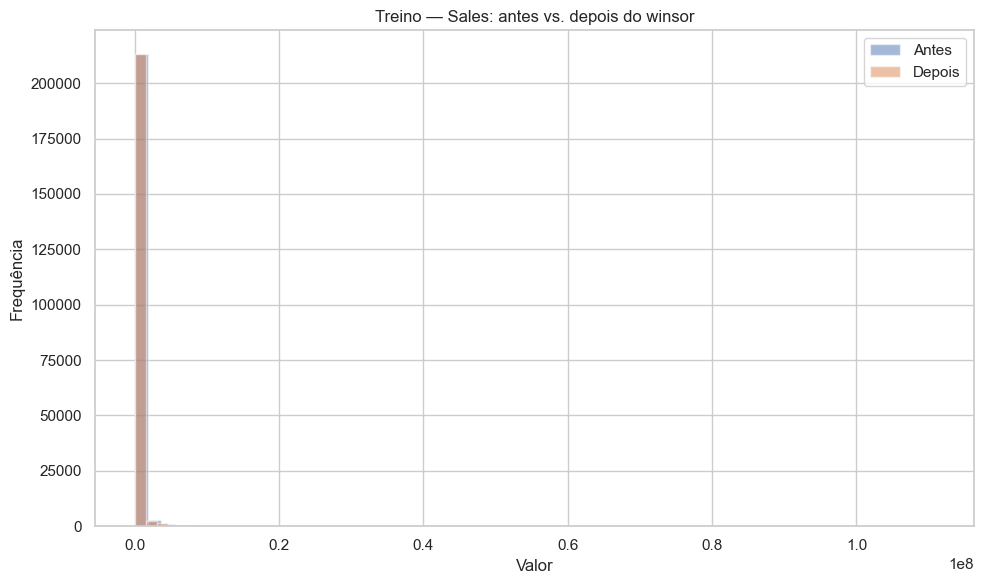

[INFO] Imputação concluída: IterativeImputer+RandomForest(numéricas) + Moda(categóricas)
[OK] Re-clip pós-imputação aplicado.
     → Treino (ajustes): {'ceo_count': 187}
     → Teste  (ajustes): {'ceo_count': 181}

[DQ] Top colunas ainda com NA (treino):
exit_date       0.800265
founded_date    0.000182

[DQ] Top colunas ainda com NA (teste):
exit_date       0.801345
founded_date    0.000127


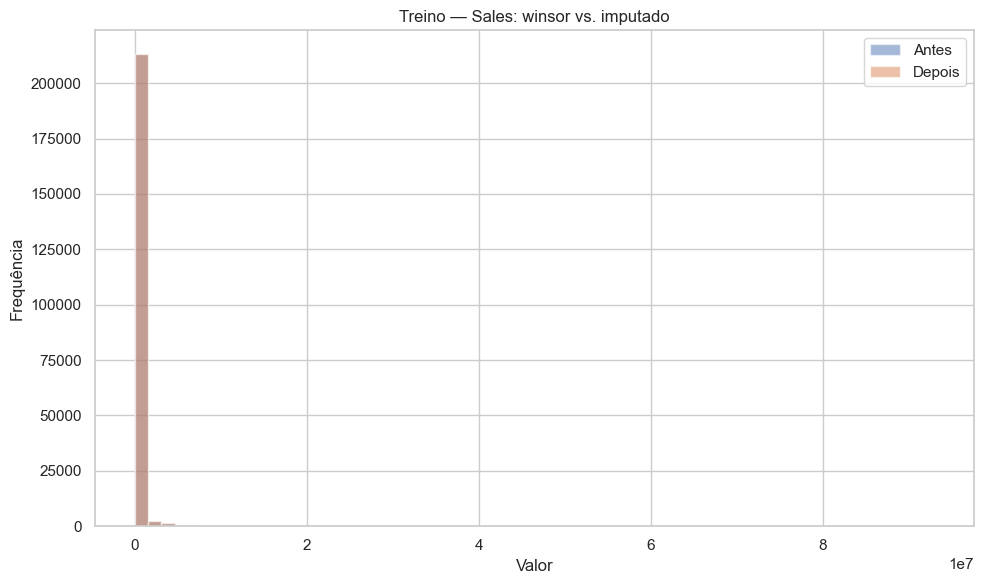


[OK] Fase 6 concluída.
 - Treino salvo em: bisnode_train_winsor_mice.csv
 - Teste  salvo em: bisnode_test_winsor_mice.csv
 - Caps (winsor)  : winsor_caps_hier__train_fit.csv
 - Imputador numérico (MICE+RF): imputer_mice_rf.pkl


In [6]:
# ============================================================
# FASE 6 — Split sem vazamento + Winsor (fit no treino) + MICE+RF
# ============================================================
# Comentários (PT-BR):
# - Esta fase parte de 'clean1_imputed' (Fase 5).
# - Faz split (com estratificação por setor, se possível), ajusta winsor apenas no treino e aplica nos dois.
# - Imputa faltantes com MICE+RandomForest (numéricas) e moda (categóricas).
# - Salva artefatos e gera diagnósticos para rastreabilidade.

import warnings
from pathlib import Path
import joblib

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor

from pandas.api.types import is_string_dtype, is_categorical_dtype, is_object_dtype, is_numeric_dtype

# ---------- Pré-checagens e carregamento seguro ----------
if "CFG" not in globals():
    raise RuntimeError("CFG não encontrado. Execute as Fases 0–4 antes da Fase 6.")
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("outputs/processed")
if "FIG_DIR" not in globals():
    FIG_DIR = OUTPUT_DIR / "figs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


# ---------- Utilitários usados nesta fase ----------
def _fit_caps_by(df: pd.DataFrame, cols: list, group_cols: list,
                 q_lo: float, q_hi: float, min_n: int, level_name: str) -> pd.DataFrame:
    recs = []
    if not group_cols:
        return pd.DataFrame(columns=["col","low","high","level"])
    g = df.groupby(group_cols, dropna=False)
    for keys, sub in g:
        if len(sub) < min_n:
            continue
        for c in cols:
            if c in sub.columns:
                s = pd.to_numeric(sub[c], errors="coerce").dropna()
                if len(s) < min_n:
                    continue
                lo, hi = s.quantile(q_lo), s.quantile(q_hi)
                row = { "col": c, "low": float(lo), "high": float(hi), "level": level_name }
                if len(group_cols) == 1:
                    row[group_cols[0]] = keys
                else:
                    for gc, kv in zip(group_cols, keys if isinstance(keys, tuple) else (keys,)):
                        row[gc] = kv
                recs.append(row)
    return pd.DataFrame(recs)

def winsor_caps_fit_hier(train_df: pd.DataFrame, cols: list,
                         year_col: str, ind_col: str,
                         q_lo=0.01, q_hi=0.99, min_n=25, min_n_backoff=50):
    """
    Hierarquia: (year,ind) -> (year) -> (ind) -> (global)
    Retorna dict com DataFrames por nível e um 'caps_all' concatenado.
    """
    caps_yi = _fit_caps_by(train_df, cols, [year_col, ind_col], q_lo, q_hi, min_n, "year_industry")
    caps_y  = _fit_caps_by(train_df, cols, [year_col],      q_lo, q_hi, max(min_n_backoff, int(min_n*1.5)), "year")
    caps_i  = _fit_caps_by(train_df, cols, [ind_col],       q_lo, q_hi, max(min_n_backoff, int(min_n*1.5)), "industry")
    # Global
    recs = []
    for c in cols:
        if c in train_df.columns:
            s = pd.to_numeric(train_df[c], errors="coerce").dropna()
            if len(s) >= min_n:
                lo, hi = s.quantile(q_lo), s.quantile(q_hi)
                recs.append({"col": c, "low": float(lo), "high": float(hi), "level": "global"})
    caps_g = pd.DataFrame(recs, columns=["col","low","high","level"])

    caps_all = pd.concat([
        caps_yi.assign(_level_order=1),
        caps_y.assign(_level_order=2),
        caps_i.assign(_level_order=3),
        caps_g.assign(_level_order=4)
    ], ignore_index=True)

    return {"year_industry": caps_yi, "year": caps_y, "industry": caps_i, "global": caps_g, "all": caps_all}

def winsor_apply_hier(df: pd.DataFrame, caps_h: dict, year_col: str, ind_col: str) -> pd.DataFrame:
    """
    Aplica caps por coluna na ordem: (year,ind) -> (year) -> (ind) -> (global),
    garantindo dtypes compatíveis nas chaves de merge (year=Int64, ind=string).
    Retorna df ajustado e estatísticas de clipping.
    """
    d = df.copy()
    changed = {}

    # --- Alinhamento de dtypes das chaves no DataFrame de entrada ---
    if year_col in d.columns:
        d[year_col] = pd.to_numeric(d[year_col], errors="coerce").astype("Int64")
    if ind_col in d.columns:
        d[ind_col] = d[ind_col].astype("string")

    # Lista de colunas alvo
    target_cols = sorted(set(caps_h["all"]["col"].unique().tolist())) if not caps_h["all"].empty else []
    if not target_cols:
        return d, {"clipped_counts": {}, "notes": "No caps available; nothing applied."}

    for c in target_cols:
        low  = pd.Series(np.nan, index=d.index)
        high = pd.Series(np.nan, index=d.index)

        # 1) year × industry
        caps = caps_h["year_industry"]
        if (not caps.empty) and (c in caps["col"].unique()):
            m = caps[caps["col"] == c][[year_col, ind_col, "low", "high"]].copy()
            if year_col in m.columns:
                m[year_col] = pd.to_numeric(m[year_col], errors="coerce").astype("Int64")
            if ind_col in m.columns:
                m[ind_col] = m[ind_col].astype("string")
            d = d.merge(m.rename(columns={"low": "__low_yi", "high": "__high_yi"}),
                        on=[year_col, ind_col], how="left")
            low  = low.fillna(d["__low_yi"])
            high = high.fillna(d["__high_yi"])
            d.drop(columns=["__low_yi", "__high_yi"], inplace=True)

        # 2) year
        caps = caps_h["year"]
        if (not caps.empty) and (c in caps["col"].unique()):
            m = caps[caps["col"] == c][[year_col, "low", "high"]].copy()
            if year_col in m.columns:
                m[year_col] = pd.to_numeric(m[year_col], errors="coerce").astype("Int64")
            d = d.merge(m.rename(columns={"low": "__low_y", "high": "__high_y"}),
                        on=[year_col], how="left")
            low  = low.fillna(d["__low_y"])
            high = high.fillna(d["__high_y"])
            d.drop(columns=["__low_y", "__high_y"], inplace=True)

        # 3) industry
        caps = caps_h["industry"]
        if (not caps.empty) and (c in caps["col"].unique()):
            m = caps[caps["col"] == c][[ind_col, "low", "high"]].copy()
            if ind_col in m.columns:
                m[ind_col] = m[ind_col].astype("string")
            d = d.merge(m.rename(columns={"low": "__low_i", "high": "__high_i"}),
                        on=[ind_col], how="left")
            low  = low.fillna(d["__low_i"])
            high = high.fillna(d["__high_i"])
            d.drop(columns=["__low_i", "__high_i"], inplace=True)

        # 4) global
        caps = caps_h["global"]
        if not caps.empty:
            g = caps[caps["col"] == c]
            if len(g) == 1:
                low  = low.fillna(float(g["low"].iloc[0]))
                high = high.fillna(float(g["high"].iloc[0]))

        # Clip onde temos ambos limites
        msk = low.notna() & high.notna() & d[c].notna()
        before = pd.to_numeric(d.loc[msk, c], errors="coerce")
        d.loc[msk, c] = before.clip(low.loc[msk], high.loc[msk])
        clipped = int((before != d.loc[msk, c]).sum())
        if clipped > 0:
            changed[c] = clipped

    stats = {"clipped_counts": {k: int(v) for k, v in changed.items()},
             "notes": "Hierarchical caps applied with dtype-safe merges."}
    return d, stats

def _make_strat_series(df: pd.DataFrame, col: str):
    """
    Cria série de estratificação robusta:
    - Mantém apenas classes com pelo menos 2 observações (requisito do train_test_split).
    - Se não houver diversidade suficiente, retorna None (sem estratificação).
    """
    if col not in df.columns:
        return None
    s = df[col].astype("object")
    vc = s.value_counts(dropna=False)
    keep = set(vc[vc >= 2].index)
    s2 = s.where(s.isin(keep))
    if s2.dropna().nunique() >= 2:
        return s2.fillna("__NA__")
    return None

def plot_hist_overlay_quick(before: pd.Series, after: pd.Series, title: str, path: Path = None, bins: int = 60):
    """Histograma sobreposto antes vs depois (mesma escala)."""
    b = pd.to_numeric(before, errors="coerce").dropna()
    a = pd.to_numeric(after,  errors="coerce").dropna()
    if len(b) == 0 or len(a) == 0:
        return
    plt.figure(figsize=(10,6))
    plt.hist(b, bins=bins, alpha=0.5, label="Antes")
    plt.hist(a, bins=bins, alpha=0.5, label="Depois")
    plt.title(title); plt.xlabel("Valor"); plt.ylabel("Frequência")
    plt.legend(); plt.tight_layout()
    if path is not None:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=150)
    plt.show()

# As funções winsor já foram definidas na Fase 4:
# - winsor_caps_fit(df, cols, by, q_lo, q_hi, min_n)
# - winsor_apply(df, caps, by)

# ---------- 1) Split treino/teste (sem vazamento) ----------
STRAT = None
if getattr(CFG, "stratify_by_industry", True):
    STRAT = _make_strat_series(clean1_imputed, CFG.industry_col)

try:
    train_df, test_df = train_test_split(
        clean1_imputed,
        test_size=getattr(CFG, "test_size", 0.2),
        random_state=getattr(CFG, "split_seed", 42),
        stratify=STRAT
    )
    print(f"[INFO] Split realizado: treino={train_df.shape}, teste={test_df.shape}, "
          f"estratificação={'sim' if STRAT is not None else 'não'}")
except ValueError as e:
    warnings.warn(f"Estratificação indisponível ({e}). Fazendo split sem estratificação.")
    train_df, test_df = train_test_split(
        clean1_imputed,
        test_size=getattr(CFG, "test_size", 0.2),
        random_state=getattr(CFG, "split_seed", 42),
        stratify=None
    )
    print(f"[INFO] Split realizado SEM estratificação: treino={train_df.shape}, teste={test_df.shape}")

# Normaliza dtypes das chaves (defensivo)
train_df[CFG.year_col] = pd.to_numeric(train_df[CFG.year_col], errors="coerce").astype("Int64")
test_df[CFG.year_col]  = pd.to_numeric(test_df[CFG.year_col], errors="coerce").astype("Int64")
if CFG.industry_col in train_df.columns:
    train_df[CFG.industry_col] = train_df[CFG.industry_col].astype("string")
    test_df[CFG.industry_col]  = test_df[CFG.industry_col].astype("string")

# ---------- 2) Winsor (ajuste no treino; aplicação nos dois) ----------
num_cols_for_winsor = [c for c in getattr(CFG, "nonneg_cols", ()) if c in train_df.columns]

caps_h = winsor_caps_fit_hier(
    train_df,
    cols=num_cols_for_winsor,
    year_col=CFG.year_col,
    ind_col=CFG.industry_col,
    q_lo=getattr(CFG, "winsor_lower", 0.01),
    q_hi=getattr(CFG, "winsor_upper", 0.99),
    min_n=getattr(CFG, "winsor_min_group_n", 25),
    min_n_backoff=getattr(CFG, "winsor_min_group_n_backoff", 50)
)

# Aplica hierarquia + reclip estrito
train_df_w, clip_stats_tr = winsor_apply_hier(train_df, caps_h, CFG.year_col, CFG.industry_col)
test_df_w,  clip_stats_te = winsor_apply_hier(test_df,  caps_h, CFG.year_col, CFG.industry_col)

print("[OK] Winsor hierárquico aplicado.")
print("     → Treino: linhas clipadas por coluna:", clip_stats_tr["clipped_counts"])
print("     → Teste : linhas clipadas por coluna:", clip_stats_te["clipped_counts"])

# Salva todos os caps (com nível)
caps_all_csv = OUTPUT_DIR / "winsor_caps_hier__train_fit.csv"
caps_h["all"].to_csv(caps_all_csv, index=False)
print(f"[OK] Caps hierárquicos salvos: {caps_all_csv.name}")

# manter 'caps' compatível com a Fase 10 (espera year×industry)
caps = caps_h["year_industry"].copy()

# Diagnóstico rápido do efeito do winsor (ex.: sales no treino)
if "sales" in train_df.columns:
    plot_hist_overlay_quick(
        before=train_df["sales"],
        after=train_df_w["sales"],
        title="Treino — Sales: antes vs. depois do winsor",
        path=FIG_DIR / "fase6_winsor_sales_train.png"
    )

# ---------- 3) Imputação avançada (MICE + RF) sem vazamento ----------
# Preferência explícita: manter MICE+RF como default (MissForest opcional)
PREFER_MISSFOREST = False

# Flag (de Fase 0)
MISSFOREST_AVAILABLE = bool(globals().get("MISSFOREST_AVAILABLE", False))

def impute_mice_rf_mixed(
    train: pd.DataFrame,
    test: pd.DataFrame,
    share_like=getattr(CFG, "share_like_cols", ("foreign","female")),
    prefer_missforest: bool = False
):
    """
    Categóricas: moda (sklearn-safe: object + np.nan).
    Numéricas: MICE + RandomForest (float64).
    Evita vazamento; trata colunas 100% NA no treino; reclipa shares.
    """
    tr, te = train.copy(), test.copy()

    # Identify date-like to exclude from imputers
    date_like = list(tr.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns)

    def _is_cat_col(s: pd.Series) -> bool:
        return is_object_dtype(s) or is_string_dtype(s) or is_categorical_dtype(s)

    def _is_num_col(s: pd.Series) -> bool:
        return is_numeric_dtype(s) and not is_categorical_dtype(s)

    cat_cols = [c for c in tr.columns if (c not in date_like) and _is_cat_col(tr[c])]
    num_cols = [c for c in tr.columns if (c not in date_like) and _is_num_col(tr[c])]

    # -----------------------------
    # 1) Categorical → most_frequent
    # -----------------------------
    cat_imp = None
    if len(cat_cols) > 0:
        # Normalize only categorical slice to object + np.nan (sklearn-friendly)
        tr_cats = tr[cat_cols].astype("object").replace({pd.NA: np.nan})
        te_cats = te[cat_cols].astype("object").replace({pd.NA: np.nan})

        # Columns that are entirely NA in TRAIN: fill with constant to avoid SimpleImputer failure
        empty_cat = [c for c in cat_cols if tr_cats[c].isna().all()]
        if empty_cat:
            tr_cats[empty_cat] = "__NA__"
            te_cats[empty_cat] = te_cats[empty_cat].fillna("__NA__")
            # Remaining cats to impute by mode
            cat_cols_mode = [c for c in cat_cols if c not in empty_cat]
        else:
            cat_cols_mode = cat_cols

        if len(cat_cols_mode) > 0:
            cat_imp = SimpleImputer(strategy="most_frequent")
            tr_imp = pd.DataFrame(
                cat_imp.fit_transform(tr_cats[cat_cols_mode]),
                columns=cat_cols_mode, index=tr.index
            )
            te_imp = pd.DataFrame(
                cat_imp.transform(te_cats[cat_cols_mode]),
                columns=cat_cols_mode, index=te.index
            )
            tr[cat_cols_mode] = tr_imp
            te[cat_cols_mode] = te_imp

        if empty_cat:
            tr[empty_cat] = tr_cats[empty_cat]
            te[empty_cat] = te_cats[empty_cat]

        # Standardize back to pandas' string dtype (optional, but consistent)
        for c in cat_cols:
            tr[c] = pd.Series(tr[c], index=tr.index, dtype="string")
            te[c] = pd.Series(te[c], index=te.index, dtype="string")

    # ------------------------------------------
    # 2) Numeric → IterativeImputer(RandomForest)
    # ------------------------------------------
    artifacts = {"method": None, "params": {}, "num_cols": num_cols, "cat_cols": cat_cols}

    if prefer_missforest and MISSFOREST_AVAILABLE and len(num_cols) > 0:
        from missingpy import MissForest
        # Use MissForest if explicitly requested and available
        mf = MissForest(random_state=getattr(CFG, "split_seed", 42), n_estimators=200)
        tr[num_cols] = mf.fit_transform(tr[num_cols])
        te[num_cols] = mf.transform(te[num_cols])
        artifacts["method"] = "MissForest(numéricas) + Moda(categóricas)"
        artifacts["params"] = {"n_estimators": 200}
    else:
        if len(num_cols) > 0:
            # Force numeric to float64 for sklearn
            for df_ in (tr, te):
                for c in num_cols:
                    df_[c] = pd.to_numeric(df_[c], errors="coerce").astype("float64")

            # Seed columns that are 0% non-null in TRAIN (avoid solver crashes)
            empty_num = [c for c in num_cols if tr[c].notna().sum() == 0]
            for c in empty_num:
                tr[c] = 0.0
                te[c] = te[c].fillna(0.0)

            rf = RandomForestRegressor(
                n_estimators=100,
                random_state=getattr(CFG, "split_seed", 42),
                n_jobs=-1,
                max_features="sqrt",
                max_depth=10
            )
            mice = IterativeImputer(
                estimator=rf,
                max_iter=5,
                random_state=getattr(CFG, "split_seed", 42),
                sample_posterior=False,
                initial_strategy="median"
            )
            tr[num_cols] = mice.fit_transform(tr[num_cols])
            te[num_cols] = mice.transform(te[num_cols])
            joblib.dump(mice, OUTPUT_DIR / "imputer_mice_rf.pkl")

            artifacts["method"] = "IterativeImputer+RandomForest(numéricas) + Moda(categóricas)"
            artifacts["params"] = {"n_estimators": 100, "max_iter": 5}
        else:
            artifacts["method"] = "Moda(categóricas) apenas"

    # -----------------------
    # 3) Re-clip share-likes
    # -----------------------
    for c in share_like:
        if c in tr.columns:
            tr[c] = pd.to_numeric(tr[c], errors="coerce").clip(lower=0, upper=1)
        if c in te.columns:
            te[c] = pd.to_numeric(te[c], errors="coerce").clip(lower=0, upper=1)

    return tr, te, artifacts

train_imp, test_imp, imp_art = impute_mice_rf_mixed(
    train_df_w,
    test_df_w,
    share_like=getattr(CFG, "share_like_cols", ("foreign","female")),
    prefer_missforest=PREFER_MISSFOREST
)
print(f"[INFO] Imputação concluída: {imp_art['method']}")

# --- Re-clip pós-imputação: garante que imputações não quebrem os caps ---
train_imp, recl_stats_tr1 = winsor_apply_hier(train_imp, caps_h, CFG.year_col, CFG.industry_col)
test_imp,  recl_stats_te1 = winsor_apply_hier(test_imp,  caps_h, CFG.year_col, CFG.industry_col)
print("[OK] Re-clip pós-imputação aplicado.")
print("     → Treino (ajustes):", recl_stats_tr1.get("clipped_counts", {}))
print("     → Teste  (ajustes):", recl_stats_te1.get("clipped_counts", {}))

# ---------- 4) Diagnósticos (missing e distribuição) ----------
def _missing_summary(df: pd.DataFrame, topn=15):
    miss = df.isna().mean().sort_values(ascending=False)
    return miss[miss > 0].head(topn)

miss_train_after = _missing_summary(train_imp, topn=20)
miss_test_after  = _missing_summary(test_imp,  topn=20)
print("\n[DQ] Top colunas ainda com NA (treino):")
print(miss_train_after.to_string())
print("\n[DQ] Top colunas ainda com NA (teste):")
print(miss_test_after.to_string())

# Hist sobreposto de 'sales' depois da imputação (treino)
if "sales" in train_df.columns:
    plot_hist_overlay_quick(
        before=train_df_w["sales"],
        after=train_imp["sales"],
        title="Treino — Sales: winsor vs. imputado",
        path=FIG_DIR / "fase6_sales_winsor_vs_imputed_train.png"
    )

# ---------- 5) Salvando artefatos e conjuntos finais desta fase ----------
train_out_csv = OUTPUT_DIR / "bisnode_train_winsor_mice.csv"
test_out_csv  = OUTPUT_DIR / "bisnode_test_winsor_mice.csv"

train_imp.to_csv(train_out_csv, index=False)
test_imp.to_csv(test_out_csv, index=False)

# Metadados desta fase
phase6_meta = {
    "split": {
        "test_size": float(getattr(CFG, "test_size", 0.2)),
        "random_state": int(getattr(CFG, "split_seed", 42)),
        "stratified_by_industry": bool(STRAT is not None),
        "n_train": int(len(train_imp)),
        "n_test": int(len(test_imp))
    },
    "winsor": {
        "lower_q": float(getattr(CFG, "winsor_lower", 0.01)),
        "upper_q": float(getattr(CFG, "winsor_upper", 0.99)),
        "hierarchy": ["year_industry","year","industry","global"],
        "min_group_n": int(getattr(CFG, "winsor_min_group_n", 25)),
        "min_group_n_backoff": int(getattr(CFG, "winsor_min_group_n_backoff", 50)),
        "caps_rows": int(len(caps_h["all"]))
    },
    "imputation": imp_art
}

print("\n[OK] Fase 6 concluída.")
print(" - Treino salvo em:", train_out_csv.name)
print(" - Teste  salvo em:", test_out_csv.name)
print(" - Caps (winsor)  :", caps_all_csv.name)  
print(" - Imputador numérico (MICE+RF):", "imputer_mice_rf.pkl")

# Mantém variáveis no namespace global para as próximas fases


# Fase 7 — Lags sem vazamento + Padronização de categóricas + Features estáveis {#fase-7}

**Objetivo.** Criar **variáveis defasadas (lags)** sem vazamento temporal e **padronizar** algumas **categóricas-chave** (setor/indústria, região e urbanicidade) para garantir **estabilidade** entre treino e teste e facilitar a interpretação no R.

**Por que agora (após Fase 6)?**
- As lags devem refletir **somente o passado** de cada empresa; por isso usamos o **painel completo** (treino+teste) **apenas para “shift” dentro de cada id**, o que **não introduz vazamento** (usamos apenas *anos anteriores* da **mesma empresa**).
- As categóricas devem ter **níveis consistentes** entre treino e teste; padronizamos **no treino** (top níveis) e mapeamos o resto para `__OTHER__` no teste.

**Passos desta fase**
1. **Escolher colunas numéricas candidatas** a lag (foco em indicadores contábeis robustos).  
2. **Gerar lags** por `comp_id` ordenado por `year` (**shift(k=1)** por padrão).  
3. **Criar indicadores de missing** dos lags (informação útil ao modelo de risco).  
4. **Padronizar categóricas** (`ind2_2d`, `nace_main_2d`, `region_m`, `urban_m_std`):  
   - limpar texto (trim), upper,  
   - **aprender** no treino os níveis com **frequência ≥ min_count**,  
   - **aplicar** nos dois conjuntos, mapeando raras → `__OTHER__`.  
5. **Checagens de consistência** (lag do ano *t* corresponde ao valor no ano *t-1* da mesma empresa).  
6. **Salvar artefatos**:  
   - `bisnode_train_winsor_mice_lag.(csv|parquet)`  
   - `bisnode_test_winsor_mice_lag.(csv|parquet)`  

> **Nota**: Mantemos o foco na simplicidade (sem one-hot aqui). No R, use `factor(...)` nas colunas categóricas para modelos de sobrevivência.


In [7]:
# ============================================================
# FASE 7 — Lags sem vazamento + padronização de categóricas
# ============================================================
# Pré-requisitos: variáveis de saída da Fase 6 (train_imp, test_imp, CFG, OUTPUT_DIR, FIG_DIR).
# Comentários (PT-BR) destacam decisões de projeto e justificativas.

import json, warnings

from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from pandas.api.types import is_string_dtype, is_categorical_dtype, is_object_dtype, is_numeric_dtype

def _impute_lag_columns_train_test(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    lag_cols: list,
    group_keys: list
):
    """
    Preenche NA dos lags usando mediana por grupo (fit no TREINO) e fallback global do TREINO.
    Mantém miss__<lag> como indicador de imputação (não é alterado).
    """
    tr, te = train_df.copy(), test_df.copy()
    keys = [k for k in group_keys if k in tr.columns]  # só usa chaves existentes

    for col in lag_cols:
        if col not in tr.columns:
            continue
        # mapa de medianas por grupo no TREINO
        if keys:
            gm = tr.groupby(keys, dropna=False)[col].median()
            gm = gm.rename("__fill__").reset_index()
        else:
            gm = pd.DataFrame(columns=["__fill__"])

        glob_med = pd.to_numeric(tr[col], errors="coerce").median()

        # preenche TREINO
        if not gm.empty and keys:
            tr = tr.merge(gm, on=keys, how="left", sort=False)
            tr[col] = tr[col].fillna(tr["__fill__"])
            tr = tr.drop(columns="__fill__")
        # fallback global
        tr[col] = pd.to_numeric(tr[col], errors="coerce").fillna(glob_med)

        # preenche TESTE com mapa do TREINO
        if not gm.empty and keys:
            te = te.merge(gm, on=keys, how="left", sort=False)
            te[col] = te[col].fillna(te["__fill__"])
            te = te.drop(columns="__fill__")
        te[col] = pd.to_numeric(te[col], errors="coerce").fillna(glob_med)

    return tr, te

def _final_sweep_no_missing(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    exclude_cols: set = None
):
    """
    Varredura final para garantir 0% NA em atributos (sem tocar datas/ids/miss__*).
    - Numéricas: mediana global do TREINO (fallback 0.0).
    - Categóricas (object/string/category): moda global do TREINO (fallback '__MISSING__').
    """
    tr, te = train_df.copy(), test_df.copy()
    if exclude_cols is None:
        exclude_cols = set()

    all_cols = [c for c in tr.columns if c not in exclude_cols]

    # identifica colunas com qualquer NA em train|test
    needs = []
    for c in all_cols:
        if tr[c].isna().any() or te[c].isna().any():
            needs.append(c)

    for c in needs:
        s_tr = tr[c]
        # categórica?
        if is_object_dtype(s_tr) or is_string_dtype(s_tr) or is_categorical_dtype(s_tr):
            mode = s_tr.mode(dropna=True)
            fillv = mode.iloc[0] if mode.size > 0 else "__MISSING__"
            tr[c] = s_tr.fillna(fillv).astype("string")
            te[c] = te[c].fillna(fillv).astype("string")
        else:
            # numérica
            med = pd.to_numeric(s_tr, errors="coerce").median()
            if pd.isna(med):
                med = 0.0
            tr[c] = pd.to_numeric(tr[c], errors="coerce").fillna(med)
            te[c] = pd.to_numeric(te[c], errors="coerce").fillna(med)

    return tr, te

# ---------- Verificações de pré-requisito ----------
missing_prereqs = [name for name in ["train_imp","test_imp","CFG","OUTPUT_DIR","FIG_DIR"] if name not in globals()]
if missing_prereqs:
    raise RuntimeError(f"Fase 7 requer variáveis da Fase 6: ausentes -> {missing_prereqs}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---------- (A) Utilitários: categóricas estáveis ----------
def _clean_cat(s: pd.Series) -> pd.Series:
    """Padroniza texto: strip + upper; preserva NaN."""
    if s.dtype != object and not pd.api.types.is_string_dtype(s):
        s = s.astype("string")
    return s.astype("string").str.strip().str.upper()

def learn_category_keepset(train_s: pd.Series, min_count: int = 25) -> set:
    """
    Decide quais níveis manter com base na frequência no TREINO.
    Itens com frequência < min_count serão agrupados em '__OTHER__'.
    """
    vc = train_s.value_counts(dropna=False)
    keep = set(vc[vc >= min_count].index)
    # preserva NaN como NaN (não vira __OTHER__)
    if pd.NA in keep:
        keep.remove(pd.NA)
    return keep

def apply_category_map(s: pd.Series, keep: set, other_label: str = "__OTHER__") -> pd.Series:
    """Aplica conjunto de níveis 'keep'; mapeia raros para '__OTHER__'."""
    out = s.copy()
    mask_valid = out.notna()
    out.loc[mask_valid & (~out.isin(list(keep)))] = other_label
    return out

def standardize_categories_train_test(
    train_df: pd.DataFrame, test_df: pd.DataFrame, cat_cols: list, min_count: int = 25
):
    """
    Padroniza categóricas:
    - limpa texto (strip, upper)
    - aprende níveis com frequência >= min_count no TREINO
    - aplica mapeamento nos dois conjuntos (raros -> '__OTHER__')
    Retorna: train_out, test_out, mapping_meta
    """
    tr, te = train_df.copy(), test_df.copy()
    mapping = {}
    for col in cat_cols:
        if col not in tr.columns:
            continue
        tr[col] = _clean_cat(tr[col])
        if col in te.columns:
            te[col] = _clean_cat(te[col])

        keep = learn_category_keepset(tr[col], min_count=min_count)
        tr[col] = apply_category_map(tr[col], keep)
        if col in te.columns:
            te[col] = apply_category_map(te[col], keep)

        mapping[col] = {
            "min_count": int(min_count),
            "kept_levels": sorted([str(x) for x in keep if pd.notna(x)])[:200],  # corta para meta enxuta
            "other_label": "__OTHER__",
            "n_levels_train_before": int(tr[col].nunique(dropna=True) + (1 if tr[col].isna().any() else 0)),
            "n_levels_test_before": int(test_df[col].nunique(dropna=True) + (1 if test_df[col].isna().any() else 0)),
            "n_levels_train_after": int(tr[col].nunique(dropna=True) + (1 if tr[col].isna().any() else 0)),
            "n_levels_test_after": int(te[col].nunique(dropna=True) + (1 if te[col].isna().any() else 0)),
        }
    return tr, te, mapping

# ---------- (B) Utilitários: lags sem vazamento temporal ----------
def build_lags_union(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    id_col: str,
    year_col: str,
    lag_cols: list,
    k: int = 1,
    suffix: str = "_tminus1",
    create_missing_indicators: bool = True
):
    """
    Cria lags (shift por grupo) garantindo ausência de vazamento temporal:
    - Concatena TREINO+TESTE apenas para ordenar (id, year) e aplicar shift.
    - O valor de 'col_tminus1' em ano t usa APENAS o valor de (t-1) da MESMA empresa.
    - Não há "fit" com estatísticas do teste; é transformação determinística de ordenação temporal.

    Retorna: train_with_lags, test_with_lags, created_lag_columns, created_miss_indicators
    """
    assert id_col in train_df.columns and year_col in train_df.columns, "id_col/year_col ausentes no treino."
    assert id_col in test_df.columns and year_col in test_df.columns, "id_col/year_col ausentes no teste."
    tr, te = train_df.copy(), test_df.copy()

    # Guarda índice/partição para reconstrução
    tr["_split__"] = "train"; te["_split__"] = "test"
    tr["_rowid__"] = np.arange(len(tr)); te["_rowid__"] = np.arange(len(te))
    full = pd.concat([tr, te], axis=0, ignore_index=True)

    # Ordena por id/ano (assegura ordenação crescente)
    # Importante: ano pode ser Int64 (nullable); converta para float p/ ordenação segura
    full[year_col] = pd.to_numeric(full[year_col], errors="coerce")

    full = full.sort_values([id_col, year_col], kind="mergesort")  # estável

    # Lista final de colunas (garantir que são numéricas)
    lag_targets = [c for c in lag_cols if c in full.columns and pd.api.types.is_numeric_dtype(full[c])]
    created = []; miss_ind = []

    for c in lag_targets:
        lname = f"{c}{suffix}"
        full[lname] = full.groupby(id_col, sort=False)[c].shift(k)
        created.append(lname)
        if create_missing_indicators:
            mname = f"miss__{lname}"
            full[mname] = full[lname].isna().astype(int)
            miss_ind.append(mname)

    # Devolve às partições originais
    tr_out = full[full["_split__"]=="train"].sort_values("_rowid__").drop(columns=["_split__","_rowid__"])
    te_out = full[full["_split__"]=="test" ].sort_values("_rowid__").drop(columns=["_split__","_rowid__"])

    return tr_out, te_out, created, miss_ind

# ---------- (C) Escolha das colunas de lag e padronização de categóricas ----------
# Candidatas default a lag (robustas e frequentes)
default_lag_candidates = [
    "sales","personnel_exp","wages","profit_loss_year",
    "curr_assets","curr_liab","fixed_assets","liq_assets","inventories",
    "inc_bef_tax","share_eq","subscribed_cap","labor_avg"
]
lag_candidates = [c for c in default_lag_candidates if c in train_imp.columns and pd.api.types.is_numeric_dtype(train_imp[c])]

if not lag_candidates:
    warnings.warn("Nenhuma coluna elegível para lag encontrada; verifique nomes e tipos.")
else:
    print(f"[INFO] Colunas com lag ({len(lag_candidates)}): {lag_candidates}")

# Categóricas-alvo para padronização (se existirem)
cat_cols_target = [c for c in [CFG.industry_col, getattr(CFG,"nace_col","nace_main_2d"),
                               CFG.region_col, CFG.urban_col] if c in train_imp.columns]

# ---------- (D) Padronização de categóricas (estável entre treino/teste) ----------
train_std, test_std, cats_meta = standardize_categories_train_test(
    train_imp, test_imp, cat_cols=cat_cols_target, min_count=25
)

# ---------- (E) Construção dos lags (sem vazamento temporal) ----------
if CFG.id_col in train_std.columns and CFG.year_col in train_std.columns:
    train_lag, test_lag, lag_cols_created, miss_ind_cols = build_lags_union(
        train_std, test_std,
        id_col=CFG.id_col, year_col=CFG.year_col,
        lag_cols=lag_candidates, k=getattr(CFG, "lag_k", 1),
        suffix=getattr(CFG, "lag_suffix", "_tminus1"),
        create_missing_indicators=True
    )
else:
    warnings.warn("id_col/year_col ausentes; não foi possível criar lags.")
    train_lag, test_lag, lag_cols_created, miss_ind_cols = train_std, test_std, [], []

# 1) Imputar lags (fit no treino)
train_std2, test_std2 = _impute_lag_columns_train_test(
    train_lag, test_lag,
    lag_cols=lag_cols_created,
    group_keys=[CFG.year_col, CFG.industry_col]
)

# 2) Varredura final sem NA (exclui datas/ids/indicadores de missing)
exclude_cols = {
    CFG.id_col, CFG.year_col,
    getattr(CFG, "begin_col", "begin"),
    getattr(CFG, "end_col", "end"),
    getattr(CFG, "exit_date_col", "exit_date"),
    getattr(CFG, "founded_date_col", "founded_date"),
    "T","D","start","stop"  # caso existam por algum motivo
}
exclude_cols.update([c for c in train_std2.columns if c.startswith("miss__") or c.startswith("miss_")])

# Mantém nomes consistentes para as próximas fases
print(f"[INFO] Pós-varredura final mantida: NA treino={int(train_imp.isna().sum().sum())}, teste={int(test_imp.isna().sum().sum())}")
print(f"[INFO] Lags criados: {len(lag_cols_created)} | Indicadores de missing de lags: {len(miss_ind_cols)}")

def drop_columns_still_missing(train_df: pd.DataFrame, test_df: pd.DataFrame,
                               threshold: float = getattr(CFG, "na_drop_post", 0.25),
                               protected: set = PROTECTED_COLS):
    """
    Poda colunas com fração de NA >= threshold após imputações (combina treino+teste).
    Não remove ids/datas/indicadores de missing.
    """
    both = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    date_like = set(both.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns)
    miss = both.isna().mean()
    drop_cols = []
    for c, frac in miss.items():
        if (frac >= threshold) and (c not in protected) and (not c.startswith("miss__")) and (c not in date_like):
            drop_cols.append(c)
    tr2 = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    te2 = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
    artifacts = {"threshold": float(threshold), "dropped_cols_post": drop_cols, "missing_frac": miss.to_dict()}
    return tr2, te2, artifacts

train_imp, test_imp, post_prune_art = drop_columns_still_missing(train_imp, test_imp)
print(f"[INFO] Poda pós-imputação: {len(post_prune_art['dropped_cols_post'])} colunas removidas (>= {post_prune_art['threshold']:.0%} NA).")
if post_prune_art['dropped_cols_post']:
    print("       →", post_prune_art['dropped_cols_post'][:25], "..." if len(post_prune_art['dropped_cols_post']) > 25 else "")

# --- Re-clip após Fase 7 (lags/sweep podem alterar valores capados) ---
if "caps_h" in globals():
    train_imp, recl_stats_tr7 = winsor_apply_hier(train_imp, caps_h, CFG.year_col, CFG.industry_col)
    test_imp,  recl_stats_te7 = winsor_apply_hier(test_imp,  caps_h, CFG.year_col, CFG.industry_col)
    print("[OK] Re-clip pós-Fase 7 aplicado.")
    print("     → Treino (ajustes):", recl_stats_tr7.get("clipped_counts", {}))
    print("     → Teste  (ajustes):",  recl_stats_te7.get("clipped_counts", {}))

# ---------- (F) Diagnósticos visuais rápidos (opcional, ajuda na narrativa) ----------
def _plot_hist_overlay(series_a, series_b, title: str, path: Path = None, bins: int = 60):
    a = pd.to_numeric(series_a, errors="coerce").dropna()
    b = pd.to_numeric(series_b, errors="coerce").dropna()
    if len(a)==0 or len(b)==0:
        return
    plt.figure(figsize=(10,6))
    plt.hist(a, bins=bins, alpha=0.5, label="Atual")
    plt.hist(b, bins=bins, alpha=0.5, label="Lag (t-1)")
    plt.title(title); plt.xlabel("Valor"); plt.ylabel("Frequência")
    plt.legend(); plt.tight_layout()
    if path is not None:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=150)
    plt.show()

if "sales" in train_imp.columns and f"sales{getattr(CFG,'lag_suffix','_tminus1')}" in train_imp.columns:
    _plot_hist_overlay(
        train_imp["sales"],
        train_imp[f"sales{getattr(CFG,'lag_suffix','_tminus1')}"],
        title="Treino — Distribuição de SALES vs SALES(t-1)",
        path=FIG_DIR / "fase7_sales_vs_saleslag_train.png"
    )

# ---------- (G) Checagem de consistência temporal dos lags ----------
def validate_lag_consistency(df: pd.DataFrame, id_col: str, year_col: str, col: str, lag_col: str, sample_ids: int = 200):
    """
    Verifica se, para a mesma empresa, o valor do 'lag_col' em t corresponde ao valor de 'col' em t-1.
    Retorna taxa de correspondência (aprox) e imprime resumo.
    """
    if not all(c in df.columns for c in [id_col, year_col, col, lag_col]):
        return np.nan
    # Amostragem de empresas para performance
    ids = df[id_col].dropna().unique()
    if len(ids) == 0:
        return np.nan
    ids_sample = np.random.choice(ids, size=min(sample_ids, len(ids)), replace=False)

    ok, total = 0, 0
    eps = 1e-6
    for cid in ids_sample:
        g = df[df[id_col]==cid].sort_values(year_col)
        if g.empty: 
            continue
        # alinha t com t-1
        s_curr = g[[year_col, col]].copy()
        s_prev = g[[year_col, col]].copy()
        s_prev[year_col] = s_prev[year_col] + 1  # desloca ano para comparação
        merged = s_curr.merge(s_prev.rename(columns={col: "__prev__"}), on=year_col, how="left")
        # marcas onde há lag disponível
        m = g[lag_col].notna().values
        v_lag = g[lag_col].values[m]
        v_prev = merged["__prev__"].values[m]
        total += m.sum()
        ok += np.sum(np.isfinite(v_lag) & np.isfinite(v_prev) & (np.abs(v_lag - v_prev) <= eps))
    rate = (ok / total) if total > 0 else np.nan
    print(f"[CHECK] Consistência '{col}' vs '{lag_col}': {rate:.3f} (1.0 = perfeito) | base em {total} comparações")
    return rate

# Executa check em 'sales' se disponível
lag_col_name = f"sales{getattr(CFG, 'lag_suffix', '_tminus1')}"
if lag_col_name in train_imp.columns and "sales" in train_imp.columns:
    _ = validate_lag_consistency(
        pd.concat([train_imp, test_imp], axis=0, ignore_index=True),
        id_col=CFG.id_col, year_col=CFG.year_col,
        col="sales", lag_col=lag_col_name, sample_ids=300
    )

# ---------- (H) Salvando artefatos e metadados da Fase 7 ----------
train_out_csv = OUTPUT_DIR / "bisnode_train_winsor_mice_lag.csv"
test_out_csv  = OUTPUT_DIR / "bisnode_test_winsor_mice_lag.csv"

train_imp.to_csv(train_out_csv, index=False)
test_imp.to_csv(test_out_csv, index=False)

phase7_meta = {
    "lags": {
        "k": int(getattr(CFG, "lag_k", 1)),
        "suffix": str(getattr(CFG, "lag_suffix", "_tminus1")),
        "id_col": CFG.id_col,
        "year_col": CFG.year_col,
        "lag_columns_created": lag_cols_created,
        "lag_missing_indicators": miss_ind_cols
    },
    "categoricals_standardization": cats_meta
}

print("\n[OK] Fase 7 concluída.")
print(" - Treino (com lags) salvo em:", train_out_csv.name)
print(" - Teste  (com lags) salvo em:", test_out_csv.name)


[INFO] Colunas com lag (12): ['sales', 'personnel_exp', 'profit_loss_year', 'curr_assets', 'curr_liab', 'fixed_assets', 'liq_assets', 'inventories', 'inc_bef_tax', 'share_eq', 'subscribed_cap', 'labor_avg']
[INFO] Pós-varredura final mantida: NA treino=176095, teste=44081
[INFO] Lags criados: 12 | Indicadores de missing de lags: 12
[INFO] Poda pós-imputação: 0 colunas removidas (>= 25% NA).
[OK] Re-clip pós-Fase 7 aplicado.
     → Treino (ajustes): {}
     → Teste  (ajustes): {}

[OK] Fase 7 concluída.
 - Treino (com lags) salvo em: bisnode_train_winsor_mice_lag.csv
 - Teste  (com lags) salvo em: bisnode_test_winsor_mice_lag.csv


# Fase 8 — Construção de T/D (Sobrevivência) em dois formatos + Validações {#fase-8}

**Objetivo.** Entregar datasets **prontos para o R**:
1) **Firm-level**: uma linha por empresa, com **T (tempo)** e **D (evento)** e **covariáveis estáticas** (último valor **pré-exit** ou **pré-censura**).  
2) **Painel start–stop**: múltiplas linhas (intervalos anuais `(start, stop]`) com **covariáveis anuais** (tempo-dependentes) e `event=1` **apenas no ano do exit**.

**Regras e justificativas (data-driven):**
- **Evento (D):** `D=1` se houver `exit_date` (ou `exit_year`), `D=0` caso contrário.  
- **Tempo (T) firm-level:**  
  - `t0`: `founded_date` (se existir) **ou** primeiro `begin` **ou** menor `year` → usamos **01/jan** do ano.  
  - `t1`: `exit_date` se evento **ou** último `end` **ou** maior `year` → usamos **31/dez** do ano.  
  - `T = max(0.1, (t1 - t0)/365.25)` — **evita zeros** e facilita o `coxph`.  
- **Covariáveis firm-level:** último valor **antes do evento**; se censurado, último valor disponível.  
- **Painel start–stop:** `start = year`, `stop = year + 1`, `event=1` no **ano do exit** (no máximo uma vez por empresa).  
- **Validações:** checks de datas (`begin <= end`, `founded <= exit`), distribuição de `T`, taxa de eventos e unicidade do evento no painel.

> Entregamos duas visões porque: (i) **firm-level** atende modelos Cox padrão; (ii) **start–stop** habilita **covariáveis tempo-dependentes** no R (`Surv(start, stop, event)`).


[CHECK] Missing frac (esperado 0.0%): 0.000%
[INFO] Firm-level pronto: (46322, 22) linhas | 46322 eventos
[INFO] Painel start–stop pronto: (274996, 14) linhas | 25805 eventos
[CHECK] Datas incoerentes: begin>end = 0 | founded>exit = 574
[CHECK] Empresas com >1 evento no painel: 0


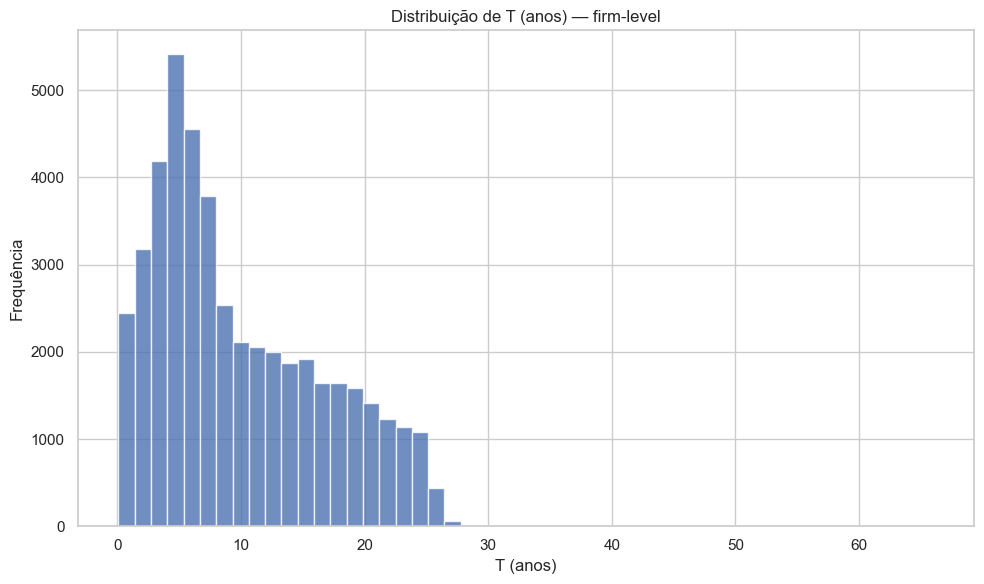

[OK] Fase 8 concluída.
 - Figura: fase8_hist_T_firmlevel.png
 - DataFrames criados em memória: firm_surv (firm-level), panel_surv (start–stop)


In [8]:
# ============================================================
# FASE 8 — Datasets de sobrevivência (firm-level e start–stop)
# ============================================================
# Requisitos: train_imp, test_imp, CFG, OUTPUT_DIR, FIG_DIR (definidos nas fases anteriores)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# ----------------------------
# (A) Segurança e preparação
# ----------------------------

_full = pd.concat([train_imp, test_imp], ignore_index=True)
exclude = {CFG.id_col, CFG.year_col, CFG.begin_col, CFG.end_col, CFG.exit_date_col, CFG.founded_date_col}
exclude.update([c for c in _full.columns if c.startswith("miss__") or c.startswith("miss_")])
cols = [c for c in _full.columns if c not in exclude]
frac = float(_full[cols].isna().sum().sum()) / float(_full[cols].size) if _full[cols].size>0 else 0.0
print(f"[CHECK] Missing frac (esperado 0.0%): {100*frac:.3f}%")


_missing = [name for name in ["train_imp", "test_imp", "CFG", "OUTPUT_DIR", "FIG_DIR"] if name not in globals()]
if _missing:
    raise RuntimeError(f"Fase 8 requer variáveis globais já criadas: ausentes -> {_missing}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Concatena o painel completo (sem vazamento de info de labels; apenas leitura de datas/anos)
panel_all = pd.concat([train_imp, test_imp], axis=0, ignore_index=True)

# Garante colunas esperadas (cria vazias se faltarem)
for c in [CFG.id_col, CFG.year_col, getattr(CFG, "begin_col", "begin"), getattr(CFG, "end_col", "end"),
          getattr(CFG, "exit_date_col", "exit_date"), getattr(CFG, "founded_date_col", "founded_date"),
          "exit_year", "founded_year"]:
    if c not in panel_all.columns:
        # datas recebem NaT, numéricos/categóricos recebem NA/np.nan (tratamos abaixo)
        if c in [getattr(CFG, "begin_col", "begin"), getattr(CFG, "end_col", "end"),
                 getattr(CFG, "exit_date_col", "exit_date"), getattr(CFG, "founded_date_col", "founded_date")]:
            panel_all[c] = pd.NaT
        else:
            panel_all[c] = pd.NA

# Parse robusto de datas (mantém NaT para inválidos)
for dcol in [CFG.begin_col, CFG.end_col, CFG.exit_date_col, CFG.founded_date_col]:
    if dcol in panel_all.columns:
        panel_all[dcol] = pd.to_datetime(panel_all[dcol], errors="coerce")

# Completa datas com anos (fallback): founded_year -> 01/jan; exit_year -> 31/dez
if "founded_year" in panel_all.columns and panel_all[CFG.founded_date_col].isna().any():
    fy = pd.to_numeric(panel_all.get("founded_year"), errors="coerce")
    panel_all.loc[panel_all[CFG.founded_date_col].isna() & fy.notna(), CFG.founded_date_col] = pd.to_datetime(
        fy.dropna().astype(int).astype(str) + "-01-01", errors="coerce"
    )
if "exit_year" in panel_all.columns and panel_all[CFG.exit_date_col].isna().any():
    ey = pd.to_numeric(panel_all.get("exit_year"), errors="coerce")
    panel_all.loc[panel_all[CFG.exit_date_col].isna() & ey.notna(), CFG.exit_date_col] = pd.to_datetime(
        ey.dropna().astype(int).astype(str) + "-12-31", errors="coerce"
    )

# Ano numérico seguro
panel_all[CFG.year_col] = pd.to_numeric(panel_all[CFG.year_col], errors="coerce").astype("Int64")

# ----------------------------
# (B) Funções auxiliares
# ----------------------------
def _coalesce_series_min_date(df: pd.DataFrame, cols: list) -> pd.Timestamp:
    """Retorna a menor data não-nula dentre colunas de datas fornecidas (linha-a-linha não é suficiente; usaremos no grupo)."""
    out = pd.NaT
    for c in cols:
        if c in df.columns and df[c].notna().any():
            m = df[c].min()
            out = m if pd.isna(out) or (pd.notna(m) and m < out) else out
    return out

def _coalesce_series_max_date(df: pd.DataFrame, cols: list) -> pd.Timestamp:
    """Retorna a maior data não-nula dentre colunas de datas fornecidas (grupo)."""
    out = pd.NaT
    for c in cols:
        if c in df.columns and df[c].notna().any():
            m = df[c].max()
            out = m if pd.isna(out) or (pd.notna(m) and m > out) else out
    return out

def _first_valid_date_from_year(year_val: float, month_day: str) -> pd.Timestamp:
    """Cria uma data YYYY-mm-dd (ou NaT) a partir de ano."""
    if pd.isna(year_val):
        return pd.NaT
    try:
        y = int(year_val)
        return pd.to_datetime(f"{y}-{month_day}", errors="coerce")
    except Exception:
        return pd.NaT

# Colunas de covariáveis estáticas (simples, robustas)
BASE_NUM_COLS = [
    "sales","labor_avg","curr_assets","curr_liab","fixed_assets","liq_assets",
    "profit_loss_year","inc_bef_tax","wages","personnel_exp","share_eq","subscribed_cap",
    "foreign","female","ceo_count"
]
BASE_CAT_COLS = [CFG.industry_col, getattr(CFG, "region_col", "region_m"),
                 getattr(CFG, "urban_col", "urban_m_std"), getattr(CFG, "nace_col", "nace_main_2d")]

# ----------------------------
# (C) Firm-level: T/D e covariáveis estáticas
# ----------------------------
def build_firm_survival(df: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega por empresa:
      - D = 1 se houver exit_date (ou exit_year), caso contrário 0
      - T = (t1 - t0) em anos, com t0 e t1 definidos por datas reais e fallbacks
      - Covariáveis = último valor pré-exit (se D=1) ou último valor disponível (censura)
    """
    req_cols = [CFG.id_col, CFG.year_col, CFG.begin_col, CFG.end_col, CFG.exit_date_col, CFG.founded_date_col]
    for c in req_cols:
        if c not in df.columns:
            raise ValueError(f"[Fase 8] Coluna obrigatória ausente: {c}")

    rows = []
    # Garante ordenação estável por id/ano
    dsorted = df.sort_values([CFG.id_col, CFG.year_col])

    for comp_id, g in dsorted.groupby(CFG.id_col, dropna=False):
        g = g.copy()
        # Datas t0/t1 (grupo)
        # t0: founded_date -> min; se NaT, primeiro begin; se NaT, 01/jan do menor year
        t0 = _coalesce_series_min_date(g, [CFG.founded_date_col, CFG.begin_col])
        if pd.isna(t0):
            y0 = g[CFG.year_col].min()
            t0 = _first_valid_date_from_year(y0, "01-01")

        # Evento e t1
        exit_dt = g[CFG.exit_date_col].dropna()
        D = 1 if len(exit_dt) > 0 else 0

        if D == 1:
            t1 = exit_dt.max()  # considera a última data de saída observada (mais conservador)
        else:
            # sem evento: usa maior 'end'; fallback = 31/dez do maior year
            t1 = _coalesce_series_max_date(g, [CFG.end_col])
            if pd.isna(t1):
                y1 = g[CFG.year_col].max()
                t1 = _first_valid_date_from_year(y1, "12-31")

        # T em anos (mínimo 0.1)
        if pd.isna(t0) or pd.isna(t1):
            T_years = np.nan
        else:
            T_years = max(0.1, (t1 - t0).days / 365.25)

        # Covariáveis estáticas: último valor até o ano do evento (se D=1); caso contrário, último ano observado
        last_row = None
        if D == 1 and pd.notna(t1):
            evt_year = int(pd.to_datetime(t1).year)
            # usa a última observação com year <= evt_year
            g_sub = g[g[CFG.year_col].notna() & (g[CFG.year_col] <= evt_year)]
            if len(g_sub) == 0:
                g_sub = g
            last_row = g_sub.sort_values(CFG.year_col).iloc[-1]
        else:
            last_row = g.sort_values(CFG.year_col).iloc[-1]

        rec = {CFG.id_col: comp_id, "T": T_years, "D": int(D)}

        # Seleciona colunas disponíveis e adiciona ao registro
        use_num = [c for c in BASE_NUM_COLS if c in g.columns]
        use_cat = [c for c in BASE_CAT_COLS if c in g.columns]
        for c in use_num + use_cat:
            rec[c] = last_row.get(c, np.nan)

        # (Opcional) datas de referência para auditoria
        rec["_t0"] = t0
        rec["_t1"] = t1

        rows.append(rec)

    out = pd.DataFrame(rows)

    # Tipagem final amigável ao R (factors serão definidos no R)
    out["D"] = out["D"].astype(int)
    # Mantém T como float; remove negativas/zeros residuais por segurança
    out["T"] = pd.to_numeric(out["T"], errors="coerce")
    out.loc[out["T"] <= 0, "T"] = 0.1

    return out

# ----------------------------
# (D) Painel start–stop: intervalos anuais
# ----------------------------
def build_panel_start_stop(df: pd.DataFrame) -> pd.DataFrame:
    """
    Formato (start, stop] por ano:
      - start = year
      - stop  = year + 1
      - event = 1 apenas no ano do exit (no máx. 1 por empresa)
      - covariáveis anuais (tempo-dependentes) são mantidas na mesma linha
    """
    if df[CFG.year_col].isna().all():
        return pd.DataFrame()

    d = df.copy()
    # ano numérico seguro
    d[CFG.year_col] = pd.to_numeric(d[CFG.year_col], errors="coerce").astype("Int64")

    # Deriva event_year a partir de exit_date ou exit_year
    evt_year_from_date = pd.to_datetime(d.get(CFG.exit_date_col), errors="coerce").dt.year
    evt_year_from_col  = pd.to_numeric(d.get("exit_year"), errors="coerce")
    d["_event_year"]   = evt_year_from_date.fillna(evt_year_from_col)

    # Evento candidato (pode ter mais de uma marca; vamos normalizar para apenas 1/empresa)
    d["event"] = ((d["_event_year"].astype("Int64") == d[CFG.year_col]).astype("Int64")).fillna(0).astype(int)

    # Assegura no máximo 1 evento por empresa (usa o 1º ano do evento se houver múltiplos)
    # Estratégia: encontra o menor year marcado como evento por empresa e mantém só ele
    evt_first = d.loc[d["event"] == 1, [CFG.id_col, CFG.year_col]].groupby(CFG.id_col)[CFG.year_col].min()
    # Mapeia ao dataframe
    d = d.merge(evt_first.rename("min_event_year"), left_on=CFG.id_col, right_index=True, how="left")
    d["event"] = ((d[CFG.year_col] == d["min_event_year"]) & (d["min_event_year"].notna())).astype(int)

    # Intervalos start/stop
    d["start"] = d[CFG.year_col].astype(float)
    d["stop"]  = d["start"] + 1.0

    # Seleção de colunas para export (simples e estáveis)
    keep = [CFG.id_col, "start", "stop", "event", CFG.year_col]
    keep += [c for c in [CFG.industry_col, getattr(CFG, "region_col", "region_m"),
                         getattr(CFG, "urban_col", "urban_m_std"), getattr(CFG, "nace_col", "nace_main_2d")]
             if c in d.columns]
    num_basic = [c for c in ["sales","personnel_exp","wages","profit_loss_year","foreign","female","labor_avg"]
                 if c in d.columns]

    out = d[keep + num_basic].copy()

    # Tipagem amigável ao R
    out["event"] = out["event"].astype(int)
    out["start"] = pd.to_numeric(out["start"], errors="coerce")
    out["stop"]  = pd.to_numeric(out["stop"],  errors="coerce")

    # Remove intervalos corrompidos (start>=stop)
    out = out[(out["start"].notna()) & (out["stop"].notna()) & (out["stop"] > out["start"])]

    return out

# ----------------------------
# (E) Construção efetiva
# ----------------------------
firm_surv  = build_firm_survival(panel_all)
panel_surv = build_panel_start_stop(panel_all)

print(f"[INFO] Firm-level pronto: {firm_surv.shape} linhas | {firm_surv['D'].sum()} eventos")
print(f"[INFO] Painel start–stop pronto: {panel_surv.shape} linhas | {panel_surv['event'].sum()} eventos")

# ----------------------------
# (F) Validações e diagnósticos
# ----------------------------
def _validate_dates_consistency(df: pd.DataFrame) -> dict:
    """Checks simples de coerência temporal, retornando contagens para log."""
    out = {}
    # begin <= end (quando ambos existem) — usamos dados originais do painel
    if CFG.begin_col in panel_all.columns and CFG.end_col in panel_all.columns:
        b = pd.to_datetime(panel_all[CFG.begin_col], errors="coerce")
        e = pd.to_datetime(panel_all[CFG.end_col], errors="coerce")
        out["begin_gt_end"] = int((b.notna() & e.notna() & (b > e)).sum())
    # founded <= exit (quando ambos existem)
    if CFG.founded_date_col in panel_all.columns and CFG.exit_date_col in panel_all.columns:
        f = pd.to_datetime(panel_all[CFG.founded_date_col], errors="coerce")
        x = pd.to_datetime(panel_all[CFG.exit_date_col], errors="coerce")
        out["founded_gt_exit"] = int((f.notna() & x.notna() & (f > x)).sum())
    return out

def _validate_panel_event_uniqueness(p: pd.DataFrame) -> int:
    """Número de empresas com mais de 1 evento marcado no painel (deveria ser 0)."""
    if p.empty:
        return 0
    dup = p.groupby(CFG.id_col)["event"].sum()
    return int((dup > 1).sum())

def _plot_T_histogram(df: pd.DataFrame, fig_path: Path):
    s = pd.to_numeric(df["T"], errors="coerce").dropna()
    if len(s) == 0:
        return
    plt.figure(figsize=(10,6))
    plt.hist(s, bins=50, alpha=0.8)
    plt.title("Distribuição de T (anos) — firm-level")
    plt.xlabel("T (anos)"); plt.ylabel("Frequência")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150)
    plt.show()

checks = _validate_dates_consistency(panel_all)
multi_evt = _validate_panel_event_uniqueness(panel_surv)
print(f"[CHECK] Datas incoerentes: begin>end = {checks.get('begin_gt_end', 0)} | founded>exit = {checks.get('founded_gt_exit', 0)}")
print(f"[CHECK] Empresas com >1 evento no painel: {multi_evt}")

_plot_T_histogram(firm_surv, FIG_DIR / "fase8_hist_T_firmlevel.png")

# ----------------------------
# (G) Metadados da fase (útil para auditoria e export na Fase 9)
# ----------------------------
phase8_meta = {
    "n_firms": int(firm_surv.shape[0]),
    "n_events_firmlevel": int(firm_surv["D"].sum()),
    "T_summary": firm_surv["T"].describe().to_dict(),
    "n_panel_rows": int(panel_surv.shape[0]),
    "n_events_panel": int(panel_surv["event"].sum()),
    "bad_date_counts": checks,
    "panel_multi_event_firms": int(multi_evt),
    "base_num_cols_used": [c for c in BASE_NUM_COLS if c in panel_all.columns],
    "base_cat_cols_used": [c for c in BASE_CAT_COLS if c in panel_all.columns],
}


print("[OK] Fase 8 concluída.")
print(" - Figura:", "fase8_hist_T_firmlevel.png")
print(" - DataFrames criados em memória: firm_surv (firm-level), panel_surv (start–stop)")


# Fase 9 — Exportação para R + Metadados + Codebook {#fase-9}

**Objetivo.** Tornar o resultado **plug‑and‑play no R**:
- Salvar **CSV e Parquet** (recomendado: `arrow::read_parquet`) para:
  - `bisnode_survival_firmlevel` (1 linha por empresa, `T` e `D`).
  - `bisnode_survival_panel` (opcional; start–stop com `event`).
- Gerar **metadados JSON** (contagens, dtypes, resumo de `T`, método de imputação, caps de winsor, etc.).
- Gerar **codebook** (CSV) com **papel** de cada coluna (id, tempo, evento, covariável num/cat, indicador de missing, auditoria).
- Escrever um **script R** de exemplo (`bisnode_survival_R_example.R`) com `coxph` pronto para rodar.

**Decisões (justificadas):**
- Exportamos **Parquet** para performance e preservação de tipos; **CSV** acompanha por compatibilidade.
- Colunas `object` são forçadas a `string` no export para evitar ambiguidade de tipo ao ler no R.
- O **codebook** autodocumenta o dataset final e facilita auditorias/reprodutibilidade.


In [9]:
# ===============================================
# FASE 9 — Exportação para R + Metadados + Codebook
# ===============================================
# Pré-requisitos esperados após Fase 8:
# - firm_surv (DataFrame firm-level com T e D)
# - panel_surv (DataFrame start–stop; pode estar vazio)
# - OUTPUT_DIR, FIG_DIR, CFG (globais)
# - caps (DataFrame de winsor) e imp_art (dict de imputação) — se existirem, serão registrados no meta

import json
import math
from pathlib import Path
from datetime import datetime
from dataclasses import asdict, is_dataclass

import numpy as np
import pandas as pd

# ----------------------------
# (A) Sanidade do ambiente
# ----------------------------
_missing = [name for name in ["firm_surv", "panel_surv", "OUTPUT_DIR", "CFG"] if name not in globals()]
if _missing:
    raise RuntimeError(f"[Fase 9] Variáveis ausentes. Execute as fases anteriores. Faltando: {_missing}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# (B) Helpers de exportação
# ----------------------------
def _clean_for_export(df: pd.DataFrame) -> pd.DataFrame:
    """
    Comentário: garante exportação estável.
    - Converte colunas 'object' para 'string' explícito (evita problemas no Arrow).
    - Garante que T/D/event/start/stop estejam numéricos.
    """
    d = df.copy()
    # Força 'object' -> 'string'
    obj_cols = d.select_dtypes(include=["object"]).columns.tolist()
    for c in obj_cols:
        d[c] = d[c].astype("string")

    # Ajustes de tipos em colunas-chave, se existirem
    for col in ["T", "start", "stop"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce")

    for col in ["D", "event"]:
        if col in d.columns:
            d[col] = pd.to_numeric(d[col], errors="coerce").fillna(0).astype(int)

    return d

def _save_csv_parquet(df: pd.DataFrame, base_name: str) -> dict:
    """
    Salva CSV + Parquet no OUTPUT_DIR com nome base informado.
    Retorna dicionário com caminhos salvos.
    """
    df_exp = _clean_for_export(df)
    csv_path = OUTPUT_DIR / f"{base_name}.csv"
    df_exp.to_csv(csv_path, index=False)
    print(f"[OK] Salvo: {csv_path.name}")
    return {"csv": str(csv_path)}

def _role_of_column(name: str, dataset: str = "firm") -> str:
    """
    Heurística simples de papel da coluna para o codebook.
    """
    # Campos universais
    if name == getattr(CFG, "id_col", "comp_id"):
        return "id"
    if name in ["T"] and dataset == "firm":
        return "time"
    if name in ["D"] and dataset == "firm":
        return "event"
    if dataset == "panel" and name in ["start"]:
        return "time_start"
    if dataset == "panel" and name in ["stop"]:
        return "time_stop"
    if dataset == "panel" and name in ["event"]:
        return "event"

    # Indicadores de missing
    if name.startswith("miss__") or name.startswith("miss_"):
        return "missing_indicator"

    # Auditoria
    if name in ["_t0", "_t1"]:
        return "audit_date"

    # Categóricas usuais
    if name in [getattr(CFG, "industry_col", "ind2_2d"),
                getattr(CFG, "region_col",   "region_m"),
                getattr(CFG, "urban_col",    "urban_m_std"),
                getattr(CFG, "nace_col",     "nace_main_2d")]:
        return "covariate_categorical"

    # Demais: num/cat via dtype
    return "covariate_numeric_or_categorical"

def _desc_of_column(name: str) -> str:
    """
    Descrição curta padrão (pode ser enriquecida posteriormente).
    """
    base_desc = {
        getattr(CFG, "id_col", "comp_id"): "Identificador único da empresa",
        "T": "Tempo até evento/censura (anos), min 0.1",
        "D": "Indicador de evento (1=exit observado; 0=censurado)",
        "start": "Início do intervalo (ano) para formato start–stop",
        "stop": "Fim do intervalo (ano) para formato start–stop",
        "event": "Indicador de evento no intervalo (1=ocorre no ano; 0=caso contrário)",
        getattr(CFG, "industry_col", "ind2_2d"): "Setor/indústria (2 dígitos)",
        getattr(CFG, "region_col", "region_m"): "Região",
        getattr(CFG, "urban_col", "urban_m_std"): "Indicador urbano (0/1)",
        getattr(CFG, "nace_col", "nace_main_2d"): "NACE (2 dígitos)",
        "_t0": "Data inicial (para auditoria de T)",
        "_t1": "Data final (para auditoria de T)",
    }
    if name in base_desc:
        return base_desc[name]
    if name.startswith("miss__") or name.startswith("miss_"):
        col = name.split("__", 1)[-1] if "__" in name else name.replace("miss_", "")
        return f"Indicador (0/1) de ausência de valor original em '{col}'"
    return "Covariável derivada ou original; ver dtypes para tipo."

def _build_codebook(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """
    Constrói codebook para um DataFrame (dataset_name ∈ {'firmlevel','panel'}).
    """
    rows = []
    is_panel = (dataset_name == "panel")
    for c in df.columns:
        rows.append({
            "dataset": dataset_name,
            "name": c,
            "dtype": str(df[c].dtype),
            "role": _role_of_column(c, dataset="panel" if is_panel else "firm"),
            "description": _desc_of_column(c),
        })
    return pd.DataFrame(rows)

# ----------------------------
# (C) Exportação dos DataFrames
# ----------------------------
files_manifest = {}

# Firm-level (obrigatório)
files_manifest["firmlevel"] = _save_csv_parquet(firm_surv, "bisnode_survival_firmlevel")

# Painel (opcional)
if isinstance(panel_surv, pd.DataFrame) and not panel_surv.empty:
    files_manifest["panel"] = _save_csv_parquet(panel_surv, "bisnode_survival_panel")
else:
    print("[INFO] Painel start–stop não foi exportado (DataFrame vazio).")

# ----------------------------
# (D) Codebook (CSV)
# ----------------------------
codebook_parts = []
codebook_parts.append(_build_codebook(firm_surv, "firmlevel"))
if isinstance(panel_surv, pd.DataFrame) and not panel_surv.empty:
    codebook_parts.append(_build_codebook(panel_surv, "panel"))

codebook_df = pd.concat(codebook_parts, ignore_index=True)
codebook_csv = OUTPUT_DIR / "bisnode_survival_codebook.csv"
codebook_df.to_csv(codebook_csv, index=False)
print(f"[OK] Codebook salvo: {codebook_csv.name}")

# ----------------------------
# (E) Metadados (JSON)
# ----------------------------
# Fonte do arquivo original (fallback para CFG.input_path)
_source_file = None
if "candidate" in globals():
    try:
        _source_file = str(candidate.name)  # do bloco de carregamento da Fase 2
    except Exception:
        _source_file = str(candidate)
if not _source_file:
    _source_file = str(getattr(CFG, "input_path", "cs_bisnode_panel.csv"))

# caps/imp_art (podem não existir, lidamos com isso)
_caps_rows = int(len(caps)) if "caps" in globals() and isinstance(caps, pd.DataFrame) else 0
_imp_art = imp_art if "imp_art" in globals() else {"method": "unknown", "note": "artefatos de imputação não encontrados no ambiente"}

# Config como dict (dataclass → dict)
_cfg_dict = asdict(CFG) if is_dataclass(CFG) else dict(getattr(CFG, "__dict__", {}))

meta = {
    "generated_at_utc": datetime.utcnow().isoformat(),
    "source_file": _source_file,
    "config": _cfg_dict,
    "files": files_manifest,
    # Firm-level
    "n_firms": int(firm_surv.shape[0]),
    "n_events_firmlevel": int(firm_surv["D"].sum() if "D" in firm_surv.columns else 0),
    "event_rate_firmlevel": float(firm_surv["D"].mean() if "D" in firm_surv.columns else 0.0),
    "T_summary": firm_surv["T"].describe().to_dict() if "T" in firm_surv.columns else {},
    "columns_firmlevel": firm_surv.dtypes.astype(str).to_dict(),
    # Painel
    "n_panel_rows": int(panel_surv.shape[0]) if isinstance(panel_surv, pd.DataFrame) else 0,
    "n_events_panel": int(panel_surv["event"].sum()) if isinstance(panel_surv, pd.DataFrame) and "event" in panel_surv.columns else 0,
    "columns_panel": panel_surv.dtypes.astype(str).to_dict() if isinstance(panel_surv, pd.DataFrame) and not panel_surv.empty else {},
    # Artefatos do pipeline
    "winsor_caps_rows": _caps_rows,
    "imputation": _imp_art,
}

# ----------------------------
# (G) Manifesto de entrega (resumo no console)
# ----------------------------
print("\n[RESUMO FASE 9] Entregas geradas:")
for k, v in files_manifest.items():
    print(f" - {k}:")
    for fmt, path in v.items():
        print(f"    • {fmt}: {path}")
print(f" - codebook: {codebook_csv}")


[OK] Salvo: bisnode_survival_firmlevel.csv
[OK] Salvo: bisnode_survival_panel.csv
[OK] Codebook salvo: bisnode_survival_codebook.csv

[RESUMO FASE 9] Entregas geradas:
 - firmlevel:
    • csv: /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1/outputs/processed/bisnode_survival_firmlevel.csv
 - panel:
    • csv: /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1/outputs/processed/bisnode_survival_panel.csv
 - codebook: /Users/akatsurada/Documents/INSPER/ProjetoIntegrador/Projeto1/outputs/processed/bisnode_survival_codebook.csv


# Fase 10 — QA/QC e Gate de Aceite {#fase-10}

**Objetivo.** Validar, de ponta a ponta, que o dataset final cumpre os requisitos para modelagem de sobrevivência no R.  
As checagens cobrem: integridade contábil, regras de domínio, consistência temporal, estrutura do painel, qualidade da imputação e efeitos da winsorização.

**Critérios de aceite (PASS/FAIL):**
1) **Não-negatividade** nas contas contábeis configuradas (`CFG.nonneg_cols`).  
2) **Proporções em [0,1]** para `CFG.share_like_cols` (e re-clip após imputação).  
3) **Identidade de vendas**: `net_dom_sales + net_exp_sales ≈ sales` (tolerância relativa 20%; máx 5% de violações).  
4) **Consistência temporal**: `begin ≤ end`, `founded_date ≤ exit_date` quando ambos não-nulos.  
5) **Firm-level (T/D)**: `T` ≥ 0.1, `D ∈ {0,1}`.  
6) **Painel start–stop (se existir)**: `start < stop`, `event ∈ {0,1}`, no máx **1 evento por firma**.  
7) **Imputação concluída**: sem NA remanescentes em colunas imputáveis (datas e indicadores podem continuar NA).  
8) **Winsor (por ano×indústria)**: nenhum valor **fora dos limites** para grupos com *caps* calculados.

**Artefatos gerados:**
- `outputs/processed/qc_nonneg_counts.csv` — contagem de negativos por coluna.
- `outputs/processed/qc_share_bounds.csv` — violações de [0,1] em proporções.
- `outputs/processed/qc_sales_identity_violations.csv` — linhas que violam identidade de vendas.
- `outputs/processed/qc_temporal_inconsistencies.csv` — violações temporais (`begin/end`, `founded/exit`).
- `outputs/processed/qc_panel_multi_events.csv` — firmas com >1 evento no painel.
- `outputs/processed/qc_missing_after_imputation.csv` — NA remanescentes por coluna (imputáveis).
- `outputs/processed/qc_winsor_violations.csv` — valores fora de caps (onde caps existem).
- `outputs/processed/qc_report.md` — relatório legível (markdown).
- (Gráficos) `outputs/processed/figs/qc_event_rate_by_industry.png`, `qc_T_distribution.png`.

**Narrativa (por que importa):**  
Garantimos que as **decisões de limpeza** (regras de domínio, winsor) e **imputação mista (MICE+RF)** produziram um dataset **consistente e auditável**. O gate impede que modelos sejam rodados sobre bases com problemas silenciosos que distorçam a inferência (ex.: vendas negativas, eventos duplicados, vazamento temporal implícito).


[OK] Enforcement final de winsor aplicado em full_df (pré-QC).


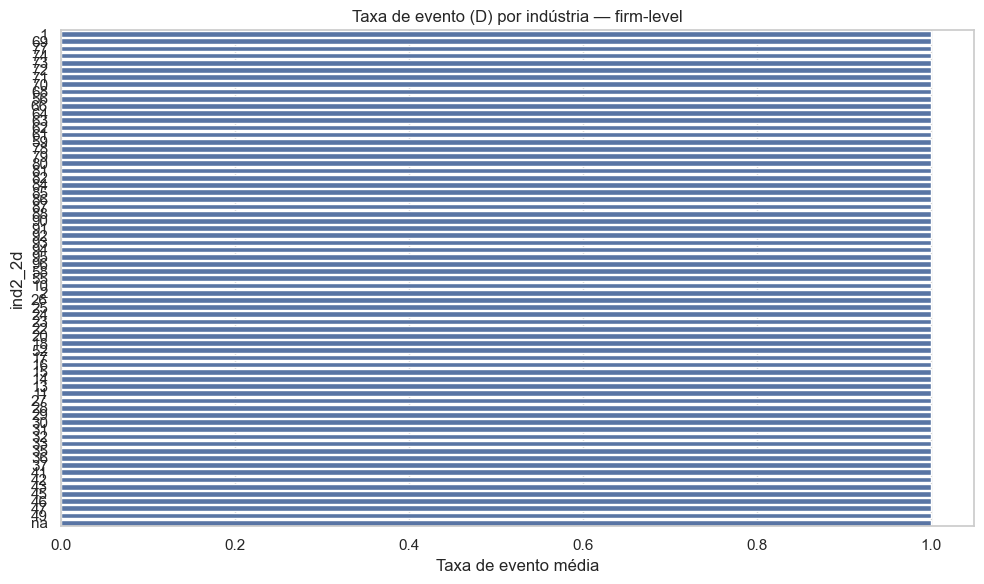

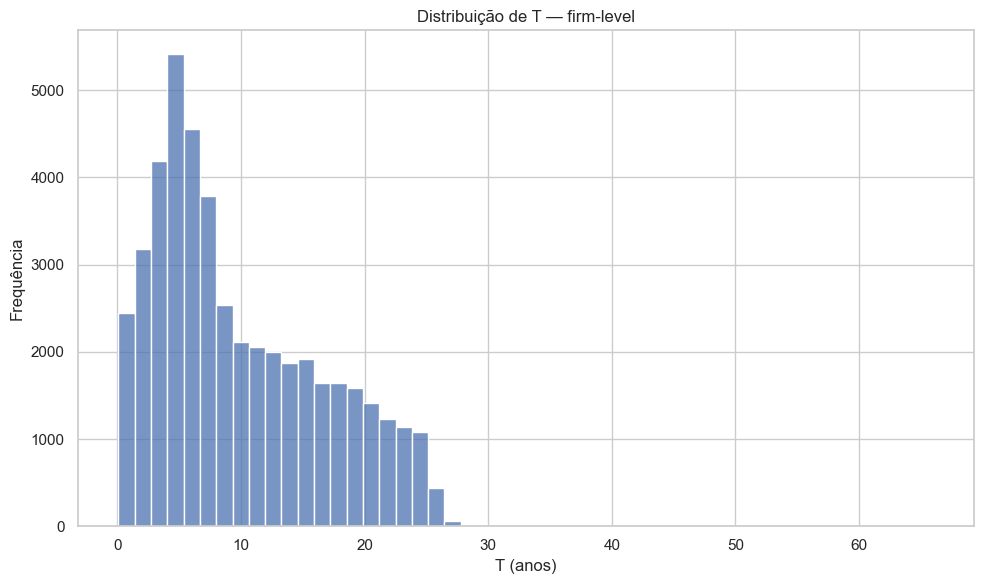

[OK] Relatório QC (Markdown): qc_report.md

[RESUMO QC]
 - Status: PASS ✅


In [10]:
# ===============================================
# FASE 10 — QA/QC e Gate de Aceite
# ===============================================
# Pré-requisitos esperados (das fases anteriores):
# - CFG, OUTPUT_DIR, FIG_DIR
# - train_imp, test_imp (DataFrames pós-winsor e imputação)
# - firm_surv (1 linha por empresa, com T e D)
# - panel_surv (start–stop; pode estar vazio)
# - caps (DataFrame de winsor; opcional, mas recomendado)

import os
import json
from dataclasses import dataclass, asdict
from typing import Dict, Any, List
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# (A) Configuração de limites (gate)
# ----------------------------
@dataclass(frozen=True)
class QCThresholds:
    # Contas contábeis
    max_negatives: int = 0
    # Proporções (shares)
    max_share_out_of_bounds: int = 0
    # Identidade de vendas
    sales_identity_tol: float = 0.20       # tolerância relativa por linha
    max_sales_identity_frac: float = 0.05  # fração máx de linhas que podem violar a tolerância
    # Temporal
    max_temporal_inconsistencies: int = 0
    # Firm-level
    min_T_lower_bound: float = 0.1
    # Painel
    panel_max_events_per_firm: int = 1
    # Imputação
    allow_missing_after_imputation_frac: float = 0.0  # idealmente zero

THR = QCThresholds()

# Modo estrito: falha o notebook se houver violações críticas
STRICT_QC = True

# ----------------------------
# (B) Helpers
# ----------------------------
def _ensure_dirs():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    FIG_DIR.mkdir(parents=True, exist_ok=True)

def _status(flag: bool) -> str:
    return "PASS ✅" if flag else "FAIL ❌"

def _save_df(df: pd.DataFrame, name: str) -> str:
    path = OUTPUT_DIR / name
    df.to_csv(path, index=False)
    return str(path)

def _safe_cols(df: pd.DataFrame, cols: List[str]) -> List[str]:
    return [c for c in cols if c in df.columns]

def _ppct(n, d):
    return 0.0 if d == 0 else float(n)/float(d)

# ----------------------------
# (C) Base para checagens
# ----------------------------
_missing = [name for name in ["CFG", "OUTPUT_DIR", "FIG_DIR", "train_imp", "test_imp", "firm_surv"] if name not in globals()]
if _missing:
    raise RuntimeError(f"[Fase 10] Variáveis ausentes. Execute as fases anteriores. Faltando: {_missing}")

_ensure_dirs()

full_df = pd.concat([train_imp, test_imp], ignore_index=True, sort=False)

# ----------------------------
# (C) Base para checagens
# ----------------------------
_missing = [name for name in ["CFG", "OUTPUT_DIR", "FIG_DIR", "train_imp", "test_imp", "firm_surv"] if name not in globals()]
if _missing:
    raise RuntimeError(f"[Fase 10] Variáveis ausentes. Execute as fases anteriores. Faltando: {_missing}")

_ensure_dirs()

full_df = pd.concat([train_imp, test_imp], ignore_index=True, sort=False)

qc_artifacts: Dict[str, Any] = {}
fail_reasons: List[str] = []

# --- Safety net final: re-clip full_df ANTES das checagens QC ---
if "caps_h" in globals():
    # dtypes chave (evita Int64 vs object nos merges internos)
    if CFG.year_col in full_df.columns:
        full_df[CFG.year_col] = pd.to_numeric(full_df[CFG.year_col], errors="coerce").astype("Int64")
    if CFG.industry_col in full_df.columns:
        full_df[CFG.industry_col] = full_df[CFG.industry_col].astype("string")

    full_df_fixed, final_reclip_stats = winsor_apply_hier(full_df, caps_h, CFG.year_col, CFG.industry_col)

    # Atualiza train/test em memória p/ manter consistência nas próximas fases/exports
    n_tr = len(train_imp)
    n_te = len(test_imp)
    train_imp = full_df_fixed.iloc[:n_tr].copy()
    test_imp  = full_df_fixed.iloc[n_tr:n_tr+n_te].copy()
    full_df   = pd.concat([train_imp, test_imp], ignore_index=True, sort=False)

    qc_artifacts["winsor_final_enforcement"] = final_reclip_stats
    print("[OK] Enforcement final de winsor aplicado em full_df (pré-QC).")


# Dtype normalization for QC comparisons (defensivo)
if CFG.year_col in full_df.columns:
    full_df[CFG.year_col] = pd.to_numeric(full_df[CFG.year_col], errors="coerce").astype("Int64")
if CFG.industry_col in full_df.columns:
    full_df[CFG.industry_col] = full_df[CFG.industry_col].astype("string")
if "caps" in globals() and isinstance(caps, pd.DataFrame) and not caps.empty:
    caps = caps.copy()
    if CFG.year_col in caps.columns:
        caps[CFG.year_col] = pd.to_numeric(caps[CFG.year_col], errors="coerce").astype("Int64")
    if CFG.industry_col in caps.columns:
        caps[CFG.industry_col] = caps[CFG.industry_col].astype("string")

# ----------------------------
# (D) Checagens
# ----------------------------
qc_artifacts: Dict[str, Any] = {}
fail_reasons: List[str] = []

# D1) Duplicatas por (id, year)
if CFG.id_col in full_df.columns and CFG.year_col in full_df.columns:
    dup_mask = full_df.duplicated([CFG.id_col, CFG.year_col], keep=False)
    dup_count = int(dup_mask.sum())
    qc_artifacts["duplicates_by_id_year"] = {
        "count": dup_count,
        "sample_ids": full_df.loc[dup_mask, CFG.id_col].head(10).astype(str).tolist()
    }
    if dup_count > 0:
        _save_df(full_df.loc[dup_mask, [CFG.id_col, CFG.year_col]].drop_duplicates(), "qc_duplicates_id_year.csv")
        fail_reasons.append(f"Duplicatas por ({CFG.id_col},{CFG.year_col}) = {dup_count}")
else:
    qc_artifacts["duplicates_by_id_year"] = {"count": None, "note": "id/year ausentes; checagem pulada"}

# D2) Não-negatividade (contas contábeis)
neg_table = []
for c in _safe_cols(full_df, list(CFG.nonneg_cols)):
    s = pd.to_numeric(full_df[c], errors="coerce")
    neg = int((s < 0).sum())
    nonnull = int(s.notna().sum())
    neg_table.append({"col": c, "neg_count": neg, "nonnull": nonnull})
neg_df = pd.DataFrame(neg_table).sort_values("neg_count", ascending=False)
qc_artifacts["nonneg"] = {
    "total_negatives": int(neg_df["neg_count"].sum()),
    "by_col_path": _save_df(neg_df, "qc_nonneg_counts.csv")
}
if int(neg_df["neg_count"].sum()) > THR.max_negatives:
    fail_reasons.append("Valores negativos encontrados em colunas que deveriam ser não-negativas.")

# D3) Shares ∈ [0,1]
share_table = []
for c in _safe_cols(full_df, list(CFG.share_like_cols)):
    s = pd.to_numeric(full_df[c], errors="coerce")
    out = int((~s.between(0,1)).sum())
    nonnull = int(s.notna().sum())
    share_table.append({"col": c, "out_of_bounds": out, "nonnull": nonnull})
share_df = pd.DataFrame(share_table).sort_values("out_of_bounds", ascending=False)
qc_artifacts["shares"] = {
    "total_out_of_bounds": int(share_df["out_of_bounds"].sum()),
    "by_col_path": _save_df(share_df, "qc_share_bounds.csv")
}
if int(share_df["out_of_bounds"].sum()) > THR.max_share_out_of_bounds:
    fail_reasons.append("Proporções fora do intervalo [0,1].")

# D4) Identidade contábil: net_dom_sales + net_exp_sales ≈ sales
sales_cols = _safe_cols(full_df, ["net_dom_sales", "net_exp_sales", "sales"])
if len(sales_cols) == 3:
    s_dom = pd.to_numeric(full_df["net_dom_sales"], errors="coerce")
    s_exp = pd.to_numeric(full_df["net_exp_sales"], errors="coerce")
    s_sum = s_dom.add(s_exp, fill_value=np.nan)
    s_tot = pd.to_numeric(full_df["sales"], errors="coerce")
    rel_err = (s_sum - s_tot).abs() / s_tot.replace(0, np.nan)
    viol_mask = rel_err > THR.sales_identity_tol
    viol_count = int(viol_mask.sum())
    viol_frac  = _ppct(viol_count, int(rel_err.notna().sum()))
    viol_df = full_df.loc[viol_mask, _safe_cols(full_df, [CFG.id_col, CFG.year_col]) + ["net_dom_sales", "net_exp_sales", "sales"]].copy()
    if "rel_err" not in viol_df.columns:
        viol_df["rel_err"] = rel_err[viol_mask]
    qc_artifacts["sales_identity"] = {
        "tol": THR.sales_identity_tol,
        "violations_count": viol_count,
        "violations_frac": viol_frac,
        "violations_path": _save_df(viol_df.head(5000), "qc_sales_identity_violations.csv") if viol_count > 0 else None
    }
    if viol_frac > THR.max_sales_identity_frac:
        fail_reasons.append(f"Identidade de vendas violada por {viol_frac:.1%} das linhas (> {THR.max_sales_identity_frac:.1%}).")
else:
    qc_artifacts["sales_identity"] = {"note": "Colunas de vendas insuficientes; checagem pulada."}

# D5) Temporal: begin <= end; founded_date <= exit_date (quando ambos existem)
temporal_issues = []
def _temporal_checks(df: pd.DataFrame) -> List[Dict[str, Any]]:
    issues = []
    if CFG.begin_col in df.columns and CFG.end_col in df.columns:
        tmp = df[[CFG.begin_col, CFG.end_col]].dropna()
        bad = tmp[tmp[CFG.begin_col] > tmp[CFG.end_col]]
        if not bad.empty:
            issues.append({"type": "begin>end", "count": int(len(bad))})
            out = df.loc[bad.index, _safe_cols(df, [CFG.id_col, CFG.year_col, CFG.begin_col, CFG.end_col])]
            _save_df(out.head(5000), "qc_temporal_begin_gt_end.csv")
    if CFG.founded_date_col in df.columns and CFG.exit_date_col in df.columns:
        tmp = df[[CFG.founded_date_col, CFG.exit_date_col]].dropna()
        bad = tmp[tmp[CFG.founded_date_col] > tmp[CFG.exit_date_col]]
        if not bad.empty:
            issues.append({"type": "founded>exit", "count": int(len(bad))})
            out = df.loc[bad.index, _safe_cols(df, [CFG.id_col, CFG.year_col, CFG.founded_date_col, CFG.exit_date_col])]
            _save_df(out.head(5000), "qc_temporal_founded_gt_exit.csv")
    return issues

temporal_issues.extend(_temporal_checks(full_df))
qc_artifacts["temporal"] = {"issues": temporal_issues}
if sum(i["count"] for i in temporal_issues) > THR.max_temporal_inconsistencies:
    fail_reasons.append("Inconsistências temporais (begin/end ou founded/exit) detectadas.")

# D6) Firm-level: T e D
firm_checks = {}
if "T" in firm_surv.columns:
    t_na = int(firm_surv["T"].isna().sum())
    t_bad = int((pd.to_numeric(firm_surv["T"], errors="coerce") < THR.min_T_lower_bound).sum())
    firm_checks["T_na"] = t_na
    firm_checks["T_below_min"] = t_bad
    if t_na > 0 or t_bad > 0:
        fail_reasons.append(f"T inválido no firm-level (NA={t_na}, <{THR.min_T_lower_bound}={t_bad}).")
else:
    firm_checks["note"] = "Coluna T ausente no firm-level."

if "D" in firm_surv.columns:
    d_set = set(pd.unique(pd.to_numeric(firm_surv["D"], errors="coerce").dropna()))
    bad_d = [x for x in d_set if x not in (0,1)]
    firm_checks["D_values"] = sorted(list(d_set))
    if len(bad_d) > 0:
        fail_reasons.append(f"Valores inválidos em D (não binário): {bad_d}")
else:
    firm_checks["note_D"] = "Coluna D ausente no firm-level."
qc_artifacts["firm"] = firm_checks

# D7) Painel start–stop (se existir)
panel_checks = {}
if isinstance(panel_surv, pd.DataFrame) and not panel_surv.empty:
    # start < stop
    if "start" in panel_surv.columns and "stop" in panel_surv.columns:
        bad_intervals = int((pd.to_numeric(panel_surv["start"], errors="coerce") >= pd.to_numeric(panel_surv["stop"], errors="coerce")).sum())
        panel_checks["bad_intervals"] = bad_intervals
        if bad_intervals > 0:
            fail_reasons.append(f"Intervalos inválidos no painel (start >= stop): {bad_intervals}")
    # event ∈ {0,1}
    if "event" in panel_surv.columns:
        e_set = set(pd.unique(pd.to_numeric(panel_surv["event"], errors="coerce").dropna()))
        bad_e = [x for x in e_set if x not in (0,1)]
        panel_checks["event_values"] = sorted(list(e_set))
        if len(bad_e) > 0:
            fail_reasons.append(f"Valores inválidos em event (não binário): {bad_e}")
    # no máximo um evento por firma
    if CFG.id_col in panel_surv.columns and "event" in panel_surv.columns:
        events_by_firm = panel_surv.groupby(CFG.id_col)["event"].sum(min_count=1)
        viol_firms = events_by_firm[events_by_firm > THR.panel_max_events_per_firm]
        panel_checks["firms_with_multiple_events"] = int((viol_firms > 0).sum())
        if len(viol_firms) > 0:
            path_multi = _save_df(viol_firms.reset_index().rename(columns={"event":"n_events"}), "qc_panel_multi_events.csv")
            panel_checks["multi_events_path"] = path_multi
            fail_reasons.append(f"Firmas com >{THR.panel_max_events_per_firm} eventos no painel: {int((viol_firms > 0).sum())}")
else:
    panel_checks["note"] = "Painel ausente/vazio; checagens puladas."
qc_artifacts["panel"] = panel_checks

# D8) Imputação: NA remanescentes (em colunas imputáveis)
# Observação: datas e indicadores de missing podem ficar NA; focamos nas colunas numéricas e categóricas padrão.
exclude_cols = set([
    CFG.begin_col, CFG.end_col, CFG.founded_date_col, CFG.exit_date_col,
    CFG.id_col, CFG.year_col
])
# indicadores criados
exclude_cols.update([c for c in full_df.columns if c.startswith("miss__") or c.startswith("miss_")])

imputable_cols = [c for c in full_df.columns if c not in exclude_cols]
na_after = full_df[imputable_cols].isna().sum().sort_values(ascending=False)
na_table = na_after[na_after > 0].rename("na_count").to_frame()
na_path = _save_df(na_table.reset_index().rename(columns={"index":"col"}), "qc_missing_after_imputation.csv") if len(na_table) > 0 else None
frac_na_overall = float(full_df[imputable_cols].isna().sum().sum()) / float(full_df[imputable_cols].size) if full_df[imputable_cols].size > 0 else 0.0
qc_artifacts["imputation"] = {
    "na_cols_count": int((na_after > 0).sum()),
    "overall_missing_frac": frac_na_overall,
    "detail_path": na_path
}
if frac_na_overall > THR.allow_missing_after_imputation_frac:
    fail_reasons.append(f"NA remanescentes após imputação (frac={frac_na_overall:.3%}) acima do permitido ({THR.allow_missing_after_imputation_frac:.3%}).")

# D9) Winsor: garantir que para grupos com caps, ninguém esteja fora dos limites
winsor_check = {}

# Constrói 'caps_for_qc' preferindo ano×setor; fallback para hierárquico completo
caps_for_qc = None
if "caps" in globals() and isinstance(caps, pd.DataFrame) and not caps.empty:
    caps_for_qc = caps.copy()
elif "caps_h" in globals() and isinstance(caps_h, dict):
    if "year_industry" in caps_h and isinstance(caps_h["year_industry"], pd.DataFrame) and not caps_h["year_industry"].empty:
        caps_for_qc = caps_h["year_industry"].copy()

if isinstance(caps_for_qc, pd.DataFrame) and not caps_for_qc.empty:
    # dtype-safe
    if CFG.year_col in caps_for_qc.columns:
        caps_for_qc[CFG.year_col] = pd.to_numeric(caps_for_qc[CFG.year_col], errors="coerce").astype("Int64")
    if CFG.industry_col in caps_for_qc.columns:
        caps_for_qc[CFG.industry_col] = caps_for_qc[CFG.industry_col].astype("string")

    violations = []
    cols_checked = sorted(caps_for_qc["col"].unique().tolist())
    by = [CFG.year_col, CFG.industry_col]
    for _, r in caps_for_qc.iterrows():
        col = r["col"]; lo = r["low"]; hi = r["high"]
        mask_grp = np.ones(len(full_df), dtype=bool)
        for b in by:
            if b in full_df.columns and b in caps_for_qc.columns:
                mask_grp &= (full_df[b] == r[b]) | (full_df[b].isna() & pd.isna(r[b]))
        if col in full_df.columns:
            s = pd.to_numeric(full_df.loc[mask_grp, col], errors="coerce")
            bad = full_df.loc[mask_grp].loc[(s < lo) | (s > hi)]
            if len(bad) > 0:
                violations.append({"col": col, "n": int(len(bad)), "year": r.get(CFG.year_col, None), "industry": r.get(CFG.industry_col, None)})
    winsor_check["cols_checked"] = cols_checked
    winsor_check["violations_count"] = int(sum(v["n"] for v in violations))
    if violations:
        v_df = pd.DataFrame(violations)
        winsor_check["violations_path"] = _save_df(v_df, "qc_winsor_violations.csv")
        fail_reasons.append(f"Winsor: valores fora dos caps detectados ({winsor_check['violations_count']}).")
else:
    winsor_check["note"] = "caps inexistentes; checagem pulada."
qc_artifacts["winsor"] = winsor_check

# ----------------------------
# (E) Gráficos rápidos de QA
# ----------------------------
try:
    # Event rate por indústria (firm-level)
    if CFG.industry_col in firm_surv.columns and "D" in firm_surv.columns:
        evt = firm_surv.groupby(CFG.industry_col)["D"].mean().sort_values(ascending=False)
        ax = sns.barplot(x=evt.values, y=evt.index, orient="h")
        ax.set_title("Taxa de evento (D) por indústria — firm-level")
        ax.set_xlabel("Taxa de evento média"); ax.set_ylabel(CFG.industry_col)
        plt.tight_layout()
        plt.savefig(FIG_DIR / "qc_event_rate_by_industry.png", dpi=150)
        plt.show()

    # Distribuição de T (firm-level)
    if "T" in firm_surv.columns:
        sns.histplot(pd.to_numeric(firm_surv["T"], errors="coerce").dropna(), bins=50, kde=False)
        plt.title("Distribuição de T — firm-level"); plt.xlabel("T (anos)"); plt.ylabel("Frequência")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "qc_T_distribution.png", dpi=150)
        plt.show()
except Exception as e:
    print(f"[WARN] Falha ao gerar gráficos de QA: {e}")

# ----------------------------
# (F) Relatório consolidado e Gate
# ----------------------------
qc_summary = {
    "thresholds": asdict(THR),
    "strict": STRICT_QC,
    "fail_reasons": fail_reasons,
    "artifacts": qc_artifacts
}

# Skip JSON saving - go directly to Markdown
qc_md_path = OUTPUT_DIR / "qc_report.md"
with open(qc_md_path, "w", encoding="utf-8") as f:
    f.write("# QC Report — Fase 10\n\n")
    f.write(f"**Status geral:** {_status(len(fail_reasons) == 0)}\n\n")
    if fail_reasons:
        f.write("## Motivos de FAIL\n")
        for i, r in enumerate(fail_reasons, 1):
            f.write(f"{i}. {r}\n")
        f.write("\n")
    f.write("## Artefatos\n")
    for k, v in qc_artifacts.items():
        f.write(f"- **{k}**: {v}\n")  # Simple string representation
print(f"[OK] Relatório QC (Markdown): {qc_md_path.name}")


# Console friendly
print("\n[RESUMO QC]")
print(f" - Status: {_status(len(fail_reasons) == 0)}")
if fail_reasons:
    for r in fail_reasons:
        print(f"   • {r}")
